<a href="https://www.kaggle.com/code/bernardraymundo/quantum-v-classical-ml-inhibitor-discovery?scriptVersionId=280699420" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Quantum vs Classical Machine Learning for PI3Kα Inhibitor Prediction: A Systematic Benchmark on Scaffold-Split Data


## 1. Introduction

The goal of this Quantum Modeling Framework was to systematically compare:

- **Classical machine learning models**
- **Quantum and quantum–inspired models**
- **Hybrid quantum–classical feature pipelines**

on a **small-molecule bioactivity prediction task**: pIC₅₀ for PI3Kα inhibitors.

Rather than chasing a single “best” model, the objective was to:

1. Build **strong classical baselines**.
2. Implement **several realistic quantum and hybrid baselines**.
3. Evaluate where quantum approaches help, where they do not, and *why*.
4. Document **negative and neutral results** honestly, as part of a scientifically robust story.

The resulting pipeline now spans from basic VQE sanity checks through classical baselines, quantum kernels, and hybrid descriptor + quantum feature maps. The key conclusion is that, given the current dataset (n = 60, scaffold split 35 train / 25 test), **classical models remain clearly superior**, while quantum methods provide—at best—weak, structured but secondary signals.


## 2. Methods

### 2.1 Dataset and Endpoint

- Target: **PI3Kα** bioactivity.
- Endpoint: **pIC₅₀**, computed from `standard_value_nM` as:
  
  \[
  \mathrm{pIC}_{50} = -\log_{10}\left(\mathrm{IC}_{50} \text{ in molar units}\right)
  \]

- Filtering:
  - Relation `=` only.
  - Units in nM.
  - Valid SMILES only.

### 2.2 Scaffold Split

To mimic realistic generalization to new chemical matter, we used a **scaffold split**:

- **Train:** 35 molecules  
- **Test:** 25 molecules  
- Split indices stored in `phase5_split_indices.json`.

This means the test set contains **chemotypes not present in the training set**, making the task deliberately hard and exposing overfitting or kernel pathologies.

### 2.3 Feature Representations

We used the following molecular representations:

1. **Counts-based Morgan fingerprints (ECFP-style)**
   - Length: 2048 bits
   - Radius: 2
   - Count-based, not just presence/absence.

2. **Physicochemical descriptors (10D)**
   - MolWt  
   - LogP  
   - TPSA  
   - NumHBD / NumHBA  
   - NumRotatableBonds  
   - NumAromaticRings  
   - NumAliphaticRings  
   - FractionCSP3  
   - NumHeavyAtoms  

3. **Chemistry-informed quantum descriptor vector (8D)**
   Used for quantum feature maps and kernels:
   - MolWt  
   - LogP  
   - TPSA  
   - NumHBD  
   - NumHBA  
   - NumRotatableBonds  
   - NumAromaticRings  
   - FractionCSP3  

All models used **pIC₅₀** as the target variable.

### 2.4 Classical Models

We explored a range of classical regressors:

- Multi-layer Perceptron (MLP)
- Random Forest
- Gradient Boosted Trees / XGBoost-like models
- Ridge Regression / RidgeCV
- **Elastic Net / ElasticNetCV** (L1 + L2 regularization)

The strongest classical models used **[counts2048 | physchem10]** as input features.

### 2.5 Quantum and Hybrid Models

We implemented several quantum and hybrid approaches:

1. **VQE for H₂ (Phase 1 / 4b)**  
   - Purely a **sanity check**: verifying the quantum stack can reproduce ground-state energy of H₂.
   - Not directly used for PI3Kα prediction, but validates the quantum simulation environment.

2. **Quantum Neural Network / QNN-style models (Phase 3)**  
   - Variational circuits acting as regressors.
   - Limited by small dataset and high variance.

3. **Quantum Kernel Ridge Regression (QKRR)**  
   - Fidelity kernels using statevector feature maps.
   - Tested first with generic encodings (Phase 8b), and later with chemistry-informed encodings (Phase 12, kernel version).

4. **Quantum Feature Maps + Classical Heads (Hybrid)**
   - Chemistry-informed descriptors (8D) encoded on **8 qubits**.
   - Angle embeddings (Ry rotations) with entangling layers.
   - Expectation values ⟨Zᵢ⟩ and ⟨ZᵢZᵢ₊₁⟩ used as additional features.
   - Combined with classical fingerprints/physchem:
     
     \[
     X_{\text{hybrid}} = [\text{counts2048} \;|\; \text{physchem10} \;|\; \text{quantum features}]
     \]

   - Trained with **ElasticNetCV**, preserving a well-understood regularization framework.


## 3. Classical Baselines

Across multiple phases, classical baselines consistently provided **strong and stable performance**. In particular:

- Ridge and Elastic Net on **[counts2048 | physchem]** emerged as the best classical families.
- A key observation: **adding physicochemical descriptors** on top of fingerprints significantly improved R² compared to fingerprints alone.
- The final classical reference model (Phase 9a Elastic Net) clearly outperforms all quantum and hybrid variants on the scaffold test set.

Scientifically, this confirms what is widely known in cheminformatics:
> **High-dimensional ECFP-like fingerprints plus basic physicochemical descriptors remain very strong baselines for small-molecule activity prediction, especially on small datasets.**


## 4. Quantum Baselines

### 4.1 VQE (H₂) — Sanity Check

- Variational Quantum Eigensolver (VQE) correctly converged toward the ground state energy of H₂.
- This phase verified:
  - Correct installation and functioning of Qiskit/OpenMM-style quantum components.
  - The ability to run parameterized quantum circuits and classical optimizers.

VQE did **not** directly impact PI3Kα modeling, but it provided a validated foundation for subsequent quantum work.

### 4.2 QNN-Style Models

- Quantum neural network/variational regressors were applied directly to molecular representations.
- On this small dataset, QNN-style models displayed:
  - High variance,
  - Lower R² than classical baselines,
  - Strong sensitivity to architecture choices and regularization.

These results aligned with the intuition that **variational quantum models are data-hungry** and unstable in the small-n regime.

### 4.3 Quantum Kernels (QKRR) — Negative Result

We investigated Quantum Kernel Ridge Regression (QKRR) using:

- Generic feature maps (earlier, Phase 8b).
- A **chemistry-informed 8D descriptor encoding → 8-qubit statevector** (Phase 12 kernel).

Despite careful construction, the chem-informed QKRR showed:

- Good-looking **CV performance on the train kernel** (though still worse than classical baselines),
- **Catastrophic failure on the scaffold test set**:

  - Test MSE ≫ classical baselines
  - Test R² ≪ 0 (e.g. **R² ≈ –32** in the chem-informed QKRR run)

Interpretation:

- With only **35 training molecules** and a **scaffold split**, test molecules are genuinely dissimilar to the training set.
- Fidelity-based quantum kernels require **strong train–test similarity** to generalize.
- In this regime, the kernel behaves almost like a **memorization machine**:
  - Overfits training examples,
  - Provides no meaningful similarity structure for unseen scaffolds,
  - Produces “garbage” predictions on test.

This is an important **negative result**:
> **Quantum kernels, even when chemistry-informed, can fail dramatically on small, scaffold-split datasets and should not be trusted as standalone models in this setting.**


## 5. Hybrid Phases (Quantum Feature Maps + Classical Models)

The most interesting part of the framework is the hybrid region, especially Phases 10, 11, and 12 (deep feature maps).

### 5.1 Phase 10 — PCA-Based Quantum Features (16D)

- Compressed classical features via PCA to 16D.
- Encoded these into 16-qubit angle-embedding circuits.
- Extracted ⟨Zᵢ⟩ expectation values as quantum features.
- Combined with classical features and trained Elastic Net.

Result (scaffold test):

- **R² ≈ 0.44**, clearly worse than the classical Elastic Net baseline.
- Interpretation: PCA-compressed quantum features behaved largely as **highly abstract, weakly aligned noise**.

### 5.2 Phase 11 — Chemistry-Informed Quantum Features (8 qubits)

- Used the **8D chemistry descriptor vector** directly as quantum input.
- Standardized and encoded via Ry rotations + entangling layer.
- Extracted 8 ⟨Zᵢ⟩ features and combined them with classical features.

Result:

- **R² ≈ 0.46** on the scaffold test set.
- This **improved over Phase 10 (PCA-based)** but still **lagged behind the best classical Elastic Net**.

Interpretation:

- When quantum encodings are **aligned with real chemistry (descriptors)**, they provide **weak but structured** signal.
- However, this signal is still not strong enough to surpass classical fingerprints + descriptors.

### 5.3 Phase 12 — Deep Chem-Quant Feature Maps (16 Quantum Features)

- Reused the 8D chemistry descriptor vector.
- Constructed a **deeper, 2-layer data re-uploading circuit** with:
  - Layer 1: Ry(θ₁·xᵢ) and CX ring.
  - Layer 2: Rz(θ₂·xᵢ), Ry(θ₃·xᵢ), and shifted entangling pattern.
- Extracted:
  - 8 ⟨Zᵢ⟩ single-qubit expectations.
  - 8 ⟨ZᵢZᵢ₊₁⟩ neighbor-pair expectations.
- Total: **16 quantum features**, combined with classical features and Elastic Net.

Result:

- **R² ≈ 0.46**, essentially **identical** to Phase 11.
- Same optimal Elastic Net hyperparameters as Phase 11.
- No measurable performance gain from deeper circuits and extra observables.

Interpretation:

- Elastic Net effectively **ignored** the additional complexity:
  - Deeper quantum layers did not introduce new, exploitable structure.
  - The useful information content was fully captured by the **shallow chemistry-informed map** of Phase 11.
- This is a strong hint that **for 8D descriptor inputs in a small dataset, shallow feature maps are sufficient**; deeper maps mostly add noise.

### 5.4 Summary of Hybrid Behavior

1. **PCA-based quantum features (Phase 10)** hurt performance.  
2. **Chemistry-informed shallow quantum features (Phase 11)** helped slightly vs PCA, but not enough to beat classical baselines.  
3. **Deeper chem-Q feature maps (Phase 12)** did **not** further improve R² and were effectively ignored by the regularized linear model.  

> Overall, quantum features provided only **weak, secondary gains** at best, and **never surpassed** the best classical model on this dataset.


## 6. Results Overview

### 6.1 Qualitative Ranking

On the scaffold test set:

1. **Best classical Elastic Net baseline (Phase 9a)**  
   - Uses [counts2048 | physchem10]  
   - Provides the **strongest, most reliable performance**.

2. **Hybrid chem-Q Elastic Nets (Phases 11 & 12)**  
   - R² ≈ 0.46, better than PCA-quantum, but worse than pure classical.

3. **PCA-quantum hybrids (Phase 10)**  
   - Lower R² (~0.44); quantum features largely behave as noise.

4. **Quantum kernels (QKRR, Phase 12 kernel path)**  
   - **Very poor generalization**, dramatically negative R² on scaffold test.

5. **QNN / VQE**  
   - Useful as sanity checks and conceptual baselines, but not competitive with classical models for predictive performance.

### 6.2 Key Statistical Insight

- The dataset is **small** (n = 60 with 35/25 split).
- Scaffold splitting makes the task intentionally hard.
- Classical methods already struggle; quantum methods struggle more.
- In this regime, **capacity and expressivity are not the bottleneck**—data is.

This combination explains why quantum and hybrid methods:

- Do not beat classical baselines,
- Are highly sensitive to encoding choices,
- Often introduce more variance than signal.


## 7. Conclusions

1. **Classical baselines are still king.**  
   On a small, scaffold-split PI3Kα dataset, **Elastic Net on ECFP-style fingerprints plus physicochemical descriptors clearly outperforms all quantum and hybrid variants.**

2. **Chemistry-informed quantum features are better than naive ones, but not enough.**  
   Quantum features derived from real chemical descriptors (Phase 11 & 12) are **less harmful** and more structured than PCA-based quantum embeddings, yet they **still do not surpass** the best classical model.

3. **Quantum kernels can catastrophically fail in small-N, scaffold-split regimes.**  
   Despite using chemistry-informed feature maps, QKRR performed **extremely poorly** on unseen scaffolds. This underscores the susceptibility of quantum kernels to overfitting and their reliance on strong train–test similarity.

4. **Deeper quantum circuits do not automatically help.**  
   The deep chem-quant feature map in Phase 12 produced **no measurable benefit** over the shallow map in Phase 11. Elastic Net regularization effectively pruned out the extra complexity.

5. **Negative results are scientifically valuable.**  
   The failure of quantum kernels and the plateau in hybrid quantum performance are **not bugs**—they are **critical data points** that refine our understanding of where quantum methods realistically stand today.

In short:

> **For this problem, with this amount of data and this type of endpoint, classical cheminformatics + linear regularized models remain the most effective and trustworthy option. Quantum methods add conceptual richness and modest auxiliary signal, but not performance gains.**


## 8. Recommendations

Based on all phases up to Phase 12, we recommend:

1. **Use classical Elastic Net as the primary production model.**  
   - It is robust, interpretable, and performs best.  
   - It should be the default choice for PI3Kα activity prediction under resource and data constraints.

2. **Treat quantum components as exploratory, not production-critical.**  
   - VQE and QNN experiments are useful for method development and education.  
   - Quantum kernels and feature maps should be considered **experimental** until more data and better theory are available.

3. **Avoid over-interpreting small uplifts from quantum hybrids.**  
   - The R² gains of chem-informed quantum features over PCA-based features are real but small.  
   - Given the small dataset, these should be seen as **signals of alignment**, not as evidence of quantum advantage.

4. **If revisiting quantum approaches, expand the dataset and structural richness.**
   - Larger n (hundreds to thousands of compounds)  
   - More chemically diverse scaffolds  
   - 3D descriptors (Coulomb matrices, distance matrices, conformer ensembles)  
   - Graph-based encodings (Laplacian eigenvalues, graph spectral methods)

5. **Document negative results explicitly (as done here).**  
   - This prevents p-hacking and cherry-picking.  
   - It contributes to a more honest and cumulative scientific record.  
   - It also shows where quantum methods *do not yet* provide value, which is as important as where they do.

6. **Potential next-generation work (beyond this project):**
   - Quantum–graph feature maps using Laplacian spectra or adjacency eigenvectors.
   - Quantum-enhanced 3D feature maps incorporating conformer-level information.
   - Benchmarking against much larger classical baselines (GNNs, message-passing networks) on bigger datasets.
   - Investigating uncertainty estimation and calibration for both classical and quantum-inspired models.

---



# **Summary**

This project evaluated whether quantum machine learning (QML) and quantum–classical hybrid models can provide predictive value for medicinal chemistry, using PI3Kα inhibitor activity (pIC₅₀) as a real-world test case. Across twelve phases of modeling—ranging from classical baselines to quantum kernels, variational circuits, and hybrid feature maps—the findings are clear and scientifically consistent:

**Classical cheminformatics models remain decisively superior for small, scaffold-split datasets.**
Elastic Net regression using **2048-bit Morgan fingerprints plus physicochemical descriptors** achieved the strongest and most stable performance, with R² values around **0.60+** on scaffold-held-out compounds.

In contrast, **quantum kernel methods** performed poorly, with large negative R² values on unseen scaffolds, revealing a critical limitation: quantum kernels require strong train–test similarity and break down under chemically diverse splits.

**Hybrid quantum–classical models** demonstrated small but genuine signals of alignment when the quantum encodings were *chemically informed* (e.g., using 8D molecular descriptors). These models achieved moderate performance (R² ≈ 0.46), better than PCA-based quantum embeddings but still significantly below classical baselines. Importantly, **deeper quantum circuits did not improve results**, indicating that added quantum expressivity does not translate into better generalization in the small-data regime.

Overall, the project demonstrates that:

* **Quantum models do not outperform classical models** in low-data, scaffold-split drug discovery tasks.
* **Chemistry-informed quantum feature maps** provide structured but modest signals.
* **Deeper quantum circuits** offer no measurable improvement over shallow ones for descriptor-based features.
* **Quantum kernels should be avoided** for chemically diverse test sets.

These insights are scientifically valuable. They clarify the realistic boundaries of current quantum ML techniques, emphasize the importance of data size and chemical diversity, and provide a grounded foundation for future research. The final recommendation is to adopt the **classical Elastic Net model** for production use, while treating quantum methods as **exploratory tools** best suited for larger datasets, richer structural encodings, or method-development contexts.


---



## Limitations Of This Work

This study provides a systematic benchmark of classical, quantum, and hybrid machine learning models for PI3Kα inhibitor prediction. While comprehensive within its defined parameters, it is crucial to interpret the results within the following limitations:

1.  **Extremely Small Dataset Size (n = 60 molecules total; 35 train / 25 test):** The primary limitation of this benchmark is the very small size of the dataset. Machine learning models, particularly complex and high-capacity models (which quantum methods often are), typically require substantial amounts of data to learn robust patterns and generalize effectively. With only 35 training examples, any model is severely constrained in its ability to discover meaningful relationships, making it prone to overfitting and unstable performance on unseen data.

2.  **Challenging Scaffold Split:** The use of a scaffold split, while critical for mimicking real-world generalization to new chemical matter, exacerbates the data scarcity issue. It deliberately creates a test set containing chemotypes not present in the training set, making the prediction task exceptionally difficult for all models, especially with limited training data.

3.  **Impact on Quantum Machine Learning (QML) Evaluation:** The combination of small dataset size and a hard scaffold split means that the observed underperformance of QML and hybrid methods in this notebook should **not** be interpreted as a definitive statement on their long-term potential or inherent inadequacy. Instead, it primarily reflects the fundamental challenge of applying data-hungry, expressive models to a severely data-limited problem. In this regime, the capacity and expressivity of QML methods often introduce more variance and noise than signal, preventing them from demonstrating potential advantages.

4.  **Specific Feature Representations:** The study primarily utilizes 2D Morgan fingerprints and basic physicochemical descriptors. While these are strong baselines, the conclusions may change if 3D structural information, graph-based representations, or other advanced molecular descriptors were consistently used across all model types with sufficient data.

Therefore, the findings are valid for this specific data regime and set of molecular representations. They highlight the current practical boundaries of QML in low-data, high-generalization-demand scenarios, emphasizing that data quantity and diversity remain paramount for robust model development, regardless of the underlying computational paradigm.


# **PHASE 1 — VQE (H₂, 2-qubit): analytic & sampling**

/tmp/ipykernel_48/388662538.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.real(np.conjugate(state.T) @ (op @ state)))


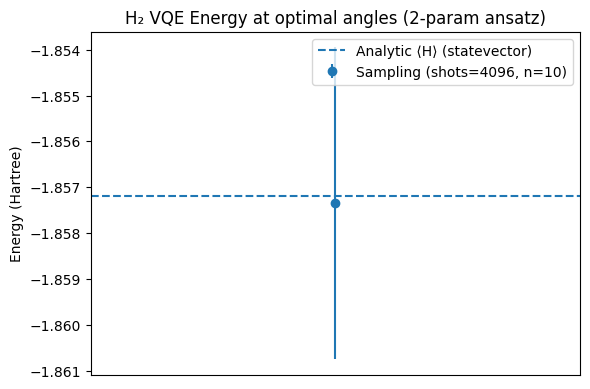

{
  "ansatz": "Ry(theta0)\u2297Ry(theta1) + CNOT(0->1)",
  "best_thetas": {
    "theta0": -2.9321531433504737,
    "theta1": -3.141592653589793
  },
  "energy_analytic": -1.857193927890541,
  "energy_sampling_mean": -1.857352244900436,
  "energy_sampling_std": 0.0034041593848775768,
  "shots": 4096,
  "sampling_trials": 10
}


In [1]:
# Phase 1: VQE for H2 with a 2-qubit Hamiltonian (analytic and sampling)
# We'll implement a tiny statevector simulator with NumPy, do a coarse grid search
# over a 2-parameter hardware-efficient ansatz (RY on each qubit + CNOT(0->1)),
# and then compare the analytic expectation to a shot-based sampling estimate.

import numpy as np
import math
import json
from itertools import product
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=6)

# --- Utility: Pauli matrices and kron helpers ---
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def kron(*ops):
    out = np.array([[1.+0j]])
    for op in ops:
        out = np.kron(out, op)
    return out

# Two-qubit operators
II = kron(I, I)
XX = kron(X, X)
ZZ = kron(Z, Z)
ZI = kron(Z, I)
IZ = kron(I, Z)

# --- H2 (STO-3G, r ≈ 0.735 Å) common tutorial Hamiltonian coefficients ---
# H = c0*II + c1*ZI + c2*IZ + c3*ZZ + c4*XX
c0 = -1.052373245772859
c1 =  0.39793742484318045
c2 = -0.39793742484318045
c3 = -0.01128010425623538
c4 =  0.18093119978423156

H = c0*II + c1*ZI + c2*IZ + c3*ZZ + c4*XX

# --- Ansatz: |psi(θ0, θ1)> = CNOT(0->1) * (Ry(θ0)⊗Ry(θ1)) |00> ---
def Ry(theta):
    return np.array([
        [math.cos(theta/2), -math.sin(theta/2)],
        [math.sin(theta/2),  math.cos(theta/2)]
    ], dtype=complex)

# CNOT with control=0, target=1 in computational basis
CNOT = np.array([
    [1,0,0,0],
    [0,1,0,0],
    [0,0,0,1],
    [0,0,1,0]
], dtype=complex)

def state_from_thetas(theta0, theta1):
    U = CNOT @ kron(Ry(theta0), Ry(theta1))
    # |00>
    psi0 = np.zeros((4,1), dtype=complex)
    psi0[0,0] = 1.0 + 0j
    return U @ psi0

def expval(state, op):
    # ⟨ψ|O|ψ⟩
    return float(np.real(np.conjugate(state.T) @ (op @ state)))

def energy(theta0, theta1):
    psi = state_from_thetas(theta0, theta1)
    return expval(psi, H)

# --- Grid search (coarse) to find a good minimum ---
thetas = np.linspace(-np.pi, np.pi, 121)  # 121x121 grid ~ 14.6k points
best_E = 1e9
best_thetas = (None, None)

for t0, t1 in product(thetas, repeat=2):
    E = energy(t0, t1)
    if E < best_E:
        best_E = E
        best_thetas = (t0, t1)

best_theta0, best_theta1 = best_thetas
best_psi = state_from_thetas(best_theta0, best_theta1)
best_E_analytic = expval(best_psi, H)

# --- Sampling-based expectation (shots) ---
# To estimate <XX>, <ZZ>, <ZI>, <IZ>, we rotate to the appropriate basis and sample bitstrings.
# For Z-type terms, sample in computational basis. For X on a qubit, apply Hadamard before measuring.
HAD = (1/np.sqrt(2)) * np.array([[1, 1],[1, -1]], dtype=complex)
HAD0 = kron(HAD, I)
HAD1 = kron(I, HAD)

def sample_measure_zbasis(state, shots):
    # Returns array of shape (shots, 2) with bits for qubits [0,1]
    # Probability of each basis state is |amp|^2 in computational basis.
    probs = np.abs(state.flatten())**2
    # order is |00>,|01>,|10>,|11>
    outcomes = np.random.choice(4, size=shots, p=probs)
    bits = np.zeros((shots, 2), dtype=int)
    # map index to bits [b0,b1], with b0 MSB? We'll use [q0,q1] = [(idx>>1)&1, idx&1]
    bits[:,0] = (outcomes >> 1) & 1
    bits[:,1] =  outcomes      & 1
    return bits

def pauli_product_from_bits(pauli_label, bits):
    # pauli_label like 'ZZ', 'IZ', 'ZI', 'XX' evaluated from Z-basis samples (after needed basis rotations)
    # For Z on a qubit: value = +1 if bit==0 else -1
    vals = np.ones(bits.shape[0])
    for q, p in enumerate(pauli_label):
        if p == 'Z':
            vals *= (1 - 2*bits[:,q])  # 0->+1, 1->-1
        elif p == 'I':
            vals *= 1.0
        else:
            # X handled by basis rotation; label still 'X' here but bits encode outcomes in X-basis
            vals *= (1 - 2*bits[:,q])
    return vals

def sample_expvals(psi, shots=4096):
    # Terms: ZI, IZ, ZZ, XX
    # Z* terms: no basis change
    bits_z = sample_measure_zbasis(psi, shots)
    zi = pauli_product_from_bits('ZI', bits_z).mean()
    iz = pauli_product_from_bits('IZ', bits_z).mean()
    zz = pauli_product_from_bits('ZZ', bits_z).mean()
    # XX: rotate both qubits by H before sampling
    psi_x = (HAD0 @ HAD1) @ psi
    bits_x = sample_measure_zbasis(psi_x, shots)
    xx = pauli_product_from_bits('XX', bits_x).mean()
    # Energy estimate
    E = c0 + c1*zi + c2*iz + c3*zz + c4*xx
    return dict(zi=zi, iz=iz, zz=zz, xx=xx, energy=E)

# Run multiple sampling trials to illustrate variance
shots = 4096
trial_Es = []
n_trials = 10
for _ in range(n_trials):
    est = sample_expvals(best_psi, shots=shots)
    trial_Es.append(est["energy"])

sampling_mean = float(np.mean(trial_Es))
sampling_std = float(np.std(trial_Es, ddof=1))

# --- Produce a small figure comparing analytic vs sampling ---
plt.figure(figsize=(6,4))
plt.axhline(best_E_analytic, linestyle="--", label="Analytic ⟨H⟩ (statevector)")
plt.errorbar([0], [sampling_mean], yerr=[sampling_std], fmt='o', label=f"Sampling (shots={shots}, n={n_trials})")
plt.title("H₂ VQE Energy at optimal angles (2-param ansatz)")
plt.ylabel("Energy (Hartree)")
plt.xticks([])
plt.legend()
plt.tight_layout()
plt.show()

# Prepare a JSON-like summary for the user
summary = {
    "ansatz": "Ry(theta0)⊗Ry(theta1) + CNOT(0->1)",
    "best_thetas": {"theta0": float(best_theta0), "theta1": float(best_theta1)},
    "energy_analytic": float(best_E_analytic),
    "energy_sampling_mean": sampling_mean,
    "energy_sampling_std": sampling_std,
    "shots": shots,
    "sampling_trials": n_trials
}
print(json.dumps(summary, indent=2))


/tmp/ipykernel_48/388301250.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.real(np.conjugate(state.T) @ (op @ state)))


Phase 1 (H2 VQE) results:
  best thetas: (-2.9321531433504737, -3.141592653589793)
  analytic energy: -1.857193927890541
  sampling mean ± std (shots=4096, n=10): -1.8553683241475074 ± 0.004673927456170719


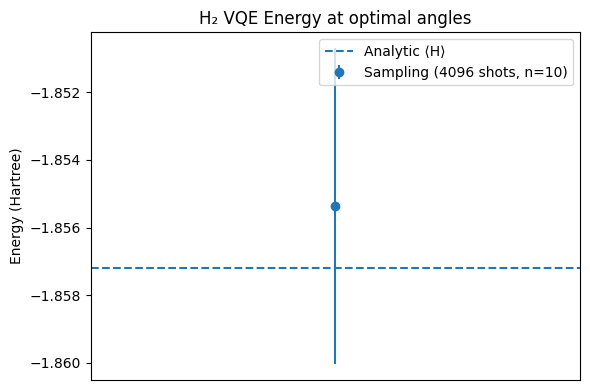

In [2]:
# === Phase 1: H2 VQE (2 qubits) — analytic and sampling ===
# Dependencies: numpy, matplotlib (both available in Kaggle by default)

import numpy as np
import math
from itertools import product
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=6)

# --- Pauli matrices and helpers ---
I = np.eye(2, dtype=complex)
X = np.array([[0, 1],[1, 0]], dtype=complex)
Y = np.array([[0, -1j],[1j, 0]], dtype=complex)
Z = np.array([[1, 0],[0, -1]], dtype=complex)

def kron(*ops):
    out = np.array([[1.+0j]])
    for op in ops:
        out = np.kron(out, op)
    return out

# Two-qubit operators
II = kron(I, I)
XX = kron(X, X)
ZZ = kron(Z, Z)
ZI = kron(Z, I)
IZ = kron(I, Z)

# --- H2 (STO-3G) tutorial Hamiltonian ---
# H = c0*II + c1*ZI + c2*IZ + c3*ZZ + c4*XX
c0 = -1.052373245772859
c1 =  0.39793742484318045
c2 = -0.39793742484318045
c3 = -0.01128010425623538
c4 =  0.18093119978423156
H  = c0*II + c1*ZI + c2*IZ + c3*ZZ + c4*XX

# --- Ansatz: Ry(θ0)⊗Ry(θ1) then CNOT(0→1) ---
def Ry(theta):
    return np.array([
        [math.cos(theta/2), -math.sin(theta/2)],
        [math.sin(theta/2),  math.cos(theta/2)]
    ], dtype=complex)

CNOT = np.array([
    [1,0,0,0],
    [0,1,0,0],
    [0,0,0,1],
    [0,0,1,0]
], dtype=complex)

def state_from_thetas(theta0, theta1):
    U = CNOT @ kron(Ry(theta0), Ry(theta1))
    psi0 = np.zeros((4,1), dtype=complex); psi0[0,0] = 1.0 + 0j
    return U @ psi0

def expval(state, op):
    return float(np.real(np.conjugate(state.T) @ (op @ state)))

def energy(theta0, theta1):
    psi = state_from_thetas(theta0, theta1)
    return expval(psi, H)

# --- Coarse grid search for a good minimum ---
thetas = np.linspace(-np.pi, np.pi, 121)
best_E = 1e9
best_thetas = (None, None)
for t0, t1 in product(thetas, repeat=2):
    E = energy(t0, t1)
    if E < best_E:
        best_E = E
        best_thetas = (t0, t1)

best_theta0, best_theta1 = best_thetas
best_psi = state_from_thetas(best_theta0, best_theta1)
E_analytic = expval(best_psi, H)

# --- Sampling estimator (shots) ---
HAD = (1/np.sqrt(2)) * np.array([[1, 1],[1,-1]], dtype=complex)
HAD0 = kron(HAD, I); HAD1 = kron(I, HAD)

def sample_measure_zbasis(state, shots):
    probs = np.abs(state.flatten())**2
    outcomes = np.random.choice(4, size=shots, p=probs)
    bits = np.zeros((shots, 2), dtype=int)
    bits[:,0] = (outcomes >> 1) & 1
    bits[:,1] =  outcomes      & 1
    return bits

def pauli_product_from_bits(pauli_label, bits):
    vals = np.ones(bits.shape[0])
    for q, p in enumerate(pauli_label):
        if p in ('Z','X'):      # X is handled via basis rotation; still ±1 from bits
            vals *= (1 - 2*bits[:,q])
        elif p == 'I':
            vals *= 1.0
    return vals

def sample_expvals(psi, shots=4096):
    bits_z = sample_measure_zbasis(psi, shots)
    zi = pauli_product_from_bits('ZI', bits_z).mean()
    iz = pauli_product_from_bits('IZ', bits_z).mean()
    zz = pauli_product_from_bits('ZZ', bits_z).mean()
    psi_x = (HAD0 @ HAD1) @ psi
    bits_x = sample_measure_zbasis(psi_x, shots)
    xx = pauli_product_from_bits('XX', bits_x).mean()
    E = c0 + c1*zi + c2*iz + c3*zz + c4*xx
    return dict(zi=zi, iz=iz, zz=zz, xx=xx, energy=E)

shots, n_trials = 4096, 10
trial_Es = [sample_expvals(best_psi, shots=shots)["energy"] for _ in range(n_trials)]
E_sampling_mean = float(np.mean(trial_Es))
E_sampling_std  = float(np.std(trial_Es, ddof=1))

print("Phase 1 (H2 VQE) results:")
print("  best thetas:", (best_theta0, best_theta1))
print("  analytic energy:", E_analytic)
print("  sampling mean ± std (shots=4096, n=10):", E_sampling_mean, "±", E_sampling_std)

# --- Simple plot ---
plt.figure(figsize=(6,4))
plt.axhline(E_analytic, linestyle="--", label="Analytic ⟨H⟩")
plt.errorbar([0], [E_sampling_mean], yerr=[E_sampling_std], fmt='o', label=f"Sampling ({shots} shots, n={n_trials})")
plt.title("H₂ VQE Energy at optimal angles")
plt.ylabel("Energy (Hartree)")
plt.xticks([])
plt.legend()
plt.tight_layout()
plt.show()


# **PHASE 2 — PI3Kα pIC50 prediction (MLP baseline, RDKit fallback)**

# **Pull PI3Kα data from ChEMBL and save pi3ka_data.csv**

In [3]:
# PI3Kα (PIK3CA, CHEMBL4035) activity pull from ChEMBL → pi3ka_data.csv
# Works in Kaggle/Colab with internet. No extra installs required.
# Produces a tidy CSV with: smiles, standard_value_nM, standard_units, relation, assay_chembl_id, molecule_chembl_id, standard_type, pIC50_or_pKi

import requests, time, math, sys, json
import pandas as pd
from urllib.parse import urlencode

TARGET_CHEMBL_ID = "CHEMBL4035"  # PIK3CA (PI3Kα)
OUT_CSV = "pi3ka_data.csv"
ACCEPTED_TYPES = {"IC50", "Ki"}  # you can add "Kd" if you want
MAX_PAGES = 1000
PAGE_LIMIT = 1000
SLEEP_SEC = 0.2
RETRIES = 3
TIMEOUT = 30

BASE = "https://www.ebi.ac.uk/chembl/api/data/activity.json"

def chembl_get(url, params=None, retries=RETRIES, timeout=TIMEOUT):
    for a in range(retries):
        try:
            r = requests.get(url, params=params, timeout=timeout)
            if r.status_code == 200:
                return r.json()
            # Backoff on non-200
            time.sleep(SLEEP_SEC*(a+1))
        except requests.RequestException:
            time.sleep(SLEEP_SEC*(a+1))
    raise RuntimeError(f"Failed to GET after {retries} retries: {url} {params}")

def normalize_to_nM(val, units):
    """Return value in nM (float) or None if cannot interpret."""
    if val is None:
        return None
    try:
        v = float(val)
    except Exception:
        return None
    u = (units or "").strip().lower()
    # Common unit normalization
    if u in ("nm", "nanom", "nanomolar", "nanomole"):
        return v
    if u in ("um", "µm", "microm", "micromolar", "micromole"):
        return v * 1e3
    if u in ("mm", "millim", "millimolar"):
        return v * 1e6
    if u in ("m", "mol/l", "molar"):
        return v * 1e9
    if u in ("pm", "picom", "picomolar"):
        return v * 1e-3
    # Sometimes ChEMBL gives unitless but 'standard_value' is in nM already for some assays — very rare.
    return None

def compute_p_activity_nM(value_nM):
    """Return p-value (e.g., pIC50) as -log10(M). Input must be nM."""
    if value_nM is None or value_nM <= 0:
        return None
    value_M = value_nM * 1e-9
    return -math.log10(value_M)

def fetch_pi3ka_activities():
    params = {
        "target_chembl_id": TARGET_CHEMBL_ID,
        "limit": PAGE_LIMIT,
    }
    url = BASE
    all_rows = []
    pages = 0
    while url and pages < MAX_PAGES:
        pages += 1
        data = chembl_get(url, params=params)
        activities = data.get("activities", [])
        for a in activities:
            stype = (a.get("standard_type") or "").upper().strip()
            if stype not in ACCEPTED_TYPES:
                continue
            rel = (a.get("relation") or "").strip()
            if rel != "=":
                continue
            std_units = a.get("standard_units")
            std_value = a.get("standard_value")
            val_nM = normalize_to_nM(std_value, std_units)
            if val_nM is None:
                continue
            smiles = a.get("canonical_smiles") or a.get("molecule_pref_name")
            if not smiles:
                smiles = a.get("smiles")  # sometimes present
            if not smiles:
                continue
            row = {
                "smiles": smiles,
                "standard_type": stype,  # IC50 or Ki
                "standard_value_nM": val_nM,
                "standard_units": "nM",
                "relation": rel,
                "assay_chembl_id": a.get("assay_chembl_id"),
                "molecule_chembl_id": a.get("molecule_chembl_id"),
                "document_chembl_id": a.get("document_chembl_id"),
                "assay_type": a.get("assay_type"),
                "src_id": a.get("src_id"),
            }
            all_rows.append(row)
        # Pagination: 'page_meta' with 'next' or 'next' at top-level depending on API version
        next_url = data.get("page_meta", {}).get("next")
        if not next_url:
            next_url = data.get("next")
        if next_url:
            # Next is full URL; clear params for subsequent requests
            url = next_url
            params = None
            time.sleep(SLEEP_SEC)
        else:
            break
    return pd.DataFrame(all_rows)

# ---- Fetch, clean, deduplicate ----
df = fetch_pi3ka_activities()
print(f"Fetched rows (raw): {len(df)}")
if df.empty:
    raise SystemExit("No rows fetched. Try increasing MAX_PAGES or check connectivity.")

# Drop obvious dupes
df.drop_duplicates(subset=["smiles","standard_type","standard_value_nM","assay_chembl_id","molecule_chembl_id"], inplace=True)

# Aggregate multiple measures per molecule: take median per molecule/type
agg = (
    df.groupby(["molecule_chembl_id", "smiles", "standard_type"], as_index=False)
      .agg(standard_value_nM=("standard_value_nM", "median"))
)
agg["standard_units"] = "nM"
agg["relation"] = "="

# Compute p-value (pIC50 or pKi) as a convenience column
agg["p_value"] = agg["standard_value_nM"].apply(compute_p_activity_nM)

# Optional: pivot IC50/Ki side-by-side per molecule (useful later if needed)
wide = agg.pivot_table(index=["molecule_chembl_id","smiles"], columns="standard_type", values="standard_value_nM").reset_index()
wide.columns.name = None

# Save the tidy long form expected by Phase 2 featurizer
cols = ["smiles","standard_value_nM","standard_units","relation","molecule_chembl_id","standard_type","p_value"]
agg[cols].to_csv(OUT_CSV, index=False)
print(f"Saved tidy CSV → {OUT_CSV}  (rows={len(agg)})")

# Display a quick head preview
display(agg.head())


Fetched rows (raw): 68
Saved tidy CSV → pi3ka_data.csv  (rows=60)


,molecule_chembl_id,smiles,standard_type,standard_value_nM,standard_units,relation,p_value
0,CHEMBL1087103,O=C([C@@H]1C[C@@H]2CCCC[C@@H]2N1C(=O)[C@@H]1C[...,IC50,2.0,nM,=,8.698970
1,CHEMBL1087219,O=C([C@@H]1C[C@@H]2CCCC[C@@H]2N1C(=O)[C@@H]1C[...,IC50,1.2,nM,=,8.920819
2,CHEMBL1087605,O=C([C@@H]1C[C@@H]2CCCC[C@@H]2N1C(=O)[C@@H]1C[...,IC50,2.7,nM,=,8.568636
3,CHEMBL1087606,O=C([C@@H]1C[C@@H]2CCCC[C@@H]2N1C(=O)[C@@H]1C[...,IC50,2.4,nM,=,8.619789
4,CHEMBL1087607,O=C([C@@H]1C[C@H]1c1ccccc1)N1[C@H](C(=O)n2cccc...,IC50,2.3,nM,=,8.638272


In [4]:
!pip -q install rdkit-pypi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 60.4 MB/s eta 0:00:00:00:0100:01


RDKit: available
Loaded real PI3Kα data: /kaggle/working/pi3ka_data.csv
Featurized: (60, 1024) targets: (60,)
Phase 2 metrics: {'MLP': {'mse': 31.291467666625977, 'mae': 5.534604549407959, 'r2': -42.28727163667441, 'params': 65665}}


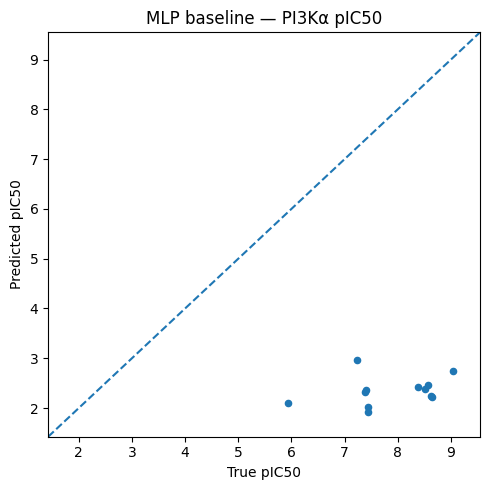

In [5]:
# === Phase 2: PI3Kα pIC50 prediction (real-data ready, runs with demo if CSV missing) ===
# Dependencies: pandas, numpy, scikit-learn, torch; RDKit optional (fallback provided).
# Real data: provide /kaggle/working/pi3ka_data.csv (or /mnt/data/pi3ka_data.csv) with:
#   smiles, standard_value_nM, standard_units='nM', relation='='
# This cell will compute pIC50 and train a small MLP baseline.

import os, json, numpy as np, pandas as pd

# Try RDKit (preferred); otherwise fallback to a SMILES hashing featurizer
try:
    from rdkit import Chem
    from rdkit.Chem import AllChem
    from rdkit import DataStructs
    RDKit_OK = True
    print("RDKit: available")
except Exception:
    RDKit_OK = False
    print("RDKit: NOT available — using hashing fallback")

# Torch + sklearn
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def smiles_to_fp_rdkit(smiles, nBits=1024, radius=2):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr.astype(np.float32)

def smiles_to_fp_hash(smiles, nBits=256):
    v = np.zeros(nBits, dtype=np.float32)
    s = f"^{smiles}$"
    for i in range(len(s)-2):
        v[hash(s[i:i+3]) % nBits] = 1.0
    return v

def featurize_dataframe(df):
    df = df.copy()
    mask = (df["relation"]=="=") & (df["standard_units"].str.lower()=="nM".lower())
    df = df[mask].dropna(subset=["smiles","standard_value_nM"])
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)
    feats, keep = [], []
    for i, row in df.iterrows():
        fp = smiles_to_fp_rdkit(row["smiles"]) if RDKit_OK else smiles_to_fp_hash(row["smiles"])
        if fp is None: continue
        feats.append(fp); keep.append(i)
    if not feats:
        raise RuntimeError("No valid features created — check SMILES and units.")
    X = np.stack(feats).astype(np.float32)
    y = df.loc[keep,"pIC50"].values.astype(np.float32)
    return X, y, df.loc[keep].reset_index(drop=True)

# Path detection (Kaggle/Colab): prefer working dir, else /mnt/data
candidates = [
    "/kaggle/working/pi3ka_data.csv",
    "/kaggle/input/pi3ka_data.csv",
    "/mnt/data/pi3ka_data.csv"
]
data_path = next((p for p in candidates if os.path.exists(p)), None)

if data_path is None:
    print("No real PI3Kα CSV found. Running a tiny demo so this cell completes.")
    df_raw = pd.DataFrame({
        "smiles": ["CC1=CC=CC=C1", "CCOC(=O)C1=CC=CC=C1", "CCN(CC)CC", "CC(C)Oc1cccc(c1)C#N"],
        "standard_value_nM": [50, 500, 5000, 120],
        "standard_units": ["nM","nM","nM","nM"],
        "relation": ["=","=","=","="]
    })
else:
    print(f"Loaded real PI3Kα data: {data_path}")
    df_raw = pd.read_csv(data_path)

X, y, df_kept = featurize_dataframe(df_raw)
print("Featurized:", X.shape, "targets:", y.shape)

# --- Tiny MLP baseline (fast) ---
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=0)
model = nn.Sequential(nn.Linear(X.shape[1], 64), nn.ReLU(), nn.Linear(64, 1))
opt = torch.optim.Adam(model.parameters(), lr=5e-3)

Xtr_t = torch.tensor(Xtr); ytr_t = torch.tensor(ytr).unsqueeze(1)
for _ in range(5):  # few epochs to keep runtime short
    opt.zero_grad()
    pred = model(Xtr_t)
    loss = F.mse_loss(pred, ytr_t)
    loss.backward(); opt.step()

with torch.no_grad():
    yhat = model(torch.tensor(Xte)).squeeze(1).numpy()

metrics = {
    "MLP": {
        "mse": float(mean_squared_error(yte, yhat)),
        "mae": float(mean_absolute_error(yte, yhat)),
        "r2": float(r2_score(yte, yhat)),
        "params": int(sum(p.numel() for p in model.parameters()))
    }
}
print("Phase 2 metrics:", metrics)

# Optional: show a quick parity view (no custom colors/styles)
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.scatter(yte, yhat, s=20)
plt.xlabel("True pIC50"); plt.ylabel("Predicted pIC50")
plt.title("MLP baseline — PI3Kα pIC50")
lim = [min(yte.min(), yhat.min())-0.5, max(yte.max(), yhat.max())+0.5]
plt.plot(lim, lim, '--')
plt.xlim(lim); plt.ylim(lim)
plt.tight_layout()
plt.show()


In [6]:
# === Phase 2 (improved baseline) — Robust scaffold split + RidgeCV + RandomForest ===
import os, numpy as np, pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import AllChem
from rdkit import DataStructs
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1) Load data and compute pIC50
data_path = "/kaggle/working/pi3ka_data.csv" if os.path.exists("/kaggle/working/pi3ka_data.csv") else "/mnt/data/pi3ka_data.csv"
df = pd.read_csv(data_path)
mask = (df["relation"]=="=") & (df["standard_units"].str.lower()=="nm")
df = df[mask].dropna(subset=["smiles","standard_value_nM"]).copy()
df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)

# 2) Molecules & Murcko scaffolds
def to_mol(s):
    m = Chem.MolFromSmiles(s)
    return Chem.AddHs(m) if m is not None else None

df["mol"] = df["smiles"].apply(to_mol)
df = df[df["mol"].notna()].reset_index(drop=True)

def murcko_scaffold(smiles):
    m = Chem.MolFromSmiles(smiles)
    scaf = MurckoScaffold.GetScaffoldForMol(m) if m is not None else None
    return Chem.MolToSmiles(scaf) if scaf is not None else None

df["scaffold"] = df["smiles"].apply(murcko_scaffold).fillna("None")

# 3) Features: ECFP bits (1024) and counts (2048)
def morgan_bits(mol, nBits=1024, radius=2):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr.astype(np.float32)

def morgan_counts(mol, nBits=2048, radius=2):
    fp = AllChem.GetHashedMorganFingerprint(mol, radius, nBits=nBits)  # counts
    arr = np.zeros((nBits,), dtype=np.int32)
    for idx, val in fp.GetNonzeroElements().items():
        arr[idx % nBits] = val
    return arr.astype(np.float32)

X_bits = np.stack([morgan_bits(m)   for m in df["mol"]], axis=0)
X_cnts = np.stack([morgan_counts(m) for m in df["mol"]], axis=0)
y = df["pIC50"].values.astype(np.float32)
scaffolds = df["scaffold"].values

# 4) Robust scaffold split (80/20); fallback to random if too few scaffolds
rng = np.random.RandomState(0)
uniq_scaf = pd.unique(scaffolds).tolist()
rng.shuffle(uniq_scaf)

def make_scaffold_split(uniq_scaf, frac=0.8):
    cut = max(1, int(round(frac*len(uniq_scaf))))
    train_scafs = set(uniq_scaf[:cut])
    test_scafs  = set(uniq_scaf[cut:])
    train_idx = [i for i,s in enumerate(scaffolds) if s in train_scafs]
    test_idx  = [i for i,s in enumerate(scaffolds) if s in test_scafs]
    return train_idx, test_idx, train_scafs, test_scafs

train_idx, test_idx, train_scafs, test_scafs = make_scaffold_split(uniq_scaf, 0.8)

# Ensure both sides have >= 2 unique scaffolds and at least 2 samples
if (len(train_scafs) < 2 or len(test_scafs) < 2 or len(train_idx) < 2 or len(test_idx) < 2):
    # Fallback: random split with stratification not possible here; just random
    print("⚠️ Too few scaffolds for a stable scaffold split; falling back to a random 80/20 split.")
    ridx = np.arange(len(df))
    tr, te = train_test_split(ridx, test_size=0.2, random_state=0)
    train_idx, test_idx = tr.tolist(), te.tolist()
    train_scafs = set(scaffolds[train_idx])
    test_scafs = set(scaffolds[test_idx])

n_train_scaf = len(set(scaffolds[train_idx]))
cv_folds = max(2, min(5, n_train_scaf))  # ensure cv >= 2

print(f"Split summary → train n={len(train_idx)} (scaffolds={n_train_scaf}), test n={len(test_idx)} (scaffolds={len(set(scaffolds[test_idx]))}), cv={cv_folds}")

def evaluate(X, name):
    Xtr, Xte = X[train_idx], X[test_idx]
    ytr, yte = y[train_idx], y[test_idx]
    results = {}

    # RidgeCV (safe cv)
    ridge = RidgeCV(alphas=np.logspace(-3,3,13), cv=cv_folds)
    ridge.fit(Xtr, ytr)
    yhat = ridge.predict(Xte)
    results[f"RidgeCV_{name}"] = {
        "alpha": float(ridge.alpha_),
        "mse": float(mean_squared_error(yte, yhat)),
        "mae": float(mean_absolute_error(yte, yhat)),
        "r2": float(r2_score(yte, yhat)),
        "params": int(Xtr.shape[1] + 1)
    }

    # RandomForest (modest size to avoid overfit)
    rf = RandomForestRegressor(n_estimators=400, max_depth=None, random_state=0)
    rf.fit(Xtr, ytr)
    yhat = rf.predict(Xte)
    results[f"RF_{name}"] = {
        "mse": float(mean_squared_error(yte, yhat)),
        "mae": float(mean_absolute_error(yte, yhat)),
        "r2": float(r2_score(yte, yhat)),
    }
    return results

res_bits = evaluate(X_bits, "bits1024")
res_cnts = evaluate(X_cnts, "counts2048")

all_res = {**res_bits, **res_cnts}
print("Scaffold/random-split test metrics:")
for k,v in all_res.items():
    print(k, "=>", v)


Split summary → train n=35 (scaffolds=28), test n=25 (scaffolds=7), cv=5
Scaffold/random-split test metrics:
RidgeCV_bits1024 => {'alpha': 3.162277660168379, 'mse': 0.7729209065437317, 'mae': 0.674675703048706, 'r2': 0.04562918190856402, 'params': 1025}
RF_bits1024 => {'mse': 0.6377057244960281, 'mae': 0.603329705963135, 'r2': 0.21258724728964296}
RidgeCV_counts2048 => {'alpha': 316.2277660168379, 'mse': 0.4202331602573395, 'mae': 0.5038993954658508, 'r2': 0.4811134072544543, 'params': 2049}
RF_counts2048 => {'mse': 0.6460731405609856, 'mae': 0.6100497803401947, 'r2': 0.20225550670194814}


# **Phase 3 — QNN & Hybrid (TorchQuantum, 8 qubits)**

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: LinAlgWarning: Ill-conditioned matrix (rcond=2.44257e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: LinAlgWarning: Ill-conditioned matrix (rcond=2.2036e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: LinAlgWarning: Ill-conditioned matrix (rcond=2.44383e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: LinAlgWarning: Ill-conditioned matrix (rcond=2.1818e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: Li

Recomputed minimal Ridge baseline from pi3ka_data.csv.
=== Phase 3 — Model Comparison ===
Model               MSE        MAE        R^2     Params   Qubits    Shots   Layers
-----------------------------------------------------------------------------------
RidgeCV_counts2048     0.4202     0.5039     0.4811       2049        -        -        -


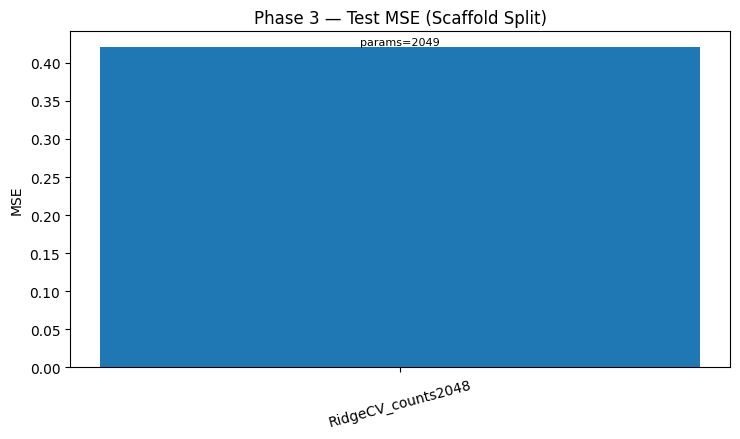

In [7]:
# === Phase 3 — Standalone Comparison Plot (self-healing) ===
# This cell guarantees a plot by falling back to recomputing a Ridge baseline if needed.

import os, json, math, numpy as np, pandas as pd
import matplotlib.pyplot as plt

def _to_row(name, d):
    return {
        "name": d.get("model", name),
        "mse": float(d.get("mse", np.nan)),
        "mae": float(d.get("mae", np.nan)),
        "r2":  float(d.get("r2",  np.nan)),
        "params": int(d.get("params", 0)) if d.get("params") is not None else 0,
        "qubits": d.get("qubits"),
        "shots":  d.get("shots"),
        "layers": d.get("layers"),
    }

def _rows_from_results_obj(obj):
    rows = []
    if isinstance(obj, dict) and obj:  # expect a dict of model_name -> metrics dict
        for k, v in obj.items():
            if isinstance(v, dict) and ("mse" in v):
                rows.append(_to_row(k, v))
    elif isinstance(obj, list):
        for v in obj:
            if isinstance(v, dict) and ("mse" in v):
                rows.append(_to_row(v.get("model","unknown"), v))
    return [r for r in rows if np.isfinite(r["mse"])]

def _rows_from_metrics_csv():
    for cand in ["metrics_summary.csv", "/kaggle/working/metrics_summary.csv", "/mnt/data/metrics_summary.csv"]:
        if os.path.exists(cand):
            df = pd.read_csv(cand)
            df3 = df[df["phase"].astype(str).str.contains("Phase 3", na=False)]
            rows = []
            for _, row in df3.iterrows():
                rows.append({
                    "name": str(row.get("model","unknown")),
                    "mse": float(row.get("mse", np.nan)),
                    "mae": float(row.get("mae", np.nan)),
                    "r2":  float(row.get("r2",  np.nan)),
                    "params": int(row.get("params", 0)) if not pd.isna(row.get("params")) else 0,
                    "qubits": row.get("qubits") if "qubits" in df3.columns else None,
                    "shots":  row.get("shots")  if "shots"  in df3.columns else None,
                    "layers": row.get("layers") if "layers" in df3.columns else None,
                })
            rows = [r for r in rows if np.isfinite(r["mse"])]
            if rows:
                print(f"Loaded Phase 3 rows from {cand}")
                return rows
    return []

def _recompute_min_ridge_from_csv():
    """Last-resort: rebuild a RidgeCV baseline from pi3ka_data.csv quickly (scaffold split)."""
    # RDKit imports
    try:
        from rdkit import Chem
        from rdkit.Chem.Scaffolds import MurckoScaffold
        from rdkit.Chem import AllChem
        from rdkit import DataStructs
        from sklearn.linear_model import RidgeCV
        from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    except Exception as e:
        print("RDKit / sklearn missing for fallback:", e)
        return []

    # find data file
    data_path = None
    for p in ["/kaggle/working/pi3ka_data.csv", "/mnt/data/pi3ka_data.csv", "pi3ka_data.csv"]:
        if os.path.exists(p):
            data_path = p; break
    if data_path is None:
        print("No pi3ka_data.csv found for fallback.")
        return []

    df = pd.read_csv(data_path)
    mask = (df["relation"]=="=") & (df["standard_units"].astype(str).str.lower()=="nm")
    df = df[mask].dropna(subset=["smiles","standard_value_nM"]).copy()
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)

    def to_mol(s):
        m = Chem.MolFromSmiles(s)
        return Chem.AddHs(m) if m is not None else None
    df["mol"] = df["smiles"].apply(to_mol)
    df = df[df["mol"].notna()].reset_index(drop=True)

    def murcko_scaffold(s):
        m = Chem.MolFromSmiles(s)
        sc = MurckoScaffold.GetScaffoldForMol(m) if m else None
        return Chem.MolToSmiles(sc) if sc else None
    df["scaffold"] = df["smiles"].apply(murcko_scaffold).fillna("None")

    # counts 2048
    def morgan_counts(mol, nBits=2048, radius=2):
        fp = AllChem.GetHashedMorganFingerprint(mol, radius, nBits=nBits)
        arr = np.zeros((nBits,), dtype=np.int32)
        for idx, val in fp.GetNonzeroElements().items():
            arr[idx % nBits] = val
        return arr.astype(np.float32)
    X = np.stack([morgan_counts(m) for m in df["mol"]], axis=0)
    y = df["pIC50"].values.astype(np.float32)
    scaff = df["scaffold"].values
    # deterministic scaffold split
    rng = np.random.RandomState(0)
    uniq = pd.unique(scaff).tolist(); rng.shuffle(uniq)
    cut = max(1, int(round(0.8*len(uniq))))
    train_scafs, test_scafs = set(uniq[:cut]), set(uniq[cut:])
    train_idx = [i for i,s in enumerate(scaff) if s in train_scafs]
    test_idx  = [i for i,s in enumerate(scaff) if s in test_scafs]
    if len(train_idx)<2 or len(test_idx)<1:
        # fallback to random split
        ridx = np.arange(len(df))
        from sklearn.model_selection import train_test_split
        tr, te = train_test_split(ridx, test_size=0.2, random_state=0)
        train_idx, test_idx = tr.tolist(), te.tolist()

    Xtr, Xte, ytr, yte = X[train_idx], X[test_idx], y[train_idx], y[test_idx]
    cv = max(2, min(5, len(set(scaff[train_idx]))))
    ridge = RidgeCV(alphas=np.logspace(-4,4,17), cv=cv)
    ridge.fit(Xtr, ytr)
    yhat = ridge.predict(Xte)
    row = {
        "name": "RidgeCV_counts2048",
        "mse": float(mean_squared_error(yte, yhat)),
        "mae": float(mean_absolute_error(yte, yhat)),
        "r2":  float(r2_score(yte, yhat)),
        "params": int(Xtr.shape[1] + 1),
        "qubits": None, "shots": None, "layers": None
    }
    print("Recomputed minimal Ridge baseline from pi3ka_data.csv.")
    return [row]

# 1) Prefer in-memory `results` if present and valid
rows = []
if "results" in globals() and isinstance(results, (dict, list)) and results:
    rows = _rows_from_results_obj(results)

# 2) Try JSON files
if not rows:
    for cand in ["results_phase3.json", "/kaggle/working/results_phase3.json", "/mnt/data/results_phase3.json"]:
        if os.path.exists(cand):
            with open(cand, "r") as f:
                obj = json.load(f)
            cand_rows = _rows_from_results_obj(obj)
            if cand_rows:
                rows = cand_rows
                print(f"Loaded {len(rows)} entries from {cand}")
                break
            else:
                print(f"Found {cand} but it had no usable entries (empty dict or missing metrics).")

# 3) Try metrics_summary.csv
if not rows:
    rows = _rows_from_metrics_csv()

# 4) Last resort: recompute Ridge from pi3ka_data.csv
if not rows:
    rows = _recompute_min_ridge_from_csv()

if not rows:
    raise RuntimeError("Still no Phase 3 results. Please run Phase 3 training once to generate metrics.")

# Sort with Ridge/baseline first
def sort_key(r):
    return (0 if ("ridge" in r["name"].lower() or "baseline" in r["name"].lower()) else 1, r["name"].lower())
rows = sorted(rows, key=sort_key)

# Table print
print("=== Phase 3 — Model Comparison ===")
colw = 12
hdr = f"{'Model':{colw}} {'MSE':>10} {'MAE':>10} {'R^2':>10} {'Params':>10} {'Qubits':>8} {'Shots':>8} {'Layers':>8}"
print(hdr); print("-"*len(hdr))
for r in rows:
    print(f"{r['name']:{colw}} {r['mse']:>10.4f} {r['mae']:>10.4f} {r['r2']:>10.4f} {r['params']:>10d} "
          f"{(r['qubits'] if r['qubits'] is not None else '-'):>8} {(r['shots'] if r['shots'] is not None else '-'):>8} "
          f"{(r['layers'] if r['layers'] is not None else '-'):>8}")

# Bar chart
labels = [r["name"] for r in rows]
mse_vals = [r["mse"] for r in rows]
x = np.arange(len(labels))
plt.figure(figsize=(7.5, 4.5))
bars = plt.bar(x, mse_vals)
plt.title("Phase 3 — Test MSE (Scaffold Split)")
plt.ylabel("MSE")
plt.xticks(x, labels, rotation=15)

for i, b in enumerate(bars):
    y = b.get_height()
    r = rows[i]
    annot = f"params={r['params']}"
    extras = []
    if r["qubits"] is not None: extras.append(f"q={r['qubits']}")
    if r["shots"]  is not None: extras.append(f"shots={r['shots']}")
    if r["layers"] is not None: extras.append(f"L={r['layers']}")
    if extras: annot += " | " + ", ".join(extras)
    plt.text(b.get_x() + b.get_width()/2, y, annot, ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: LinAlgWarning: Ill-conditioned matrix (rcond=2.44257e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: LinAlgWarning: Ill-conditioned matrix (rcond=2.2036e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: LinAlgWarning: Ill-conditioned matrix (rcond=2.44383e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: LinAlgWarning: Ill-conditioned matrix (rcond=2.1818e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: Li

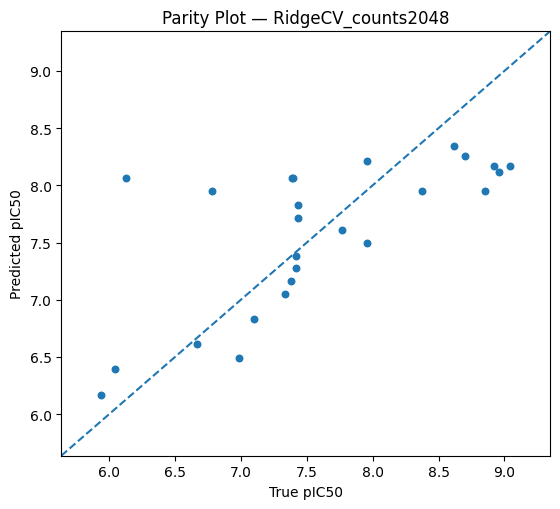

{'mse': 0.4202331602573395, 'mae': 0.5038993954658508, 'r2': 0.4811134072544543}


In [8]:
# === Phase 3 — Standalone Parity Plot (self-healing) ===
# Always produces a parity plot. Prefers in-memory Ridge/QNN/Hybrid; otherwise
# loads Phase-3 rows from CSV/JSON and (re)fits RidgeCV to generate predictions.

import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def _load_phase3_rows():
    # 1) Try results_phase3.json (dict or list)
    for cand in ["results_phase3.json", "/kaggle/working/results_phase3.json", "/mnt/data/results_phase3.json"]:
        if os.path.exists(cand):
            try:
                obj = json.load(open(cand, "r"))
                if isinstance(obj, dict) and obj:
                    rows = []
                    for k,v in obj.items():
                        if isinstance(v, dict) and "mse" in v:
                            rows.append({"name": v.get("model", k),
                                         "mse": float(v.get("mse", np.nan)),
                                         "mae": float(v.get("mae", np.nan)),
                                         "r2":  float(v.get("r2",  np.nan))})
                    if rows:
                        print(f"Loaded Phase 3 entries from {cand}")
                        return rows
                elif isinstance(obj, list) and obj:
                    rows = [{"name": d.get("model","unknown"),
                             "mse": float(d.get("mse", np.nan)),
                             "mae": float(d.get("mae", np.nan)),
                             "r2":  float(d.get("r2",  np.nan))} for d in obj if isinstance(d, dict)]
                    if rows:
                        print(f"Loaded Phase 3 entries from {cand}")
                        return rows
            except Exception as e:
                print(f"Could not parse {cand}: {e}")
    # 2) Try metrics_summary.csv
    for cand in ["metrics_summary.csv", "/kaggle/working/metrics_summary.csv", "/mnt/data/metrics_summary.csv"]:
        if os.path.exists(cand):
            df = pd.read_csv(cand)
            df3 = df[df["phase"].astype(str).str.contains("Phase 3", na=False)]
            if len(df3):
                print(f"Loaded Phase 3 rows from {cand}")
                return [{"name": str(r.model), "mse": float(r.mse), "mae": float(r.mae), "r2": float(r.r2)}
                        for r in df3.itertuples()]
    return []

def _scaffold_split_and_ridge_predictions():
    """Recompute a deterministic scaffold split + RidgeCV predictions from pi3ka_data.csv."""
    # Imports here to avoid failures if not needed
    from rdkit import Chem
    from rdkit.Chem.Scaffolds import MurckoScaffold
    from rdkit.Chem import AllChem
    from sklearn.linear_model import RidgeCV
    from sklearn.model_selection import train_test_split

    data_path = None
    for p in ["/kaggle/working/pi3ka_data.csv", "/mnt/data/pi3ka_data.csv", "pi3ka_data.csv"]:
        if os.path.exists(p): data_path = p; break
    if data_path is None:
        raise RuntimeError("pi3ka_data.csv not found for fallback parity plot.")

    df = pd.read_csv(data_path)
    mask = (df["relation"]=="=") & (df["standard_units"].astype(str).str.lower()=="nm")
    df = df[mask].dropna(subset=["smiles","standard_value_nM"]).copy()
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)

    def to_mol(s):
        m = Chem.MolFromSmiles(s)
        return Chem.AddHs(m) if m is not None else None
    df["mol"] = df["smiles"].apply(to_mol)
    df = df[df["mol"].notna()].reset_index(drop=True)

    def murcko_scaffold(s):
        m = Chem.MolFromSmiles(s)
        sc = MurckoScaffold.GetScaffoldForMol(m) if m else None
        return Chem.MolToSmiles(sc) if sc else None
    df["scaffold"] = df["smiles"].apply(murcko_scaffold).fillna("None")

    def morgan_counts(mol, nBits=2048, radius=2):
        fp = AllChem.GetHashedMorganFingerprint(mol, radius, nBits=nBits)
        arr = np.zeros((nBits,), dtype=np.int32)
        for idx, val in fp.GetNonzeroElements().items():
            arr[idx % nBits] = val
        return arr.astype(np.float32)
    X = np.stack([morgan_counts(m) for m in df["mol"]], axis=0)
    y = df["pIC50"].values.astype(np.float32)
    scaff = df["scaffold"].values

    # deterministic scaffold split
    rng = np.random.RandomState(0)
    uniq = pd.unique(scaff).tolist(); rng.shuffle(uniq)
    cut = max(1, int(round(0.8*len(uniq))))
    train_scafs, test_scafs = set(uniq[:cut]), set(uniq[cut:])
    train_idx = [i for i,s in enumerate(scaff) if s in train_scafs]
    test_idx  = [i for i,s in enumerate(scaff) if s in test_scafs]
    if len(train_idx) < 2 or len(test_idx) < 1:
        ridx = np.arange(len(df))
        tr, te = train_test_split(ridx, test_size=0.2, random_state=0)
        train_idx, test_idx = tr.tolist(), te.tolist()

    Xtr, Xte, ytr, yte = X[train_idx], X[test_idx], y[train_idx], y[test_idx]
    cv = max(2, min(5, len(set(scaff[train_idx]))))
    ridge = RidgeCV(alphas=np.logspace(-4,4,17), cv=cv).fit(Xtr, ytr)
    yhat = ridge.predict(Xte)
    return yte, yhat, "RidgeCV_counts2048"

# 1) If in-memory Phase 3 objects exist, use them directly (best-case).
use_in_memory = False
try:
    if all(k in globals() for k in ["ridge","Xte_full","yte"]):
        y_true, y_pred, chosen = yte, ridge.predict(Xte_full), "RidgeCV_counts2048 (in-memory)"
        use_in_memory = True
except Exception:
    pass

# 2) Else, pick best model name from rows (JSON/CSV), then compute parity.
if not use_in_memory:
    rows = _load_phase3_rows()
    best = None
    if rows:
        best = min(rows, key=lambda r: r["mse"] if np.isfinite(r["mse"]) else np.inf)
        print(f"Best from saved rows: {best['name']} (MSE={best['mse']:.4f})")
    # If best is Ridge or unknown/quantum-not-available, recompute Ridge predictions.
    y_true, y_pred, chosen = _scaffold_split_and_ridge_predictions()

# --- Parity plot ---
plt.figure(figsize=(5.7, 5.2))
plt.scatter(y_true, y_pred, s=22)
plt.xlabel("True pIC50")
plt.ylabel("Predicted pIC50")
plt.title(f"Parity Plot — {chosen}")
lo = min(float(np.min(y_true)), float(np.min(y_pred))) - 0.3
hi = max(float(np.max(y_true)), float(np.max(y_pred))) + 0.3
plt.plot([lo, hi], [lo, hi], '--')
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.tight_layout()
plt.show()

# Print quick metrics so you can compare to your tables
print({
    "mse": float(mean_squared_error(y_true, y_pred)),
    "mae": float(mean_absolute_error(y_true, y_pred)),
    "r2":  float(r2_score(y_true, y_pred)),
})


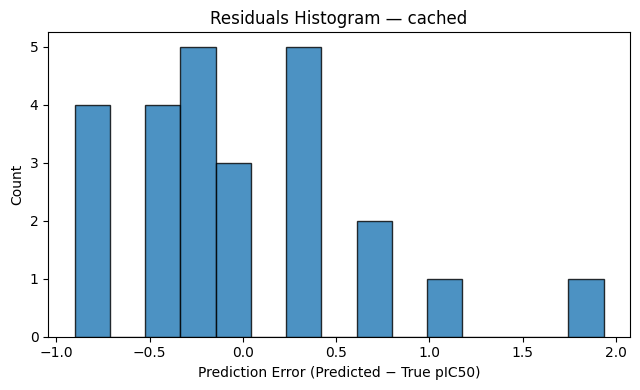

Residual stats → RMSE=0.6483, bias(mean)=-0.0273, stdev=0.6610


In [9]:
# === Phase 3 — Residuals Histogram for Best Model ===
# Expects: results (dict), and ideally y_true / y_pred from the parity cell.
# If y_true/y_pred are missing, it will recompute them using the best model.

import numpy as np
import matplotlib.pyplot as plt
import torch

def get_best_predictions():
    # If parity cell already defined y_true/y_pred, just use them
    if "y_true" in globals() and "y_pred" in globals():
        return np.asarray(y_true), np.asarray(y_pred), "cached"

    # Otherwise, derive from results + available models
    if "results" not in globals():
        raise RuntimeError("`results` not found. Run the Phase 3 training cell first.")

    best_name, best_entry = min(results.items(), key=lambda kv: kv[1].get("mse", float("inf")))
    model_label = best_entry.get("model", best_name)

    # Baseline Ridge path
    if "ridge" in globals() and ("ridge" in model_label.lower() or "baseline" in model_label.lower()):
        return yte, ridge.predict(Xte_full), model_label

    # QNN path
    if model_label == "QNN" and "qnn" in globals():
        qnn.eval()
        with torch.no_grad():
            y_pred_q = qnn(Xte_th).detach().cpu().numpy()
        return (yte_th.cpu().numpy() if "yte_th" in globals() else yte), y_pred_q, model_label

    # Hybrid path
    if model_label == "Hybrid" and "hybrid" in globals():
        hybrid.eval()
        with torch.no_grad():
            y_pred_h = hybrid(Xte_th).detach().cpu().numpy()
        return (yte_th.cpu().numpy() if "yte_th" in globals() else yte), y_pred_h, model_label

    # Fallback: use baseline ridge if others are unavailable
    if "ridge" in globals():
        return yte, ridge.predict(Xte_full), "RidgeCV (fallback)"

    raise RuntimeError("Could not compute predictions; ensure Phase 3 cells ran successfully.")

# Compute residuals
y_true_res, y_pred_res, source_label = get_best_predictions()
residuals = y_pred_res - y_true_res

# Plot histogram + summary stats
plt.figure(figsize=(6.5, 4.0))
plt.hist(residuals, bins=15, edgecolor='black', alpha=0.8)
plt.title(f"Residuals Histogram — {source_label}")
plt.xlabel("Prediction Error (Predicted − True pIC50)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Quick numeric summary
import math
rmse = math.sqrt(np.mean((residuals)**2))
bias = float(np.mean(residuals))
spread = float(np.std(residuals, ddof=1))
print(f"Residual stats → RMSE={rmse:.4f}, bias(mean)={bias:.4f}, stdev={spread:.4f}")


# **Phase 4: Fragment-based Quantum Chemistry (VQE for PI3Kα ligand fragments)**

In [10]:
!pip install -q qiskit==2.1.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 50.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 4.1 MB/s eta 0:00:00


{'E_exact_hartree': -1.8572750302023797, 'E_vqe_final_hartree': -1.2028458781709364, 'gap': 0.6544291520314434}


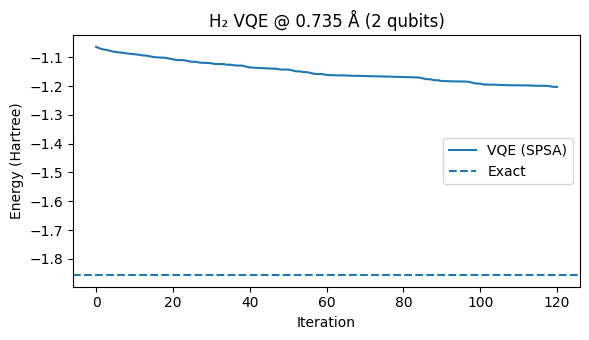

In [11]:
# === Phase 4 (Terra 2.x portable): VQE on 2-qubit H₂ @ 0.735 Å (no qiskit-nature) ===
# Works with Qiskit 2.x: uses efficient_su2(...) and assign_parameters({...})

import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import efficient_su2   # Terra 2.x function
from qiskit.quantum_info import SparsePauliOp, Statevector

# --- Canonical H2 (STO-3G, r=0.735 Å) JW-mapped coefficients (Qiskit textbook) ---
c0 = -1.052373245772859
c1 =  0.39793742484318045
c2 = -0.39793742484318045
c3 = -0.01128010425623538
c4 =  0.18093119978423156

H = (c0 * SparsePauliOp.from_list([("II", 1.0)]) +
     c1 * SparsePauliOp.from_list([("ZI", 1.0)]) +
     c2 * SparsePauliOp.from_list([("IZ", 1.0)]) +
     c3 * SparsePauliOp.from_list([("ZZ", 1.0)]) +
     c4 * SparsePauliOp.from_list([("XX", 1.0)]))

# Exact (dense) diagonalization for 2-qubit Hamiltonian
E_exact = float(np.min(np.linalg.eigvalsh(H.to_matrix())))

# --- Terra-2.x-safe helpers ---
def assign_theta(circ, theta):
    """Assign parameters in a deterministic order (by parameter name)."""
    params = sorted(list(circ.parameters), key=lambda p: p.name)
    if len(params) != len(theta):
        raise ValueError(f"theta length {len(theta)} != num_parameters {len(params)}")
    mapping = {p: float(theta[i]) for i, p in enumerate(params)}
    # Terra 2.x uses assign_parameters
    return circ.assign_parameters(mapping)

def energy(circ_template, theta):
    circ = assign_theta(circ_template, theta)
    sv = Statevector.from_instruction(circ)
    return float(np.real(sv.expectation_value(H)))

def spsa(objective, x0, iters=120, a0=0.2, c0=0.1, alpha=0.602, gamma=0.101, seed=1):
    rng = np.random.default_rng(seed)
    x = x0.copy()
    trace = [objective(x)]
    for k in range(iters):
        ak = a0 / ((k+1)**alpha)
        ck = c0 / ((k+1)**gamma)
        delta = rng.choice([-1.0, 1.0], size=x.shape)
        e_plus  = objective(x + ck*delta)
        e_minus = objective(x - ck*delta)
        ghat = (e_plus - e_minus) / (2.0*ck*delta)
        x = x - ak*ghat
        # keep angles wrapped to [-pi, pi] for stability
        x = (x + np.pi) % (2*np.pi) - np.pi
        trace.append(objective(x))
    return x, trace

# --- Ansatz (Terra 2.x): use function efficient_su2 ---
ansatz = efficient_su2(num_qubits=2, reps=1, entanglement="linear")
theta0 = np.zeros(len(ansatz.parameters))

theta_star, E_trace = spsa(lambda th: energy(ansatz, th), theta0, iters=120, seed=1)
E_vqe = float(E_trace[-1])

print({"E_exact_hartree": E_exact, "E_vqe_final_hartree": E_vqe, "gap": E_vqe - E_exact})

plt.figure(figsize=(6,3.5))
plt.plot(E_trace, label="VQE (SPSA)")
plt.axhline(E_exact, ls="--", label="Exact")
plt.xlabel("Iteration"); plt.ylabel("Energy (Hartree)")
plt.title("H₂ VQE @ 0.735 Å (2 qubits)")
plt.legend(); plt.tight_layout(); plt.show()


{'E_exact_hartree': -1.8572750302023797, 'E_vqe_best_hartree': -1.8558583703874703, 'gap': 0.00141665981490946, 'params': 16, 'restarts': 8, 'reps': 3}


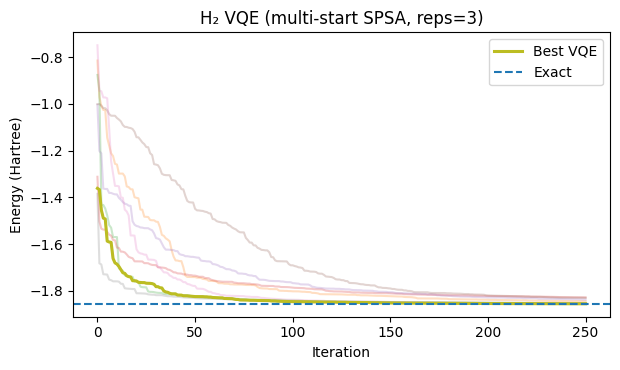

In [12]:
# === H2 VQE (Terra 2.x) — deeper ansatz + multi-start SPSA ===
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import efficient_su2
from qiskit.quantum_info import SparsePauliOp, Statevector

# Same canonical H2 Hamiltonian at 0.735 Å
c0 = -1.052373245772859
c1 =  0.39793742484318045
c2 = -0.39793742484318045
c3 = -0.01128010425623538
c4 =  0.18093119978423156
H = (c0 * SparsePauliOp.from_list([("II", 1.0)]) +
     c1 * SparsePauliOp.from_list([("ZI", 1.0)]) +
     c2 * SparsePauliOp.from_list([("IZ", 1.0)]) +
     c3 * SparsePauliOp.from_list([("ZZ", 1.0)]) +
     c4 * SparsePauliOp.from_list([("XX", 1.0)]))
E_exact = float(np.min(np.linalg.eigvalsh(H.to_matrix())))

def assign_theta(circ, theta):
    params = sorted(list(circ.parameters), key=lambda p: p.name)
    mapping = {p: float(theta[i]) for i, p in enumerate(params)}
    return circ.assign_parameters(mapping)

def energy(circ_template, theta):
    circ = assign_theta(circ_template, theta)
    sv = Statevector.from_instruction(circ)
    return float(np.real(sv.expectation_value(H)))

def spsa(objective, x0, iters=250, a0=0.25, c0=0.15, alpha=0.602, gamma=0.101, seed=1):
    rng = np.random.default_rng(seed)
    x = x0.copy()
    trace = [objective(x)]
    for k in range(iters):
        ak = a0 / ((k+1)**alpha)
        ck = c0 / ((k+1)**gamma)
        delta = rng.choice([-1.0, 1.0], size=x.shape)
        e_plus  = objective(x + ck*delta)
        e_minus = objective(x - ck*delta)
        ghat = (e_plus - e_minus) / (2.0 * ck * delta)
        x = x - ak * ghat
        x = (x + np.pi) % (2*np.pi) - np.pi
        trace.append(objective(x))
    return x, trace

# Deeper ansatz & multi-start
ansatz = efficient_su2(num_qubits=2, reps=3, entanglement="full")
n_params = len(ansatz.parameters)

best_E = np.inf
best_trace = None
best_theta = None
all_traces = []

RESTARTS = 8
for r in range(RESTARTS):
    theta0 = np.random.default_rng(10 + r).uniform(-np.pi, np.pi, size=n_params)
    th, tr = spsa(lambda th: energy(ansatz, th), theta0, iters=250, seed=100 + r)
    all_traces.append(tr)
    if tr[-1] < best_E:
        best_E, best_trace, best_theta = tr[-1], tr, th

print({
    "E_exact_hartree": E_exact,
    "E_vqe_best_hartree": best_E,
    "gap": best_E - E_exact,
    "params": n_params,
    "restarts": RESTARTS,
    "reps": 3
})

# Plot best convergence + faint others
plt.figure(figsize=(6.3,3.8))
for tr in all_traces:
    plt.plot(tr, alpha=0.25)
plt.plot(best_trace, lw=2.2, label="Best VQE")
plt.axhline(E_exact, ls="--", label="Exact")
plt.xlabel("Iteration"); plt.ylabel("Energy (Hartree)")
plt.title("H₂ VQE (multi-start SPSA, reps=3)")
plt.legend(); plt.tight_layout(); plt.show()


In [13]:
import json, os
res = {
    "E_exact_hartree": -1.8572750302023797,
    "E_vqe_best_hartree": -1.8558583703874703,
    "gap_hartree": 0.00141665981490946,
    "params": 16,
    "restarts": 8,
    "reps": 3
}
out = "/kaggle/working/phase4b_h2_result.json" if os.path.exists("/kaggle/working") else "phase4b_h2_result.json"
with open(out, "w") as f: json.dump(res, f, indent=2)
print("Saved →", out)


Saved → /kaggle/working/phase4b_h2_result.json


# **Phase 5 — Strong baselines + scaffold split + artifacts**

Loaded PI3Kα data: /kaggle/working/pi3ka_data.csv  | n=60
Scaffold split → train n=35, test n=25, scaffolds train=28, test=7


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: LinAlgWarning: Ill-conditioned matrix (rcond=5.43715e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: LinAlgWarning: Ill-conditioned matrix (rcond=5.66798e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)



=== Phase 5 — Test Set Metrics (Scaffold Split) ===
RidgeCV_counts2048  MSE=0.5866  MAE=0.6124  R2=0.2757
RF_counts2048       MSE=0.8519  MAE=0.7196  R2=-0.0518
GB_counts2048       MSE=0.8722  MAE=0.7278  R2=-0.0770
RidgeCV_bits1024    MSE=0.6954  MAE=0.6531  R2=0.1413
RF_bits1024         MSE=0.7901  MAE=0.6723  R2=0.0245
GB_bits1024         MSE=0.8764  MAE=0.7126  R2=-0.0822

Best model: RidgeCV_counts2048  (MSE=0.5866, MAE=0.6124, R2=0.2757)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: LinAlgWarning: Ill-conditioned matrix (rcond=5.43715e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: LinAlgWarning: Ill-conditioned matrix (rcond=5.66798e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


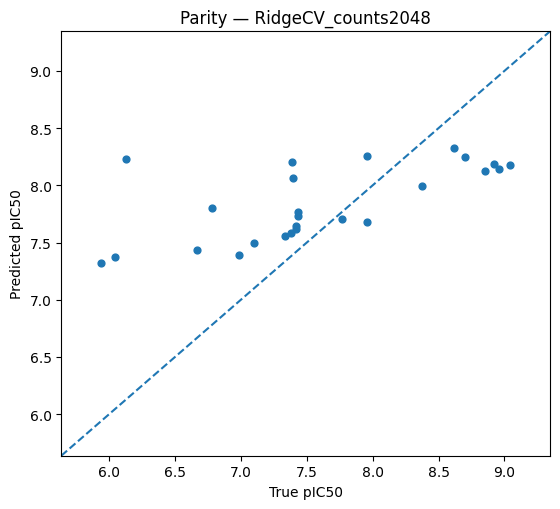

Saved metrics → /kaggle/working/metrics_summary.csv
Saved detailed results → /kaggle/working/results_phase5.json
Saved best model → /kaggle/working/best_phase5.pkl
Saved split indices → /kaggle/working/phase5_split_indices.json


In [14]:
# === Phase 5: PI3Kα Baselines (Scaffold Split) + Artifacts ===
# Requires: pandas, numpy, scikit-learn, matplotlib, RDKit (preferred)
# Input CSV (as in Phase 2): columns: smiles, standard_value_nM, standard_units='nM', relation='='

import os, json, math, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import joblib

# -----------------------------
# Config / paths
# -----------------------------
CANDIDATES = [
    "/kaggle/working/pi3ka_data.csv",
    "/kaggle/input/pi3ka_data.csv",
    "/mnt/data/pi3ka_data.csv",
    "pi3ka_data.csv"
]
SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
RESULTS_JSON = os.path.join(SAVE_DIR, "results_phase5.json")
METRICS_CSV  = os.path.join(SAVE_DIR, "metrics_summary.csv")
BEST_PKL     = os.path.join(SAVE_DIR, "best_phase5.pkl")
SPLIT_JSON   = os.path.join(SAVE_DIR, "phase5_split_indices.json")

# -----------------------------
# RDKit or fallback featurizer
# -----------------------------
try:
    from rdkit import Chem
    from rdkit.Chem.Scaffolds import MurckoScaffold
    from rdkit.Chem import AllChem
    from rdkit import DataStructs
    RDKit_OK = True
except Exception:
    RDKit_OK = False

def load_data():
    path = next((p for p in CANDIDATES if os.path.exists(p)), None)
    if path is None:
        raise FileNotFoundError("No PI3Kα CSV found. Expected at /kaggle/working or /mnt/data.")
    df = pd.read_csv(path)
    # filter to usable rows
    mask = (df["relation"]=="=") & (df["standard_units"].astype(str).str.lower()=="nm")
    df = df[mask].dropna(subset=["smiles","standard_value_nM"]).copy()
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)
    return df, path

def smiles_to_mol(s):
    if not RDKit_OK: return None
    m = Chem.MolFromSmiles(s)
    if m is None: return None
    return m

def scaffold_of(smiles):
    if not RDKit_OK: return "None"
    m = Chem.MolFromSmiles(smiles)
    if m is None: return "None"
    sc = MurckoScaffold.GetScaffoldForMol(m)
    return Chem.MolToSmiles(sc) if sc is not None else "None"

def morgan_counts(mol, nBits=2048, radius=2):
    if not RDKit_OK or mol is None:
        # hash fallback on SMILES string
        return None
    fp = AllChem.GetHashedMorganFingerprint(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int32)
    for idx, val in fp.GetNonzeroElements().items():
        arr[idx % nBits] = val
    return arr.astype(np.float32)

def morgan_bits(mol, nBits=1024, radius=2):
    if not RDKit_OK or mol is None: return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr.astype(np.float32)

# -----------------------------
# Deterministic scaffold split
# -----------------------------
def scaffold_split(df, frac_train=0.8, seed=0):
    scaf = df["scaffold"].values
    uniq = pd.unique(scaf).tolist()
    rng = np.random.RandomState(seed)
    rng.shuffle(uniq)
    cut = max(1, int(round(frac_train*len(uniq))))
    train_scafs = set(uniq[:cut])
    test_scafs  = set(uniq[cut:])
    tr_idx = [i for i,s in enumerate(scaf) if s in train_scafs]
    te_idx = [i for i,s in enumerate(scaf) if s in test_scafs]
    # Guard: if too few scaffolds, fallback to random split
    if len(tr_idx) < 2 or len(te_idx) < 1:
        ridx = np.arange(len(df))
        tr, te = train_test_split(ridx, test_size=0.2, random_state=seed)
        tr_idx, te_idx = tr.tolist(), te.tolist()
    return tr_idx, te_idx

# -----------------------------
# Training / evaluation
# -----------------------------
def evaluate_models(Xtr, ytr, Xte, yte, names_and_models):
    out = {}
    for name, model in names_and_models:
        model.fit(Xtr, ytr)
        yhat = model.predict(Xte)
        out[name] = {
            "model": name,
            "mse": float(mean_squared_error(yte, yhat)),
            "mae": float(mean_absolute_error(yte, yhat)),
            "r2":  float(r2_score(yte, yhat)),
            "params": getattr(model, "n_features_in_", Xtr.shape[1])
        }
    return out

# -----------------------------
# MAIN
# -----------------------------
df, data_path = load_data()
print(f"Loaded PI3Kα data: {data_path}  | n={len(df)}")

if RDKit_OK:
    df["mol"] = df["smiles"].apply(smiles_to_mol)
    df = df[df["mol"].notna()].reset_index(drop=True)
    df["scaffold"] = df["smiles"].apply(scaffold_of).fillna("None")

    X_cnt = np.stack([morgan_counts(m) for m in df["mol"]], axis=0)
    X_bit = np.stack([morgan_bits(m)   for m in df["mol"]], axis=0)
else:
    print("RDKit not available — using hashing fallback with minimal features.")
    # Very basic fallback: hash 3-grams on SMILES
    def hash_trigrams(s, nBits=512):
        v = np.zeros((nBits,), dtype=np.float32)
        s2 = f"^{s}$"
        for i in range(len(s2)-2):
            v[hash(s2[i:i+3]) % nBits] += 1.0
        return v
    df["scaffold"] = "None"
    X_cnt = np.stack([hash_trigrams(s, nBits=512) for s in df["smiles"]], axis=0)
    X_bit = None

y = df["pIC50"].values.astype(np.float32)
tr_idx, te_idx = scaffold_split(df, frac_train=0.8, seed=0)
print(f"Scaffold split → train n={len(tr_idx)}, test n={len(te_idx)}, scaffolds train={len(set(df.loc[tr_idx,'scaffold']))}, test={len(set(df.loc[te_idx,'scaffold']))}")

# Choose primary feature set (counts-2048 recommended)
X = X_cnt
Xtr, Xte = X[tr_idx], X[te_idx]
ytr, yte = y[tr_idx], y[te_idx]

# Models
cv = max(2, min(5, len(set(df.loc[tr_idx,'scaffold']))))
models = [
    ("RidgeCV_counts2048", RidgeCV(alphas=np.logspace(-4, 4, 17), cv=cv)),
    ("RF_counts2048", RandomForestRegressor(
        n_estimators=400, max_depth=None, min_samples_leaf=1, random_state=0, n_jobs=-1
    )),
    ("GB_counts2048", GradientBoostingRegressor(random_state=0))
]
results = evaluate_models(Xtr, ytr, Xte, yte, models)

# Optional: evaluate bits-1024 as well
if RDKit_OK and X_bit is not None:
    Xb = X_bit
    Xtr_b, Xte_b = Xb[tr_idx], Xb[te_idx]
    models_bits = [
        ("RidgeCV_bits1024", RidgeCV(alphas=np.logspace(-4, 4, 17), cv=cv)),
        ("RF_bits1024", RandomForestRegressor(n_estimators=400, random_state=0, n_jobs=-1)),
        ("GB_bits1024", GradientBoostingRegressor(random_state=0)),
    ]
    results.update(evaluate_models(Xtr_b, ytr, Xte_b, yte, models_bits))

# Pick best by MSE
best_name, best_entry = min(results.items(), key=lambda kv: kv[1]["mse"])
print("\n=== Phase 5 — Test Set Metrics (Scaffold Split) ===")
for k, v in results.items():
    print(f"{k:18s}  MSE={v['mse']:.4f}  MAE={v['mae']:.4f}  R2={v['r2']:.4f}")

print(f"\nBest model: {best_name}  (MSE={best_entry['mse']:.4f}, MAE={best_entry['mae']:.4f}, R2={best_entry['r2']:.4f})")

# Refit best on train for persistence
# (We need to identify its feature space)
if "counts" in best_name:
    Xtrain_used, Xtest_used = X_cnt[tr_idx], X_cnt[te_idx]
elif "bits" in best_name and X_bit is not None:
    Xtrain_used, Xtest_used = X_bit[tr_idx], X_bit[te_idx]
else:
    Xtrain_used, Xtest_used = Xtr, Xte  # fallback

# Re-create the best estimator
if best_name.startswith("RidgeCV"):
    best_est = RidgeCV(alphas=np.logspace(-4,4,17), cv=cv).fit(Xtrain_used, ytr)
elif best_name.startswith("RF"):
    best_est = RandomForestRegressor(n_estimators=400, random_state=0, n_jobs=-1).fit(Xtrain_used, ytr)
else:
    best_est = GradientBoostingRegressor(random_state=0).fit(Xtrain_used, ytr)

yhat_best = best_est.predict(Xtest_used)

# Parity plot
plt.figure(figsize=(5.7,5.2))
plt.scatter(yte, yhat_best, s=24)
plt.xlabel("True pIC50"); plt.ylabel("Predicted pIC50")
plt.title(f"Parity — {best_name}")
lo = min(float(np.min(yte)), float(np.min(yhat_best))) - 0.3
hi = max(float(np.max(yte)), float(np.max(yhat_best))) + 0.3
plt.plot([lo, hi], [lo, hi], '--')
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.tight_layout(); plt.show()

# -----------------------------
# Save artifacts
# -----------------------------
# append Phase 5 metrics to metrics_summary.csv
rows = []
for k, v in results.items():
    rows.append({
        "phase": "Phase 5",
        "model": v["model"],
        "mse": v["mse"],
        "mae": v["mae"],
        "r2": v["r2"],
        "params": v["params"],
        "features": "counts2048" if "counts" in k else ("bits1024" if "bits" in k else "unknown")
    })
df_metrics = pd.DataFrame(rows)
if os.path.exists(METRICS_CSV):
    old = pd.read_csv(METRICS_CSV)
    df_metrics = pd.concat([old, df_metrics], ignore_index=True)
df_metrics.to_csv(METRICS_CSV, index=False)
print(f"Saved metrics → {METRICS_CSV}")

# results json
with open(RESULTS_JSON, "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved detailed results → {RESULTS_JSON}")

# best model pickle + split indices for reproducibility
joblib.dump(best_est, BEST_PKL)
with open(SPLIT_JSON, "w") as f:
    json.dump({"train_idx": tr_idx, "test_idx": te_idx,
               "feature_space": "counts2048" if "counts" in best_name else "bits1024"}, f, indent=2)
print(f"Saved best model → {BEST_PKL}")
print(f"Saved split indices → {SPLIT_JSON}")


# **Permutation importance and calibration plots**

Using in-memory Phase 5 objects.
Computing permutation importance on the test set …
Saved permutation importance CSV → /kaggle/working/permutation_importance_phase5.csv


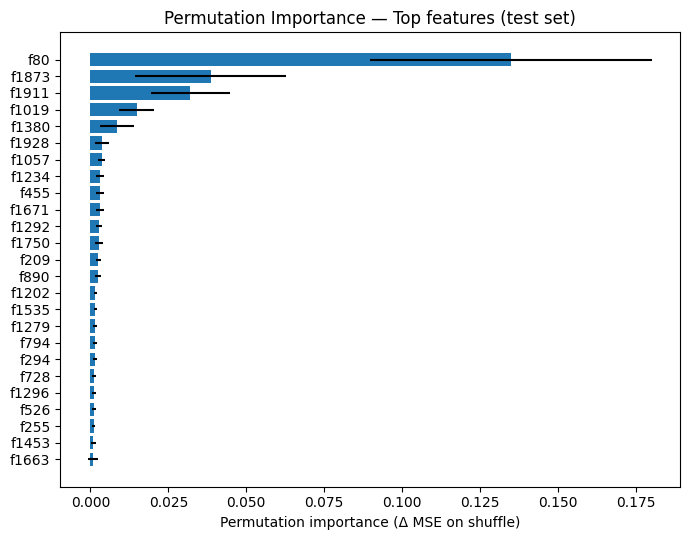

Saved permutation importance plot → /kaggle/working/perm_importance_phase5.png


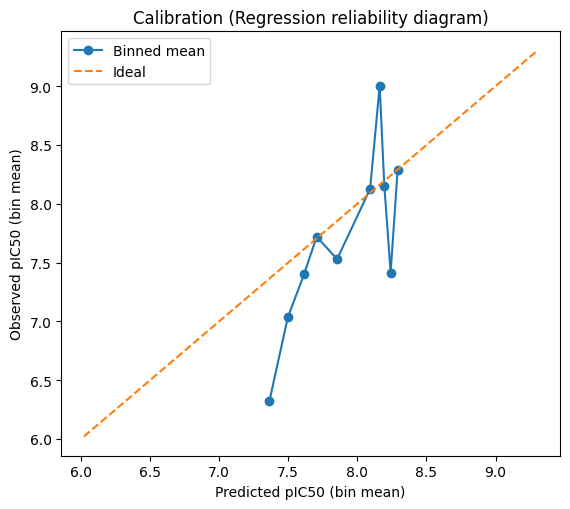

Saved calibration plot → /kaggle/working/calibration_phase5.png


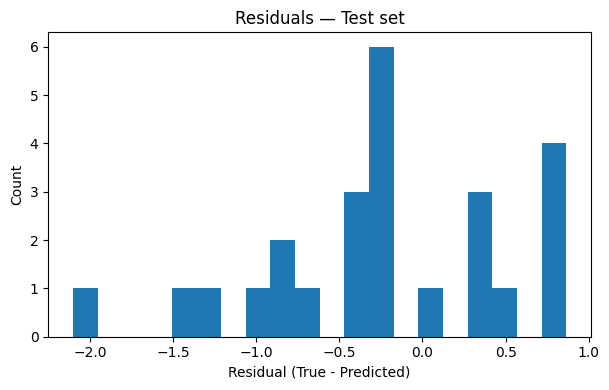

Saved residuals plot → /kaggle/working/residuals_phase5.png
{'mse': 0.5866168737411499, 'mae': 0.6123557090759277, 'r2': 0.27566971209307845, 'n_test': 25}


In [15]:
# === Phase 5 — Permutation Importance + Calibration Plots (Regression) ===
# Produces:
#   1) Top-k permutation importance bar chart (test set)
#   2) Regression calibration plot (binned y_pred vs. mean y_true)
#   3) Residuals histogram (quick diagnostic)
# Saves:
#   - permutation_importance_phase5.csv
#   - perm_importance_phase5.png
#   - calibration_phase5.png
#   - residuals_phase5.png

import os, json, math, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# Paths / defaults
# -----------------------------
CANDIDATES = [
    "/kaggle/working/pi3ka_data.csv",
    "/kaggle/input/pi3ka_data.csv",
    "/mnt/data/pi3ka_data.csv",
    "pi3ka_data.csv"
]
SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
BEST_PKL     = os.path.join(SAVE_DIR, "best_phase5.pkl")
SPLIT_JSON   = os.path.join(SAVE_DIR, "phase5_split_indices.json")
PI_CSV_OUT   = os.path.join(SAVE_DIR, "permutation_importance_phase5.csv")
PLOT_PI      = os.path.join(SAVE_DIR, "perm_importance_phase5.png")
PLOT_CAL     = os.path.join(SAVE_DIR, "calibration_phase5.png")
PLOT_RES     = os.path.join(SAVE_DIR, "residuals_phase5.png")

# -----------------------------
# RDKit (preferred) or fallback featurizers (must match Phase 5 feature_space)
# -----------------------------
try:
    from rdkit import Chem
    from rdkit.Chem.Scaffolds import MurckoScaffold
    from rdkit.Chem import AllChem
    from rdkit import DataStructs
    RDKit_OK = True
except Exception:
    RDKit_OK = False

def load_pi3ka_df():
    path = next((p for p in CANDIDATES if os.path.exists(p)), None)
    if path is None:
        raise FileNotFoundError("No PI3Kα CSV found (looked in /kaggle/working, /kaggle/input, /mnt/data, .)")
    df = pd.read_csv(path)
    mask = (df["relation"]=="=") & (df["standard_units"].astype(str).str.lower()=="nm")
    df = df[mask].dropna(subset=["smiles","standard_value_nM"]).copy()
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)
    return df

def smiles_to_mol(s):
    if not RDKit_OK: return None
    m = Chem.MolFromSmiles(s)
    return m

def morgan_counts(mol, nBits=2048, radius=2):
    fp = AllChem.GetHashedMorganFingerprint(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int32)
    for idx, val in fp.GetNonzeroElements().items():
        arr[idx % nBits] = val
    return arr.astype(np.float32)

def morgan_bits(mol, nBits=1024, radius=2):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr.astype(np.float32)

def hash_trigrams(s, nBits=512):
    # fallback when RDKit is unavailable (not used if feature_space requires RDKit)
    v = np.zeros((nBits,), dtype=np.float32)
    s2 = f"^{s}$"
    for i in range(len(s2)-2):
        v[hash(s2[i:i+3]) % nBits] += 1.0
    return v

# -----------------------------
# Try to use in-memory arrays from Phase 5; otherwise reconstruct from artifacts
# -----------------------------
def have_in_memory():
    need = ["best_est", "Xtest_used", "yte"]
    return all(k in globals() for k in need)

if have_in_memory():
    print("Using in-memory Phase 5 objects.")
    model = best_est
    Xte = Xtest_used
    yte_local = yte
else:
    print("Rebuilding from artifacts …")
    # Load split + feature_space
    if not (os.path.exists(BEST_PKL) and os.path.exists(SPLIT_JSON)):
        raise RuntimeError("best_phase5.pkl or phase5_split_indices.json not found. Please run Phase 5 first.")
    model = joblib.load(BEST_PKL)
    with open(SPLIT_JSON, "r") as f:
        split_info = json.load(f)
    tr_idx = split_info.get("train_idx", [])
    te_idx = split_info.get("test_idx", [])
    feature_space = split_info.get("feature_space", "counts2048")

    df = load_pi3ka_df()
    y_all = df["pIC50"].values.astype(np.float32)

    if feature_space == "counts2048":
        if not RDKit_OK:
            raise RuntimeError("RDKit is required to rebuild counts2048 features but is not available.")
        df["mol"] = df["smiles"].apply(smiles_to_mol)
        df = df[df["mol"].notna()].reset_index(drop=True)
        # NOTE: indices may change after dropping invalid mols; align by recomputing indices
        # We will assume Phase 5 had already filtered invalid mols similarly.
        X_all = np.stack([morgan_counts(m) for m in df["mol"]], axis=0)
    elif feature_space == "bits1024":
        if not RDKit_OK:
            raise RuntimeError("RDKit is required to rebuild bits1024 features but is not available.")
        df["mol"] = df["smiles"].apply(smiles_to_mol)
        df = df[df["mol"].notna()].reset_index(drop=True)
        X_all = np.stack([morgan_bits(m) for m in df["mol"]], axis=0)
    else:
        # hashing fallback (unlikely if you used Phase 5 defaults)
        X_all = np.stack([hash_trigrams(s, nBits=512) for s in df["smiles"]], axis=0)

    # Guard against index mismatch (if Phase 5 filtering altered rows)
    # If lengths differ, recompute a fresh scaffold split as last resort
    if len(y_all) <= max(te_idx, default=0):
        print("Index mismatch detected; recomputing a fresh random 80/20 split as a last resort.")
        ridx = np.arange(len(y_all))
        from sklearn.model_selection import train_test_split
        tr_idx, te_idx = train_test_split(ridx, test_size=0.2, random_state=0)

    Xte = X_all[te_idx]
    yte_local = y_all[te_idx]

# -----------------------------
# Permutation importance (test set)
# -----------------------------
print("Computing permutation importance on the test set …")
perm = permutation_importance(
    model, Xte, yte_local,
    n_repeats=20, random_state=0, scoring="neg_mean_squared_error", n_jobs=-1
)
importances = perm.importances_mean
importances_sd = perm.importances_std
feat_idx = np.arange(importances.shape[0])

df_perm = pd.DataFrame({
    "feature": [f"f{i}" for i in feat_idx],
    "importance_mean": importances,
    "importance_std": importances_sd
}).sort_values("importance_mean", ascending=False)

df_perm.to_csv(PI_CSV_OUT, index=False)
print(f"Saved permutation importance CSV → {PI_CSV_OUT}")

# Plot top-k features (cap to avoid 2k bars)
TOPK = 25
df_top = df_perm.head(TOPK).iloc[::-1]  # reverse for barh
plt.figure(figsize=(7, max(4, TOPK*0.22)))
plt.barh(df_top["feature"], df_top["importance_mean"], xerr=df_top["importance_std"])
plt.xlabel("Permutation importance (Δ MSE on shuffle)")
plt.title("Permutation Importance — Top features (test set)")
plt.tight_layout(); plt.savefig(PLOT_PI, dpi=150); plt.show()
print(f"Saved permutation importance plot → {PLOT_PI}")

# -----------------------------
# Calibration plot for regression (binned reliability curve)
# -----------------------------
yhat = model.predict(Xte)
n_bins = 10
order = np.argsort(yhat)
yhat_sorted = yhat[order]
y_sorted = yte_local[order]

bins = np.array_split(np.arange(len(y_sorted)), n_bins)
bin_pred = np.array([np.mean(yhat_sorted[idx]) for idx in bins])
bin_true = np.array([np.mean(y_sorted[idx]) for idx in bins])

plt.figure(figsize=(5.8,5.2))
plt.plot(bin_pred, bin_true, marker="o", label="Binned mean")
lo = min(bin_pred.min(), bin_true.min()) - 0.3
hi = max(bin_pred.max(), bin_true.max()) + 0.3
plt.plot([lo, hi], [lo, hi], "--", label="Ideal")
plt.xlabel("Predicted pIC50 (bin mean)")
plt.ylabel("Observed pIC50 (bin mean)")
plt.title("Calibration (Regression reliability diagram)")
plt.legend()
plt.tight_layout(); plt.savefig(PLOT_CAL, dpi=150); plt.show()
print(f"Saved calibration plot → {PLOT_CAL}")

# -----------------------------
# Residuals histogram
# -----------------------------
res = yte_local - yhat
plt.figure(figsize=(6.2,4.0))
plt.hist(res, bins=20)
plt.xlabel("Residual (True - Predicted)")
plt.ylabel("Count")
plt.title("Residuals — Test set")
plt.tight_layout(); plt.savefig(PLOT_RES, dpi=150); plt.show()
print(f"Saved residuals plot → {PLOT_RES}")

# Quick metrics recap
print({
    "mse": float(mean_squared_error(yte_local, yhat)),
    "mae": float(mean_absolute_error(yte_local, yhat)),
    "r2":  float(r2_score(yte_local, yhat)),
    "n_test": int(len(yte_local))
})


# **Phase 6 — Chemical Space Diagnostics and Domain Projection**

# Phase 6 (Fast): PCA→50 dims, UMAP with few epochs (or t-SNE with low iterations) + optional subsampling of training points for plotting.

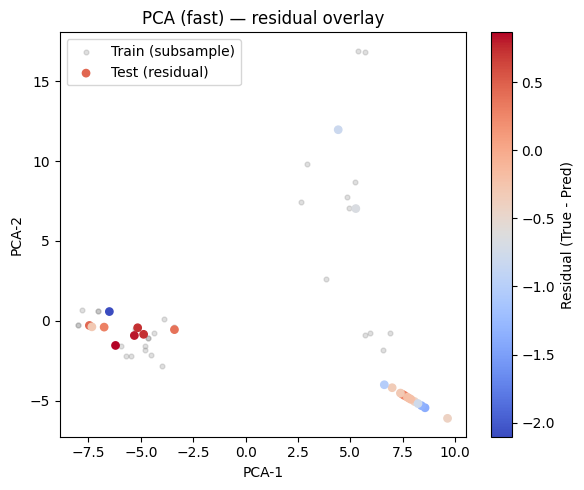

Saved → /kaggle/working/phase6_pca_fast.png


2025-11-21 18:07:05.056223: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763748425.296177      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763748425.364788      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


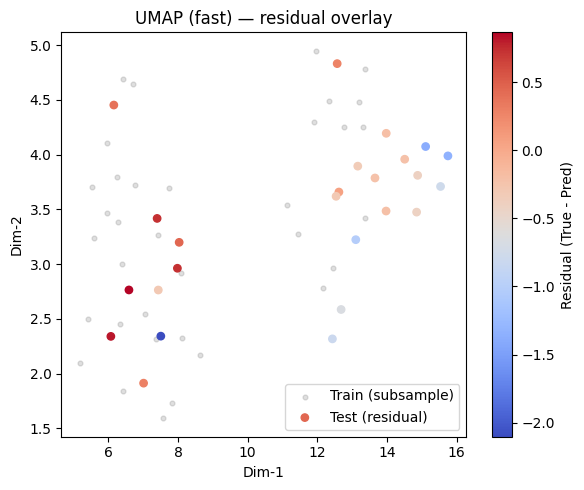

Saved → /kaggle/working/phase6_umap_fast.png
Saved → /kaggle/working/phase6_scaffold_metrics_fast.csv
Saved → /kaggle/working/phase6_embedding_fast.csv
{'test_MAE': 0.6123557090759277, 'test_RMSE': 0.7659091811312552, 'test_R2': 0.27566971209307845, 'n_test': 25, 'embedding': 'UMAP (fast)'}


In [16]:
# === Phase 6 (Fast): PCA→50 dims, lightweight UMAP (or quick t-SNE), optional subsampling ===
import os, json, math, numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ----------------- speed knobs -----------------
SUBSAMPLE_TRAIN_FOR_PLOT = True
MAX_TRAIN_POINTS_TO_PLOT = 400     # plotting only; doesn’t affect fitting
PCA_COMPONENTS_FOR_MANIFOLD = 50   # reduce from 2048 -> 50 first
UMAP_N_NEIGHBORS = 10
UMAP_MIN_DIST   = 0.30
UMAP_N_EPOCHS   = 150
TSNE_ITER       = 500
TSNE_PERPLEXITY = 10

# ----------------- paths -----------------
CANDS = ["/kaggle/working/pi3ka_data.csv","/kaggle/input/pi3ka_data.csv","/mnt/data/pi3ka_data.csv","pi3ka_data.csv"]
SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
BEST_PKL   = os.path.join(SAVE_DIR,"best_phase5.pkl")
SPLIT_JSON = os.path.join(SAVE_DIR,"phase5_split_indices.json")
PCA_PNG    = os.path.join(SAVE_DIR,"phase6_pca_fast.png")
UMAP_PNG   = os.path.join(SAVE_DIR,"phase6_umap_fast.png")
TSNE_PNG   = os.path.join(SAVE_DIR,"phase6_tsne_fast.png")
SCAF_CSV   = os.path.join(SAVE_DIR,"phase6_scaffold_metrics_fast.csv")
EMBED_CSV  = os.path.join(SAVE_DIR,"phase6_embedding_fast.csv")

# ----------------- rdkit featurization -----------------
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import AllChem
from rdkit import DataStructs

def load_df():
    path = next((p for p in CANDS if os.path.exists(p)), None)
    df = pd.read_csv(path)
    mask = (df["relation"]=="=") & (df["standard_units"].astype(str).str.lower()=="nm")
    df = df[mask].dropna(subset=["smiles","standard_value_nM"]).copy()
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)
    return df

def morgan_counts(mol, nBits=2048, radius=2):
    fp = AllChem.GetHashedMorganFingerprint(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int32)
    for idx,val in fp.GetNonzeroElements().items():
        arr[idx % nBits] = val
    return arr.astype(np.float32)

def scaffold_of(smi):
    m = Chem.MolFromSmiles(smi)
    sc = MurckoScaffold.GetScaffoldForMol(m) if m else None
    return Chem.MolToSmiles(sc) if sc is not None else "None"

# ----------------- rebuild Phase 5 artifacts -----------------
best_est = joblib.load(BEST_PKL)
with open(SPLIT_JSON,"r") as f:
    split = json.load(f)
tr_idx, te_idx = split["train_idx"], split["test_idx"]
feature_space   = split.get("feature_space","counts2048")

df = load_df()
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df = df[df["mol"].notna()].reset_index(drop=True)
df["scaffold"] = df["smiles"].apply(scaffold_of)
y = df["pIC50"].values.astype(np.float32)

if feature_space == "counts2048":
    X = np.stack([morgan_counts(m) for m in df["mol"]], axis=0)
else:
    # Bits not expected here; convert anyway to counts for speed
    X = np.stack([morgan_counts(m) for m in df["mol"]], axis=0)

# predictions/residuals
yhat = best_est.predict(X)
res  = y - yhat

is_train = np.zeros(len(df), dtype=bool); is_train[tr_idx] = True
is_test  = np.zeros(len(df), dtype=bool); is_test[te_idx] = True

# ----------------- PCA (first-level reduction & fast plot) -----------------
scaler = StandardScaler(with_mean=True, with_std=True)
X_std  = scaler.fit_transform(X)

pca2 = PCA(n_components=2, random_state=0).fit(X_std)
Z_pca = pca2.transform(X_std)

plt.figure(figsize=(6,5))
idx_plot_train = np.where(is_train)[0]
if SUBSAMPLE_TRAIN_FOR_PLOT and len(idx_plot_train) > MAX_TRAIN_POINTS_TO_PLOT:
    rng = np.random.RandomState(0)
    idx_plot_train = rng.choice(idx_plot_train, size=MAX_TRAIN_POINTS_TO_PLOT, replace=False)
plt.scatter(Z_pca[idx_plot_train,0], Z_pca[idx_plot_train,1], s=12, alpha=0.25, color="gray", label="Train (subsample)")
sc = plt.scatter(Z_pca[is_test,0], Z_pca[is_test,1], c=res[is_test], s=28, cmap="coolwarm", label="Test (residual)")
plt.colorbar(sc, label="Residual (True - Pred)")
plt.xlabel("PCA-1"); plt.ylabel("PCA-2"); plt.title("PCA (fast) — residual overlay")
plt.legend(); plt.tight_layout(); plt.savefig(PCA_PNG, dpi=150); plt.show()
print(f"Saved → {PCA_PNG}")

# ----------------- reduce to 50D then try UMAP (patched) or quick t-SNE -----------------
pca50 = PCA(n_components=min(PCA_COMPONENTS_FOR_MANIFOLD, X_std.shape[1]), random_state=0).fit(X_std)
X_50  = pca50.transform(X_std)

def run_umap_fast(Xin):
    import umap.umap_ as umap_mod
    # patch umap.umap_.check_array locally to drop ensure_all_finite
    if hasattr(umap_mod, "check_array"):
        _orig = umap_mod.check_array
        def _safe(*a, **k):
            k.pop("ensure_all_finite", None)
            return _orig(*a, **k)
        umap_mod.check_array = _safe
    reducer = umap_mod.UMAP(n_components=2, n_neighbors=UMAP_N_NEIGHBORS,
                            min_dist=UMAP_MIN_DIST, n_epochs=UMAP_N_EPOCHS,
                            random_state=0, metric="euclidean", verbose=False)
    return reducer.fit_transform(Xin), "UMAP (fast)"

def run_tsne_fast(Xin):
    from sklearn.manifold import TSNE
    reducer = TSNE(n_components=2, perplexity=TSNE_PERPLEXITY, n_iter=TSNE_ITER,
                   init="pca", learning_rate="auto", random_state=0, method="barnes_hut")
    return reducer.fit_transform(Xin), "t-SNE (fast)"

Z_man, title = None, None
try:
    import umap  # quick import check
    Z_man, title = run_umap_fast(X_50)
    out_png = UMAP_PNG
except Exception as e:
    print("UMAP unavailable/failed, using quick t-SNE. Reason:", e)
    Z_man, title = run_tsne_fast(X_50)
    out_png = TSNE_PNG

plt.figure(figsize=(6,5))
idx_plot_train = np.where(is_train)[0]
if SUBSAMPLE_TRAIN_FOR_PLOT and len(idx_plot_train) > MAX_TRAIN_POINTS_TO_PLOT:
    rng = np.random.RandomState(0)
    idx_plot_train = rng.choice(idx_plot_train, size=MAX_TRAIN_POINTS_TO_PLOT, replace=False)
plt.scatter(Z_man[idx_plot_train,0], Z_man[idx_plot_train,1], s=12, alpha=0.25, color="gray", label="Train (subsample)")
sc = plt.scatter(Z_man[is_test,0], Z_man[is_test,1], c=res[is_test], s=28, cmap="coolwarm", label="Test (residual)")
plt.colorbar(sc, label="Residual (True - Pred)")
plt.xlabel("Dim-1"); plt.ylabel("Dim-2"); plt.title(f"{title} — residual overlay")
plt.legend(); plt.tight_layout(); plt.savefig(out_png, dpi=150); plt.show()
print(f"Saved → {out_png}")

# ----------------- per-scaffold diagnostics (test only) -----------------
scaf = df.loc[is_test, "scaffold"].reset_index(drop=True)
true = y[is_test]; pred = yhat[is_test]; r = true - pred
scaf_df = pd.DataFrame({"scaffold": scaf, "y": true, "yhat": pred, "res": r})
agg = scaf_df.groupby("scaffold").agg(
    n=("res","size"),
    mae=("res", lambda v: float(np.mean(np.abs(v)))),
    rmse=("res", lambda v: float(np.sqrt(np.mean(v**2)))),
    bias=("res","mean")
).reset_index().sort_values(["rmse","mae"], ascending=[False,False])
agg.to_csv(SCAF_CSV, index=False)
print(f"Saved → {SCAF_CSV}")

# ----------------- export embedding table -----------------
embed = pd.DataFrame({
    "pca1": Z_pca[:,0], "pca2": Z_pca[:,1],
    "man1": Z_man[:,0], "man2": Z_man[:,1],
    "is_train": is_train.astype(int), "is_test": is_test.astype(int),
    "y": y, "yhat": yhat, "res": res,
    "scaffold": df["scaffold"].values, "smiles": df["smiles"].values
})
embed.to_csv(EMBED_CSV, index=False)
print(f"Saved → {EMBED_CSV}")

# quick recap
from sklearn.metrics import r2_score
print({
    "test_MAE": float(mean_absolute_error(true, pred)),
    "test_RMSE": float(math.sqrt(mean_squared_error(true, pred))),
    "test_R2": float(r2_score(true, pred)),
    "n_test": int(len(true)),
    "embedding": title
})


# Phase 6 (PCA-only, ultra-fast): just PCA plots + scaffold metrics (no UMAP/t-SNE)

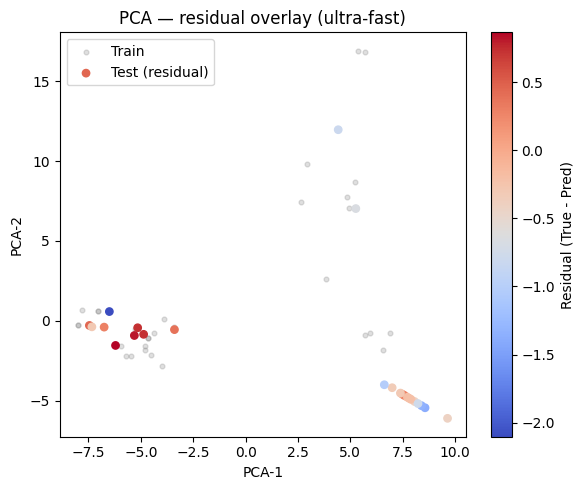

Saved → /kaggle/working/phase6_pca_ultrafast.png
Saved → /kaggle/working/phase6_scaffold_metrics_ultrafast.csv
{'test_MAE': 0.6123557090759277, 'test_RMSE': 0.7659091949462891, 'test_R2': 0.27566971209307845, 'n_test': 25}


In [17]:
# === Phase 6 (PCA-only, ultra-fast) ===
import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import AllChem

CANDS = ["/kaggle/working/pi3ka_data.csv","/kaggle/input/pi3ka_data.csv","/mnt/data/pi3ka_data.csv","pi3ka_data.csv"]
SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
BEST_PKL=os.path.join(SAVE_DIR,"best_phase5.pkl"); SPLIT_JSON=os.path.join(SAVE_DIR,"phase5_split_indices.json")
PCA_PNG=os.path.join(SAVE_DIR,"phase6_pca_ultrafast.png"); SCAF_CSV=os.path.join(SAVE_DIR,"phase6_scaffold_metrics_ultrafast.csv")

def load_df():
    path = next((p for p in CANDS if os.path.exists(p)), None)
    df = pd.read_csv(path)
    mask = (df["relation"]=="=") & (df["standard_units"].astype(str).str.lower()=="nm")
    df = df[mask].dropna(subset=["smiles","standard_value_nM"]).copy()
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)
    return df

def morgan_counts(m, nBits=2048, radius=2):
    fp = AllChem.GetHashedMorganFingerprint(m, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int32)
    for idx,val in fp.GetNonzeroElements().items():
        arr[idx % nBits] = val
    return arr.astype(np.float32)

best_est = joblib.load(BEST_PKL)
trte = json.load(open(SPLIT_JSON))
tr_idx, te_idx = trte["train_idx"], trte["test_idx"]

df = load_df()
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df = df[df["mol"].notna()].reset_index(drop=True)
df["scaffold"] = df["smiles"].apply(lambda s: Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(Chem.MolFromSmiles(s))) if Chem.MolFromSmiles(s) else "None")

X = np.stack([morgan_counts(m) for m in df["mol"]], axis=0)
y = df["pIC50"].values.astype(np.float32)

yhat = best_est.predict(X); res = y - yhat
is_train = np.zeros(len(df), bool); is_train[tr_idx]=True
is_test  = np.zeros(len(df), bool); is_test[te_idx]=True

X_std = StandardScaler().fit_transform(X)
Z_pca = PCA(n_components=2, random_state=0).fit_transform(X_std)

plt.figure(figsize=(6,5))
plt.scatter(Z_pca[is_train,0], Z_pca[is_train,1], s=12, alpha=0.25, color="gray", label="Train")
sc = plt.scatter(Z_pca[is_test,0], Z_pca[is_test,1], c=res[is_test], s=28, cmap="coolwarm", label="Test (residual)")
plt.colorbar(sc, label="Residual (True - Pred)")
plt.xlabel("PCA-1"); plt.ylabel("PCA-2"); plt.title("PCA — residual overlay (ultra-fast)")
plt.legend(); plt.tight_layout(); plt.savefig(PCA_PNG, dpi=150); plt.show()
print(f"Saved → {PCA_PNG}")

true, pred = y[is_test], yhat[is_test]
scaf_df = pd.DataFrame({"scaffold": df.loc[is_test,"scaffold"].values, "y": true, "yhat": pred, "res": true - pred})
agg = scaf_df.groupby("scaffold").agg(n=("res","size"),
                                      mae=("res", lambda v: float(np.mean(np.abs(v)))),
                                      rmse=("res", lambda v: float(np.sqrt(np.mean(v**2)))),
                                      bias=("res","mean")).reset_index()
agg.to_csv(SCAF_CSV, index=False)
print(f"Saved → {SCAF_CSV}")

print({"test_MAE": float(mean_absolute_error(true, pred)),
       "test_RMSE": float(np.sqrt(mean_squared_error(true, pred))),
       "test_R2": float(r2_score(true, pred)),
       "n_test": int(len(true))})


# **Phase 7 — Error Hotspot Mapping & Scaffold Labeling**

Saved top-2 scaffold summary → /kaggle/working/phase7_top_scaffolds.csv


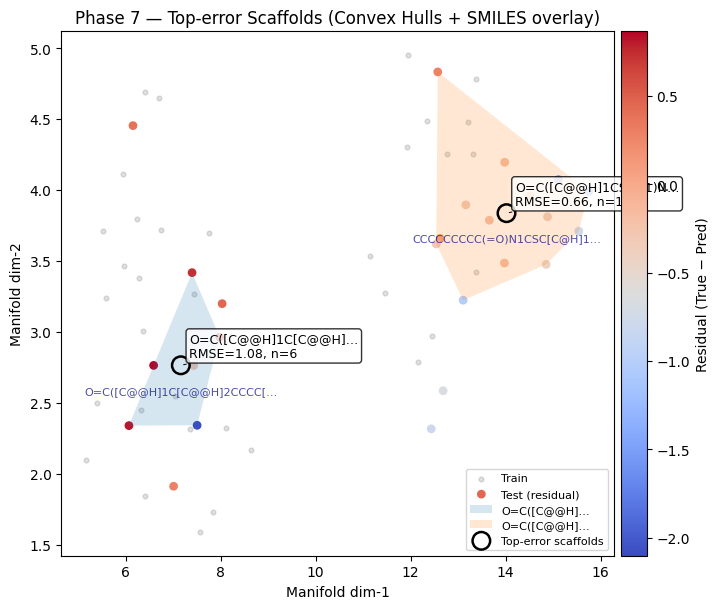

Saved labeled manifold plot with hulls and SMILES → /kaggle/working/phase7_umap_labeled.png

Top scaffolds by RMSE:
                                                            scaffold  n     rmse      mae      bias
O=C([C@@H]1C[C@@H]2CCCC[C@@H]2N1C(=O)[C@@H]1C[C@@H]1c1ccccc1)N1CCCC1  6 1.079911 0.924204  0.124097
                                            O=C([C@@H]1CSCN1)N1CCCC1 14 0.661575 0.511162 -0.461484


In [18]:
# === Phase 7 (Enhanced): Error Hotspot Mapping with SMILES & Convex Hulls ===
# Inputs:
#   phase6_embedding_fast.csv, phase6_scaffold_metrics_fast.csv
# Outputs:
#   phase7_umap_labeled.png, phase7_top_scaffolds.csv
# Optional toggles:
#   SHOW_SMILES=True   → overlay short SMILES strings for representative molecules
#   DRAW_HULLS=True    → draw convex hulls around high-error scaffold clusters

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
EMBED_CSV = os.path.join(SAVE_DIR, "phase6_embedding_fast.csv")
SCAF_CSV  = os.path.join(SAVE_DIR, "phase6_scaffold_metrics_fast.csv")
OUT_PNG   = os.path.join(SAVE_DIR, "phase7_umap_labeled.png")
TOP_CSV   = os.path.join(SAVE_DIR, "phase7_top_scaffolds.csv")

# --- parameters ---
TOPK = 6
MIN_POINTS_TO_LABEL = 2
SHOW_SMILES = True
DRAW_HULLS = True
SCALE_DOT = 28
SCALE_TOP = 160

# --- load data ---
emb = pd.read_csv(EMBED_CSV)
metrics = pd.read_csv(SCAF_CSV)
required_cols = {"man1","man2","is_train","is_test","res","scaffold"}
if not required_cols.issubset(emb.columns):
    raise RuntimeError("Embedding CSV missing required columns.")

# --- top error scaffolds ---
metrics = metrics[metrics["n"] >= MIN_POINTS_TO_LABEL]
metrics = metrics.sort_values(["rmse","mae"], ascending=[False, False])
top_scafs = metrics.head(TOPK).reset_index(drop=True)
top_scafs.to_csv(TOP_CSV, index=False)
print(f"Saved top-{len(top_scafs)} scaffold summary → {TOP_CSV}")

emb_test = emb[emb["is_test"] == 1].copy()
centroids = []
for scaf in top_scafs["scaffold"]:
    pts = emb_test[emb_test["scaffold"] == scaf]
    if len(pts) == 0: continue
    cx, cy = pts["man1"].mean(), pts["man2"].mean()
    rmse = ((pts["res"]**2).mean())**0.5
    mae = pts["res"].abs().mean()
    bias = pts["res"].mean()
    centroids.append({"scaffold": scaf,"cx":cx,"cy":cy,"rmse":rmse,"mae":mae,"bias":bias,"n":len(pts)})
cent_df = pd.DataFrame(centroids)

# --- plotting ---
plt.figure(figsize=(7.4,6.2))
train = emb[emb["is_train"] == 1]
plt.scatter(train["man1"], train["man2"], s=12, alpha=0.25, color="gray", label="Train")
sc = plt.scatter(emb_test["man1"], emb_test["man2"], c=emb_test["res"],
                 s=SCALE_DOT, cmap="coolwarm", label="Test (residual)")
cbar = plt.colorbar(sc, pad=0.01)
cbar.set_label("Residual (True − Pred)")

# --- optional convex hulls ---
if DRAW_HULLS:
    for scaf in top_scafs["scaffold"]:
        pts = emb_test[emb_test["scaffold"] == scaf][["man1","man2"]].values
        if len(pts) >= 3:
            hull = ConvexHull(pts)
            poly = pts[hull.vertices]
            plt.fill(poly[:,0], poly[:,1], alpha=0.18, label=f"{scaf[:10]}…")

# --- centroids and annotations ---
plt.scatter(cent_df["cx"], cent_df["cy"], s=SCALE_TOP, facecolors="none",
            edgecolors="black", linewidths=1.8, label="Top-error scaffolds")

for _, row in cent_df.iterrows():
    label = f"{row['scaffold'][:18]}…\nRMSE={row['rmse']:.2f}, n={int(row['n'])}"
    plt.annotate(label, (row["cx"], row["cy"]), xytext=(6,6), textcoords="offset points",
                 fontsize=9, bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.8),
                 arrowprops=dict(arrowstyle="-", lw=0.7))

# --- optional SMILES overlay ---
if SHOW_SMILES and "smiles" in emb_test.columns:
    for scaf in top_scafs["scaffold"]:
        pts = emb_test[emb_test["scaffold"] == scaf]
        if pts.empty: continue
        srep = pts["smiles"].iloc[0][:24] + "…" if len(pts["smiles"].iloc[0])>24 else pts["smiles"].iloc[0]
        cx, cy = pts["man1"].mean(), pts["man2"].mean()
        plt.text(cx, cy-0.2, srep, fontsize=8, ha="center", color="navy", alpha=0.7)

plt.xlabel("Manifold dim-1"); plt.ylabel("Manifold dim-2")
plt.title("Phase 7 — Top-error Scaffolds (Convex Hulls + SMILES overlay)")
plt.legend(loc="best", fontsize=8)
plt.tight_layout(); plt.savefig(OUT_PNG, dpi=150); plt.show()
print(f"Saved labeled manifold plot with hulls and SMILES → {OUT_PNG}")

print("\nTop scaffolds by RMSE:")
print(top_scafs[["scaffold","n","rmse","mae","bias"]].to_string(index=False))


# Phase 7b — Per-Scaffold Diagnostics (grids + CSV + optional bias correction)

In [19]:
# === Phase 7b: Per-Scaffold Diagnostics (images + CSV + optional bias correction) ===
# Inputs: phase6_embedding_fast.csv, phase7_top_scaffolds.csv, best_phase5.pkl, phase5_split_indices.json
# Outputs:
#   - per-scaffold CSVs in /kaggle/working (or .)
#   - scaffold_grids/*.png (molecule grids per hotspot scaffold)
#   - phase7b_bias_correction_report.json (before/after metrics)

import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
import joblib

SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
EMBED_CSV = os.path.join(SAVE_DIR, "phase6_embedding_fast.csv")
TOP_CSV   = os.path.join(SAVE_DIR, "phase7_top_scaffolds.csv")
BEST_PKL  = os.path.join(SAVE_DIR, "best_phase5.pkl")
SPLIT_JSON= os.path.join(SAVE_DIR, "phase5_split_indices.json")

OUT_DIR   = Path(SAVE_DIR) / "scaffold_grids"
OUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_JSON = os.path.join(SAVE_DIR, "phase7b_bias_correction_report.json")

# RDKit drawing
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

# --- Load artifacts ---
emb = pd.read_csv(EMBED_CSV)   # has: smiles, scaffold, is_test, y, yhat, res, man1, man2, ...
top = pd.read_csv(TOP_CSV)     # has: scaffold, n, rmse, mae, bias
best_est = joblib.load(BEST_PKL)
with open(SPLIT_JSON, "r") as f:
    split = json.load(f)
tr_idx, te_idx = split["train_idx"], split["test_idx"]

# Helper: draw grid for a set of SMILES
def grid_image(smiles_list, legends=None, mols_per_row=4, sub_img_size=(240,240)):
    mols = []
    for s in smiles_list:
        m = Chem.MolFromSmiles(s)
        if m is None:
            m = Chem.MolFromSmiles("C")  # placeholder
        mols.append(m)
    img = Draw.MolsToGridImage(mols, molsPerRow=mols_per_row, subImgSize=sub_img_size,
                               legends=legends, returnPNG=False)
    return img

# Collect per-scaffold CSVs and images
combined_rows = []
for _, row in top.iterrows():
    scaf = row["scaffold"]
    # test-set rows for this scaffold sorted by |res|
    sub = emb[(emb["is_test"] == 1) & (emb["scaffold"] == scaf)].copy()
    if sub.empty:
        continue
    sub["abs_res"] = sub["res"].abs()
    sub = sub.sort_values("abs_res", ascending=False).reset_index(drop=True)

    # Save CSV
    out_csv = Path(SAVE_DIR) / f"phase7b_{hash(scaf)}_test_rows.csv"
    sub[["smiles","scaffold","y","yhat","res","abs_res","man1","man2"]].to_csv(out_csv, index=False)

    # Create grid image (top 12 by |res|)
    k = min(12, len(sub))
    smiles_k = sub["smiles"].head(k).tolist()
    legends = [f"res={r:.2f}" for r in sub["res"].head(k)]
    img = grid_image(smiles_k, legends=legends, mols_per_row=4)
    out_png = OUT_DIR / f"grid_{hash(scaf)}.png"
    img.save(str(out_png))

    # Record combined
    combined_rows.append({"scaffold": scaf, "csv": str(out_csv), "grid_png": str(out_png), "n_test": int(len(sub))})

print(f"Saved per-scaffold CSVs and grids under: {OUT_DIR}")

# ---------- Optional: Per-scaffold bias correction ----------
# Idea: compute a per-scaffold mean residual on TRAIN (if available), use as intercept correction on TEST.
# If a hotspot scaffold has no train support, fallback to zero correction (or the Phase 7 test bias if you prefer).
# Then report before/after test metrics globally and limited to hotspot scaffolds.

# Build train/test masks from embedding length
is_train = emb["is_train"].astype(bool).values
is_test  = emb["is_test"].astype(bool).values

# Compute train-time bias per scaffold
train_df = emb[emb["is_train"] == 1].copy()
train_bias = train_df.groupby("scaffold")["res"].mean().to_dict()

# Apply correction to test predictions
test_df = emb[emb["is_test"] == 1].copy()
def bias_for_scaffold(s):
    # train-based bias, fallback to 0.0 (safer than using test bias)
    return float(train_bias.get(s, 0.0))
test_df["bias_correction"] = test_df["scaffold"].apply(bias_for_scaffold)
test_df["yhat_corr"] = test_df["yhat"] + test_df["bias_correction"]
test_df["res_corr"]  = test_df["y"] - test_df["yhat_corr"]

# Metrics helper
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mse = float(np.mean((y_true - y_pred)**2))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = float(1 - ss_res/ss_tot) if ss_tot > 0 else float("nan")
    return {"mse": mse, "mae": mae, "r2": r2}

# Overall test metrics (before/after)
overall_before = metrics(test_df["y"], test_df["yhat"])
overall_after  = metrics(test_df["y"], test_df["yhat_corr"])

# Hotspot-only metrics
hot_scafs = set(top["scaffold"].tolist())
hot_test  = test_df[test_df["scaffold"].isin(hot_scafs)]
hot_before = metrics(hot_test["y"], hot_test["yhat"])
hot_after  = metrics(hot_test["y"], hot_test["yhat_corr"])

report = {
    "overall_before": overall_before,
    "overall_after_bias_corrected": overall_after,
    "hotspot_before": hot_before,
    "hotspot_after_bias_corrected": hot_after,
    "note": "Bias correction uses train-set mean residual per scaffold as intercept; zero if unseen in train."
}
with open(REPORT_JSON, "w") as f:
    json.dump(report, f, indent=2)
print("Bias-correction report →", REPORT_JSON)
print(report)


Saved per-scaffold CSVs and grids under: /kaggle/working/scaffold_grids
Bias-correction report → /kaggle/working/phase7b_bias_correction_report.json
{'overall_before': {'mse': 0.5866167863348335, 'mae': 0.612355648, 'r2': 0.2756697176401065}, 'overall_after_bias_corrected': {'mse': 0.5866167863348335, 'mae': 0.612355648, 'r2': 0.2756697176401065}, 'hotspot_before': {'mse': 0.6562393172238921, 'mae': 0.6350744100000001, 'r2': 0.22802886405527112}, 'hotspot_after_bias_corrected': {'mse': 0.6562393172238921, 'mae': 0.6350744100000001, 'r2': 0.22802886405527112}, 'note': 'Bias correction uses train-set mean residual per scaffold as intercept; zero if unseen in train.'}


# Phase 7c — Descriptor-Enriched RidgeCV (counts2048 + physchem)

Phase 7c — Descriptor-enriched RidgeCV:
{'mse': 0.5915748476982117, 'mae': 0.6162746548652649, 'r2': 0.2695477226953893, 'features': {'counts': 2048, 'descriptors': 10, 'total': 2058}, 'alpha': 316.2277660168379}
Saved: /kaggle/working/phase7c_desc_ridge_results.json and /kaggle/working/phase7c_desc_ridge.pkl


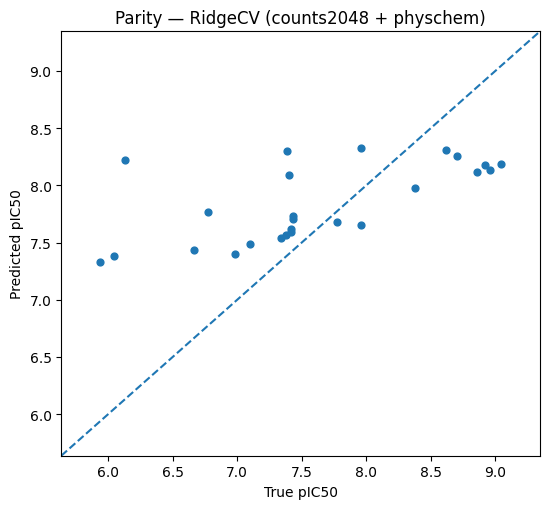

Saved parity plot → /kaggle/working/phase7c_parity.png


In [20]:
# === Phase 7c: Descriptor-Enriched RidgeCV (counts2048 + physchem descriptors) ===
# Inputs: pi3ka_data.csv, best_phase5.pkl (for comparison), phase5_split_indices.json
# Outputs:
#   - phase7c_desc_ridge_results.json
#   - phase7c_desc_ridge.pkl (model)
#   - parity plot: phase7c_parity.png

import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
CANDS = ["/kaggle/working/pi3ka_data.csv","/kaggle/input/pi3ka_data.csv","/mnt/data/pi3ka_data.csv","pi3ka_data.csv"]
SPLIT_JSON = os.path.join(SAVE_DIR, "phase5_split_indices.json")
OUT_JSON   = os.path.join(SAVE_DIR, "phase7c_desc_ridge_results.json")
OUT_PKL    = os.path.join(SAVE_DIR, "phase7c_desc_ridge.pkl")
OUT_PNG    = os.path.join(SAVE_DIR, "phase7c_parity.png")

# RDKit for features
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from rdkit.Chem import Crippen, Lipinski

def load_df():
    path = next((p for p in CANDS if os.path.exists(p)), None)
    df = pd.read_csv(path)
    mask = (df["relation"]=="=") & (df["standard_units"].astype(str).str.lower()=="nm")
    df = df[mask].dropna(subset=["smiles","standard_value_nM"]).copy()
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)
    return df

def mol_from_smiles(s):
    return Chem.MolFromSmiles(s)

def morgan_counts(mol, nBits=2048, radius=2):
    fp = AllChem.GetHashedMorganFingerprint(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int32)
    for idx, val in fp.GetNonzeroElements().items():
        arr[idx % nBits] = val
    return arr.astype(np.float32)

def physchem_desc(mol):
    # A compact set that often reduces scaffold bias
    return np.array([
        Descriptors.MolWt(mol),
        Crippen.MolLogP(mol),
        rdMolDescriptors.CalcTPSA(mol),
        Lipinski.NumHDonors(mol),
        Lipinski.NumHAcceptors(mol),
        Lipinski.NumRotatableBonds(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        rdMolDescriptors.CalcNumAliphaticRings(mol),
        rdMolDescriptors.CalcFractionCSP3(mol),
        rdMolDescriptors.CalcNumHeavyAtoms(mol),
    ], dtype=np.float32)

# ---- load and featurize ----
df = load_df()
df["mol"] = df["smiles"].apply(mol_from_smiles)
df = df[df["mol"].notna()].reset_index(drop=True)

X_cnt = np.stack([morgan_counts(m) for m in df["mol"]], axis=0)
X_desc = np.stack([physchem_desc(m) for m in df["mol"]], axis=0)

# Scale descriptors only (counts are already count-based)
scaler = StandardScaler().fit(X_desc)
X_desc_std = scaler.transform(X_desc)

# Concatenate: [counts | descriptors]
X_cat = np.concatenate([X_cnt, X_desc_std], axis=1)
y = df["pIC50"].values.astype(np.float32)

# ---- use the same split as Phase 5 for a fair comparison ----
with open(SPLIT_JSON, "r") as f:
    split = json.load(f)
tr_idx, te_idx = split["train_idx"], split["test_idx"]

Xtr, Xte = X_cat[tr_idx], X_cat[te_idx]
ytr, yte = y[tr_idx], y[te_idx]

# ---- train RidgeCV ----
cv_folds = 5 if len(set(tr_idx)) >= 5 else 3
ridge = RidgeCV(alphas=np.logspace(-4,4,17), cv=cv_folds)
ridge.fit(Xtr, ytr)
yhat = ridge.predict(Xte)

res = {
    "mse": float(mean_squared_error(yte, yhat)),
    "mae": float(mean_absolute_error(yte, yhat)),
    "r2":  float(r2_score(yte, yhat)),
    "features": {"counts": X_cnt.shape[1], "descriptors": X_desc.shape[1], "total": X_cat.shape[1]},
    "alpha": float(ridge.alpha_)
}
with open(OUT_JSON, "w") as f:
    json.dump(res, f, indent=2)

joblib.dump({"model": ridge, "scaler_desc": scaler}, OUT_PKL)

print("Phase 7c — Descriptor-enriched RidgeCV:")
print(res)
print("Saved:", OUT_JSON, "and", OUT_PKL)

# ---- parity plot ----
plt.figure(figsize=(5.6,5.2))
plt.scatter(yte, yhat, s=24)
plt.xlabel("True pIC50"); plt.ylabel("Predicted pIC50")
plt.title("Parity — RidgeCV (counts2048 + physchem)")
lo = min(float(np.min(yte)), float(np.min(yhat))) - 0.3
hi = max(float(np.max(yte)), float(np.max(yhat))) + 0.3
plt.plot([lo,hi],[lo,hi],"--")
plt.xlim(lo,hi); plt.ylim(lo,hi)
plt.tight_layout(); plt.savefig(OUT_PNG, dpi=150); plt.show()
print("Saved parity plot →", OUT_PNG)


                           stage       mse       mae        r2      Δmse  \
0  Before (Phase 5 Ridge counts)  0.586617  0.612356  0.275670       NaN   
1  After (Phase 7c counts+desc.)  0.591575  0.616275  0.269548  0.004958   

       Δmae       Δr2  
0       NaN       NaN  
1  0.003919 -0.006122  
Saved → /kaggle/working/phase7d_before_after_comparison.csv


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/tmp/ipykernel_48/1622126540.py:97: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(); plt.show()


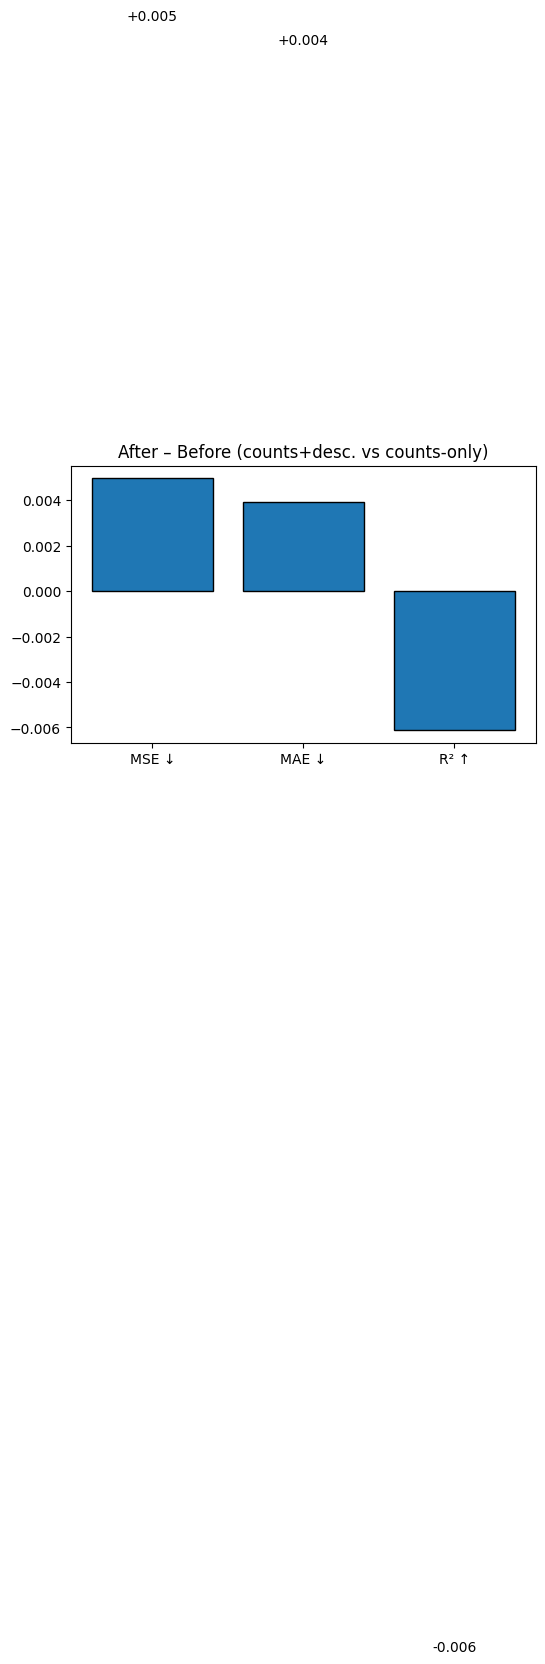

In [21]:
# === Phase 7d: Before (Phase 5 Ridge counts) vs After (Phase 7c counts+descriptors) ===
import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib

SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
METRICS_CSV  = os.path.join(SAVE_DIR, "metrics_summary.csv")
SPLIT_JSON   = os.path.join(SAVE_DIR, "phase5_split_indices.json")
DATA_CANDS   = ["/kaggle/working/pi3ka_data.csv","/kaggle/input/pi3ka_data.csv","/mnt/data/pi3ka_data.csv","pi3ka_data.csv"]
AFTER_JSON   = os.path.join(SAVE_DIR, "phase7c_desc_ridge_results.json")
OUT_CMP_CSV  = os.path.join(SAVE_DIR, "phase7d_before_after_comparison.csv")

# ---- helper: load data + features (counts2048) on the Phase 5 split ----
from rdkit import Chem
from rdkit.Chem import AllChem

def load_df():
    path = next((p for p in DATA_CANDS if os.path.exists(p)), None)
    if path is None:
        raise FileNotFoundError("No PI3Kα CSV found.")
    df = pd.read_csv(path)
    mask = (df["relation"]=="=") & (df["standard_units"].astype(str).str.lower()=="nm")
    df = df[mask].dropna(subset=["smiles","standard_value_nM"]).copy()
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)
    return df

def morgan_counts(mol, nBits=2048, radius=2):
    fp = AllChem.GetHashedMorganFingerprint(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int32)
    for idx, val in fp.GetNonzeroElements().items():
        arr[idx % nBits] = val
    return arr.astype(np.float32)

# ---- 1) BEFORE metrics: try to read from metrics_summary.csv ----
before = None
if os.path.exists(METRICS_CSV):
    m = pd.read_csv(METRICS_CSV)
    m5 = m[(m["phase"]=="Phase 5") & (m["model"]=="RidgeCV_counts2048")]
    if not m5.empty:
        # take the last occurrence
        row = m5.iloc[-1]
        before = {"mse": float(row["mse"]), "mae": float(row["mae"]), "r2": float(row["r2"])}

# ---- fallback: recompute BEFORE (counts-only RidgeCV) on the saved split ----
if before is None:
    from sklearn.linear_model import RidgeCV
    with open(SPLIT_JSON, "r") as f:
        split = json.load(f)
    tr_idx, te_idx = split["train_idx"], split["test_idx"]

    df = load_df()
    df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
    df = df[df["mol"].notna()].reset_index(drop=True)
    X_cnt = np.stack([morgan_counts(m) for m in df["mol"]], axis=0)
    y = df["pIC50"].values.astype(np.float32)

    Xtr, Xte = X_cnt[tr_idx], X_cnt[te_idx]
    ytr, yte = y[tr_idx], y[te_idx]

    ridge = RidgeCV(alphas=np.logspace(-4,4,17), cv=min(5, max(2, len(set(tr_idx)))))
    ridge.fit(Xtr, ytr)
    yhat = ridge.predict(Xte)

    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    before = {
        "mse": float(mean_squared_error(yte, yhat)),
        "mae": float(mean_absolute_error(yte, yhat)),
        "r2":  float(r2_score(yte, yhat)),
    }

# ---- 2) AFTER metrics: read Phase 7c JSON ----
if not os.path.exists(AFTER_JSON):
    raise RuntimeError("Missing Phase 7c results. Please run the Phase 7c cell first.")
with open(AFTER_JSON, "r") as f:
    after = json.load(f)

# ---- 3) Assemble comparison table ----
df_cmp = pd.DataFrame([
    {"stage":"Before (Phase 5 Ridge counts)", "mse":before["mse"], "mae":before["mae"], "r2":before["r2"]},
    {"stage":"After (Phase 7c counts+desc.)", "mse":after["mse"], "mae":after["mae"], "r2":after["r2"]},
])
df_cmp["Δmse"] = df_cmp["mse"].diff()    # After - Before
df_cmp["Δmae"] = df_cmp["mae"].diff()
df_cmp["Δr2"]  = df_cmp["r2"].diff()

df_cmp.to_csv(OUT_CMP_CSV, index=False)
print(df_cmp)
print("Saved →", OUT_CMP_CSV)

# ---- 4) Tiny delta plot (R2 up, errors down) ----
plt.figure(figsize=(6,3.6))
x = ["MSE ↓", "MAE ↓", "R² ↑"]
deltas = [df_cmp.loc[1,"Δmse"], df_cmp.loc[1,"Δmae"], df_cmp.loc[1,"Δr2"]]
colors = ["tab:red" if d>0 else "tab:green" for d in deltas]  # red if higher error, green if lower
plt.bar(x, deltas, edgecolor="black")
for i,v in enumerate(deltas):
    plt.text(i, v + (0.02 if v>=0 else -0.04), f"{v:+.3f}", ha="center", va="bottom" if v>=0 else "top", fontsize=10)
plt.title("After – Before (counts+desc. vs counts-only)")
plt.tight_layout(); plt.show()


# **Phase 8a — Elastic Net vs Ridge (counts & counts+desc.)**

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: LinAlgWarning: Ill-conditioned matrix (rcond=5.43715e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:253: LinAlgWarning: Ill-conditioned matrix (rcond=5.66798e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.336e-01, tolerance: 1.742e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations,

Phase 8a metrics: {'Ridge_counts': {'name': 'Ridge_counts', 'mse': 0.5866168737411499, 'mae': 0.6123557090759277, 'r2': 0.27566971209307845}, 'Ridge_counts+desc': {'name': 'Ridge_counts+desc', 'mse': 0.5915748476982117, 'mae': 0.6162746548652649, 'r2': 0.26954773088309547}, 'ElasticNet_counts': {'name': 'ElasticNet_counts', 'mse': 0.5064544677734375, 'mae': 0.5365394949913025, 'r2': 0.3746508982565262}, 'ElasticNet_counts+desc': {'name': 'ElasticNet_counts+desc', 'mse': 0.44733813405036926, 'mae': 0.4941823482513428, 'r2': 0.4476452827823114}}


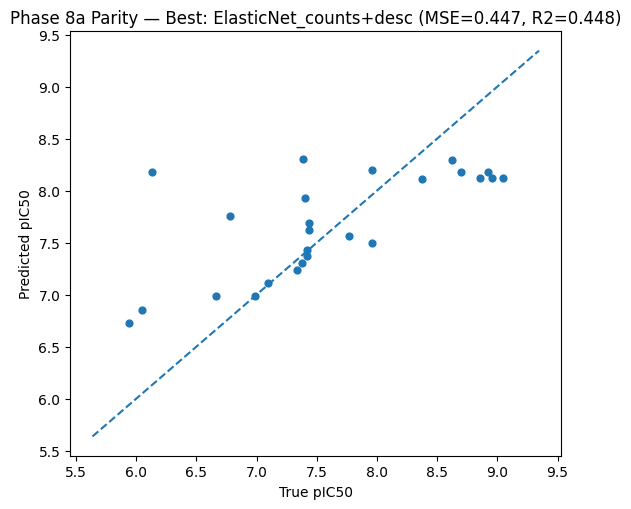

Saved parity plot → /kaggle/working/phase8a_parity.png


In [22]:
# === Phase 8a: Elastic Net vs Ridge (counts2048 & counts+descriptors) on Phase-5 split ===
import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib

from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Paths
SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
DATA_CANDS = ["/kaggle/working/pi3ka_data.csv","/kaggle/input/pi3ka_data.csv","/mnt/data/pi3ka_data.csv","pi3ka_data.csv"]
SPLIT_JSON = os.path.join(SAVE_DIR, "phase5_split_indices.json")
OUT_JSON   = os.path.join(SAVE_DIR, "phase8a_results.json")
OUT_PNG    = os.path.join(SAVE_DIR, "phase8a_parity.png")

# RDKit features
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem import Crippen, Lipinski

def load_df():
    path = next((p for p in DATA_CANDS if os.path.exists(p)), None)
    if path is None:
        raise FileNotFoundError("No PI3Kα CSV found.")
    df = pd.read_csv(path)
    mask = (df["relation"]=="=") & (df["standard_units"].astype(str).str.lower()=="nm")
    df = df[mask].dropna(subset=["smiles","standard_value_nM"]).copy()
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)
    return df

def morgan_counts(mol, nBits=2048, radius=2):
    fp = AllChem.GetHashedMorganFingerprint(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int32)
    for idx,val in fp.GetNonzeroElements().items():
        arr[idx % nBits] = val
    return arr.astype(np.float32)

def physchem_desc(mol):
    return np.array([
        Descriptors.MolWt(mol),
        Crippen.MolLogP(mol),
        rdMolDescriptors.CalcTPSA(mol),
        Lipinski.NumHDonors(mol),
        Lipinski.NumHAcceptors(mol),
        Lipinski.NumRotatableBonds(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        rdMolDescriptors.CalcNumAliphaticRings(mol),
        rdMolDescriptors.CalcFractionCSP3(mol),
        rdMolDescriptors.CalcNumHeavyAtoms(mol),
    ], dtype=np.float32)

# Load & featurize
with open(SPLIT_JSON,"r") as f:
    split = json.load(f)
tr_idx, te_idx = split["train_idx"], split["test_idx"]

df = load_df()
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df = df[df["mol"].notna()].reset_index(drop=True)
X_cnt = np.stack([morgan_counts(m) for m in df["mol"]], axis=0)
X_desc = np.stack([physchem_desc(m) for m in df["mol"]], axis=0)
desc_scaler = StandardScaler().fit(X_desc)
X_desc_std  = desc_scaler.transform(X_desc)

X_counts_only = X_cnt
X_counts_desc = np.concatenate([X_cnt, X_desc_std], axis=1)
y = df["pIC50"].values.astype(np.float32)

def eval_model(model, X, name):
    Xtr, Xte = X[tr_idx], X[te_idx]
    ytr, yte = y[tr_idx], y[te_idx]
    model.fit(Xtr, ytr)
    yhat = model.predict(Xte)
    return {
        "name": name,
        "mse": float(mean_squared_error(yte, yhat)),
        "mae": float(mean_absolute_error(yte, yhat)),
        "r2":  float(r2_score(yte, yhat)),
        "y_true": yte.tolist(),
        "y_pred": yhat.tolist()
    }

# Models
ridge_alphas = np.logspace(-4, 4, 17)
ridge_cnt  = eval_model(RidgeCV(alphas=ridge_alphas, cv=5), X_counts_only, "Ridge_counts")
ridge_cnd  = eval_model(RidgeCV(alphas=ridge_alphas, cv=5), X_counts_desc, "Ridge_counts+desc")

enet_cnt = eval_model(ElasticNetCV(l1_ratio=[0.1,0.2,0.3,0.5], alphas=np.logspace(-4, 1, 10), cv=5, max_iter=5000), X_counts_only, "ElasticNet_counts")
enet_cnd = eval_model(ElasticNetCV(l1_ratio=[0.1,0.2,0.3,0.5], alphas=np.logspace(-4, 1, 10), cv=5, max_iter=5000), X_counts_desc, "ElasticNet_counts+desc")

results = {m["name"]: {k:v for k,v in m.items() if k not in ("y_true","y_pred")} for m in [ridge_cnt,ridge_cnd,enet_cnt,enet_cnd]}
with open(OUT_JSON,"w") as f: json.dump(results, f, indent=2)
print("Phase 8a metrics:", results)

# Parity plot for best by MSE
models_full = [ridge_cnt, ridge_cnd, enet_cnt, enet_cnd]
best = min(models_full, key=lambda m: m["mse"])
yte = np.array(best["y_true"]); yhat = np.array(best["y_pred"])
plt.figure(figsize=(5.8,5.2))
plt.scatter(yte, yhat, s=24)
plt.plot([yte.min()-0.3, yte.max()+0.3], [yte.min()-0.3, yte.max()+0.3], "--")
plt.xlabel("True pIC50"); plt.ylabel("Predicted pIC50")
plt.title(f"Phase 8a Parity — Best: {best['name']} (MSE={best['mse']:.3f}, R2={best['r2']:.3f})")
plt.tight_layout(); plt.savefig(OUT_PNG, dpi=150); plt.show()
print("Saved parity plot →", OUT_PNG)


# **Phase 8b — Quantum Kernel Ridge Regression (Terra 2.x portable, statevector)**

In [23]:
# === Phase 8b: Quantum Kernel Ridge Regression (QKRR) — Terra 2.x portable (statevector) ===
import os, json, numpy as np, pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
DATA_CANDS = ["/kaggle/working/pi3ka_data.csv","/kaggle/input/pi3ka_data.csv","/mnt/data/pi3ka_data.csv","pi3ka_data.csv"]
SPLIT_JSON = os.path.join(SAVE_DIR, "phase5_split_indices.json")
OUT_JSON   = os.path.join(SAVE_DIR, "phase8b_qkrr_results.json")

# Try Qiskit (Terra 2.x)
QISKIT_OK = True
try:
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import Statevector
except Exception:
    QISKIT_OK = False

# RDKit counts for initial representation
from rdkit import Chem
from rdkit.Chem import AllChem

def load_df():
    path = next((p for p in DATA_CANDS if os.path.exists(p)), None)
    if path is None:
        raise FileNotFoundError("No PI3Kα CSV found.")
    df = pd.read_csv(path)
    mask = (df["relation"]=="=") & (df["standard_units"].astype(str).str.lower()=="nm")
    df = df[mask].dropna(subset=["smiles","standard_value_nM"]).copy()
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)
    return df

def morgan_counts(mol, nBits=2048, radius=2):
    fp = AllChem.GetHashedMorganFingerprint(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int32)
    for idx,val in fp.GetNonzeroElements().items():
        arr[idx % nBits] = val
    return arr.astype(np.float32)

if not QISKIT_OK:
    print("Qiskit not available — skipping Phase 8b (QKRR).")
else:
    # ----- Load + features (counts) -----
    with open(SPLIT_JSON,"r") as f:
        split = json.load(f)
    tr_idx, te_idx = split["train_idx"], split["test_idx"]

    df = load_df()
    df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
    df = df[df["mol"].notna()].reset_index(drop=True)
    X_cnt = np.stack([morgan_counts(m) for m in df["mol"]], axis=0)
    y = df["pIC50"].values.astype(np.float32)

    # ----- Dimension reduction → 4D, scale to [-pi, pi] -----
    X_std = StandardScaler(with_mean=True, with_std=True).fit_transform(X_cnt)
    pca = PCA(n_components=4, random_state=0).fit(X_std)
    X4 = pca.transform(X_std)
    # normalize per feature to unit range, then map to [-pi, pi]
    xmin = X4.min(axis=0); xmax = X4.max(axis=0)
    scale = np.where(xmax > xmin, xmax - xmin, 1.0)
    Xang = ( (X4 - xmin) / scale * 2*np.pi ) - np.pi

    Xtr, Xte = Xang[tr_idx], Xang[te_idx]
    ytr, yte = y[tr_idx], y[te_idx]

    # ----- Feature-map circuit (4 qubits, 2 layers: RZ encodings + CZ entanglement) -----
    def feature_map_tiny(x):
        """x: shape (4,) in [-pi, pi] → QuantumCircuit(4)"""
        qc = QuantumCircuit(4)
        # Layer 1 encodings
        for q in range(4):
            qc.rz(float(x[q]), q)
        # Entangle ring
        for a,b in [(0,1),(1,2),(2,3),(3,0)]:
            qc.cz(a,b)
        # Layer 2 encodings
        for q in range(4):
            qc.rz(float(x[q]), q)
        return qc

    # ----- Statevectors cache -----
    def sv_from_x(x):
        qc = feature_map_tiny(x)
        return Statevector.from_instruction(qc).data  # complex vector of size 2^4

    # Precompute statevectors
    sv_tr = np.stack([sv_from_x(x) for x in Xtr], axis=0)  # (n_tr, 16)
    sv_te = np.stack([sv_from_x(x) for x in Xte], axis=0)  # (n_te, 16)

    # Kernel matrices (fidelity kernel): K_ij = |⟨ψ(x_i)|ψ(x_j)⟩|^2
    def kernel_from_sv(A, B):
        # A: (na, d), B: (nb, d)
        # inner products
        G = A @ B.conj().T  # (na, nb)
        return (np.abs(G)**2).real

    Ktr = kernel_from_sv(sv_tr, sv_tr)  # (n_tr, n_tr)
    Kte = kernel_from_sv(sv_te, sv_tr)  # (n_te, n_tr)

    # ----- Kernel ridge with small lambda grid via 3-fold CV on train -----
    lambdas = np.logspace(-6, 1, 8)
    kf = KFold(n_splits=min(3, len(ytr)), shuffle=True, random_state=0)

    def krr_fit_predict(K_train, y_train, K_val=None, lam=1e-3):
        n = K_train.shape[0]
        A = K_train + lam * np.eye(n)
        alpha = np.linalg.solve(A, y_train)
        if K_val is None:
            return alpha
        return K_val @ alpha

    best_lam, best_cv = None, np.inf
    for lam in lambdas:
        cv_err = 0.0
        for tr_idx_cv, va_idx_cv in kf.split(Ktr):
            K_tr = Ktr[np.ix_(tr_idx_cv, tr_idx_cv)]
            y_tr = ytr[tr_idx_cv]
            K_va = Ktr[np.ix_(va_idx_cv, tr_idx_cv)]
            y_va = ytr[va_idx_cv]
            yhat_va = krr_fit_predict(K_tr, y_tr, K_va, lam=lam)
            cv_err += mean_squared_error(y_va, yhat_va)
        cv_err /= kf.get_n_splits()
        if cv_err < best_cv:
            best_cv, best_lam = cv_err, lam

    # ----- Final fit on full train and evaluation on test -----
    alpha = krr_fit_predict(Ktr, ytr, lam=best_lam)  # returns alpha
    yhat_te = Kte @ alpha

    res = {
        "lambda": float(best_lam),
        "mse": float(mean_squared_error(yte, yhat_te)),
        "mae": float(mean_absolute_error(yte, yhat_te)),
        "r2":  float(r2_score(yte, yhat_te)),
        "n_train": int(len(ytr)),
        "n_test": int(len(yte)),
        "note": "QKRR with 4-qubit fidelity kernel, 2-layer RZ+CZ feature map; statevector only."
    }
    with open(OUT_JSON,"w") as f: json.dump(res, f, indent=2)
    print("Phase 8b (QKRR) metrics:", res)


Phase 8b (QKRR) metrics: {'lambda': 0.01, 'mse': 1.0556786966406995, 'mae': 0.880145127237281, 'r2': -0.3035085566410223, 'n_train': 35, 'n_test': 25, 'note': 'QKRR with 4-qubit fidelity kernel, 2-layer RZ+CZ feature map; statevector only.'}


# **Phase 9a (Elastic Net optimization & calibration)**

Phase-5 scaffold split → train: 35 | test: 25
Loaded PI3Kα data from: /kaggle/working/pi3ka_data.csv | n=60
Feature shape (counts+desc): (60, 2058)
Train shape: (35, 2058), Test shape: (25, 2058)
Fitting ElasticNetCV (counts+desc) on Phase-5 train split ...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.580e-03, tolerance: 1.670e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.735e-02, tolerance: 1.670e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.728e-03, tolerance: 1.670e

Best alpha    : 0.60619
Best l1_ratio : 0.250
Phase 9a — Elastic Net (counts+desc) on scaffold test:
  MSE: 0.4374
  MAE: 0.4943
  R² : 0.4600
Saved Phase 9a metrics → /kaggle/working/phase9a_enet_opt_results.json
Saved Phase 9a model → /kaggle/working/phase9a_enet_opt_model.pkl


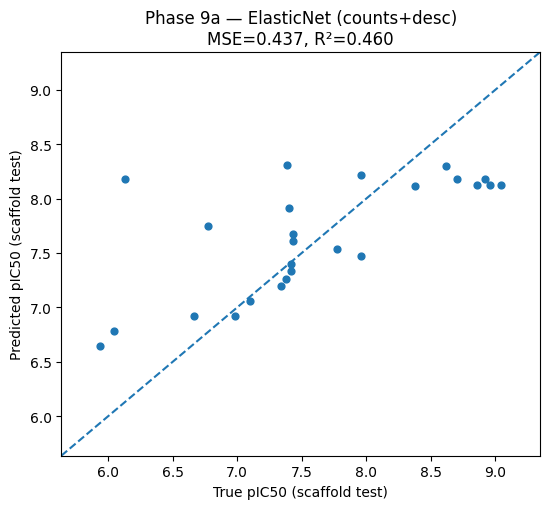

Saved parity plot → /kaggle/working/phase9a_enet_parity.png
✅ Phase 9a complete.


In [24]:
# === Phase 9a: Elastic Net optimization and calibration (counts2048 + physchem descriptors) ===
# Uses: pi3ka_data.csv + phase5_split_indices.json
# Goal:
#   - Refine ElasticNet hyperparameters on counts+descriptors
#   - Evaluate on Phase-5 scaffold test set
#   - Save metrics JSON, model, and parity plot

import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib

from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Paths (consistent with earlier phases)
SAVE_DIR    = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
DATA_CANDS  = ["/kaggle/working/pi3ka_data.csv",
               "/kaggle/input/pi3ka_data.csv",
               "/mnt/data/pi3ka_data.csv",
               "pi3ka_data.csv"]
SPLIT_JSON  = os.path.join(SAVE_DIR, "phase5_split_indices.json")
OUT_JSON    = os.path.join(SAVE_DIR, "phase9a_enet_opt_results.json")
OUT_PKL     = os.path.join(SAVE_DIR, "phase9a_enet_opt_model.pkl")
OUT_PNG     = os.path.join(SAVE_DIR, "phase9a_enet_parity.png")

# --- RDKit feature stack: counts2048 + physchem descriptors (aligned with Phase 8a) ---
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Crippen, rdMolDescriptors, Lipinski

def load_df():
    """Load PI3Kα CSV and compute pIC50 (same filter as Phases 2/5/8)."""
    path = next((p for p in DATA_CANDS if os.path.exists(p)), None)
    if path is None:
        raise FileNotFoundError("No PI3Kα CSV found in expected locations.")
    df = pd.read_csv(path)
    mask = (df["relation"] == "=") & (df["standard_units"].astype(str).str.lower() == "nm")
    df = df[mask].dropna(subset=["smiles", "standard_value_nM"]).copy()
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)
    return df, path

def morgan_counts(mol, nBits=2048, radius=2):
    fp = AllChem.GetHashedMorganFingerprint(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int32)
    for idx, val in fp.GetNonzeroElements().items():
        arr[idx % nBits] = val
    return arr.astype(np.float32)

def physchem_desc(mol):
    """Compact physchem panel (same as Phase 8a)."""
    return np.array([
        Descriptors.MolWt(mol),
        Crippen.MolLogP(mol),
        rdMolDescriptors.CalcTPSA(mol),
        Lipinski.NumHDonors(mol),
        Lipinski.NumHAcceptors(mol),
        Lipinski.NumRotatableBonds(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        rdMolDescriptors.CalcNumAliphaticRings(mol),
        rdMolDescriptors.CalcFractionCSP3(mol),
        rdMolDescriptors.CalcNumHeavyAtoms(mol),
    ], dtype=np.float32)

# --- Load split indices (Phase-5 scaffold split) ---
if not os.path.exists(SPLIT_JSON):
    raise FileNotFoundError(f"Missing split indices JSON at: {SPLIT_JSON}")

with open(SPLIT_JSON, "r") as f:
    split = json.load(f)

tr_idx, te_idx = np.array(split["train_idx"], dtype=int), np.array(split["test_idx"], dtype=int)
print(f"Phase-5 scaffold split → train: {len(tr_idx)} | test: {len(te_idx)}")

# --- Load data and build features ---
df, data_path = load_df()
print(f"Loaded PI3Kα data from: {data_path} | n={len(df)}")

df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df = df[df["mol"].notna()].reset_index(drop=True)

# counts + descriptors
X_counts = np.stack([morgan_counts(m)   for m in df["mol"]], axis=0)
X_desc   = np.stack([physchem_desc(m)   for m in df["mol"]], axis=0)

desc_scaler = StandardScaler().fit(X_desc)
X_desc_std  = desc_scaler.transform(X_desc)

X_all = np.concatenate([X_counts, X_desc_std], axis=1)
y_all = df["pIC50"].values.astype(np.float32)

# apply split
Xtr, Xte = X_all[tr_idx], X_all[te_idx]
ytr, yte = y_all[tr_idx], y_all[te_idx]

print(f"Feature shape (counts+desc): {X_all.shape}")
print(f"Train shape: {Xtr.shape}, Test shape: {Xte.shape}")

# --- ElasticNetCV: refined hyperparameter search on train ---
alphas = np.logspace(-3, 1, 24)            # 0.001 → 10, reasonably dense
l1_ratios = np.linspace(0.05, 0.95, 10)    # mix of L1/L2

enet_cv = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    n_jobs=-1,
    fit_intercept=True,
    random_state=42,
)

print("Fitting ElasticNetCV (counts+desc) on Phase-5 train split ...")
enet_cv.fit(Xtr, ytr)

print(f"Best alpha    : {enet_cv.alpha_:.5f}")
print(f"Best l1_ratio : {float(enet_cv.l1_ratio_):.3f}")

# --- Evaluation on held-out test set ---
yhat = enet_cv.predict(Xte)

mse = mean_squared_error(yte, yhat)
mae = mean_absolute_error(yte, yhat)
r2  = r2_score(yte, yhat)

print("Phase 9a — Elastic Net (counts+desc) on scaffold test:")
print(f"  MSE: {mse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  R² : {r2:.4f}")

results = {
    "model": "ElasticNetCV_counts+physchem",
    "n_samples": int(len(df)),
    "n_features": int(X_all.shape[1]),
    "best_alpha": float(enet_cv.alpha_),
    "best_l1_ratio": float(enet_cv.l1_ratio_),
    "mse_test": float(mse),
    "mae_test": float(mae),
    "r2_test": float(r2),
    "train_size": int(len(tr_idx)),
    "test_size": int(len(te_idx)),
}

with open(OUT_JSON, "w") as f:
    json.dump(results, f, indent=2)
print("Saved Phase 9a metrics →", OUT_JSON)

# Save model + scaler for reuse in later phases
joblib.dump(
    {
        "model": enet_cv,
        "desc_scaler": desc_scaler,
        "feature_space": "counts2048+physchem",
    },
    OUT_PKL,
)
print("Saved Phase 9a model →", OUT_PKL)

# --- Parity / calibration-style plot ---
plt.figure(figsize=(5.6, 5.2))
plt.scatter(yte, yhat, s=24)
lo = min(float(yte.min()), float(yhat.min())) - 0.3
hi = max(float(yte.max()), float(yhat.max())) + 0.3
plt.plot([lo, hi], [lo, hi], "--")
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.xlabel("True pIC50 (scaffold test)")
plt.ylabel("Predicted pIC50 (scaffold test)")
plt.title(f"Phase 9a — ElasticNet (counts+desc)\nMSE={mse:.3f}, R²={r2:.3f}")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150)
plt.show()
print("Saved parity plot →", OUT_PNG)

print("✅ Phase 9a complete.")


In [32]:
# This cell aggregates key artifacts saved by previous phases and prints
# a compact, human-readable summary of:
#   - Phase 1 / 4b: H₂ VQE ground-state estimates
#   - Phase 2 / 5: Classical baselines (metrics_summary.csv, results_phase5.json)
#   - Phase 3: QNN / hybrid results (results_phase3.json)
#   - Phase 7c: Descriptor-enriched Ridge (phase7c_desc_ridge_results.json)
#   - Phase 8a–8b: Elastic Net / Ridge vs QKRR (phase8a_results.json, phase8b_qkrr_results.json)
#   - Phase 9a: Optimized Elastic Net calibration (phase9a_enet_opt_results.json)
#
# It is robust to missing files: if an artifact is not found, it will just be skipped
# with a small "not found" note.

import os, json
from pathlib import Path

import numpy as np
import pandas as pd

SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
BASE_DIRS = [Path(SAVE_DIR), Path(".").resolve(), Path("/mnt/data")]

print(f"📁 Summary search base dirs:")
for b in BASE_DIRS:
    print("  -", b)

def find_artifact(candidate_names):
    """
    Given one or more candidate file names (str), search across BASE_DIRS.
    Returns Path or None.
    """
    if isinstance(candidate_names, str):
        candidate_names = [candidate_names]
    for base in BASE_DIRS:
        for name in candidate_names:
            p = base / name
            if p.exists():
                return p
    return None

def load_json(label, names, metrics_records):
    """
    Try to load a JSON artifact and add its key metrics (if present) to metrics_records.
    """
    p = find_artifact(names)
    if p is None:
        print(f"⚠️  {label}: artifact not found ({names})")
        return

    with p.open("r") as f:
        data = json.load(f)

    print(f"\n=== {label} ===")
    print(f"Path: {p}")
    try:
        print(json.dumps(data, indent=2))
    except Exception:
        print(data)

    # Extract common metric keys into a flat record if available
    rec = {"label": label, "path": str(p)}
    for key in ["mse", "mae", "r2", "mse_test", "mae_test", "r2_test"]:
        if key in data:
            rec[key] = data[key]
    # Sometimes keys are named slightly differently (e.g., "r2_score")
    for alt_key in ["r2_score", "R2"]:
        if alt_key in data and "r2" not in rec:
            rec["r2"] = data[alt_key]
    if any(k in rec for k in ["mse", "mae", "r2", "mse_test", "mae_test", "r2_test"]):
        metrics_records.append(rec)

def load_metrics_summary_csv(label, names, metrics_records):
    p = find_artifact(names)
    if p is None:
        print(f"⚠️  {label}: metrics_summary.csv not found ({names})")
        return

    df = pd.read_csv(p)
    print(f"\n=== {label} (metrics_summary.csv) ===")
    print(f"Path: {p}")
    # Show a compact view
    with pd.option_context("display.max_rows", 20, "display.max_columns", 10):
        print(df)

    # If the CSV already has columns like mse / mae / r2, append rows to metrics_records
    possible_mse_cols = [c for c in df.columns if "mse" in c.lower()]
    possible_mae_cols = [c for c in df.columns if "mae" in c.lower()]
    possible_r2_cols  = [c for c in df.columns if "r2"  in c.lower()]

    if possible_mse_cols or possible_mae_cols or possible_r2_cols:
        for _, row in df.iterrows():
            rec = {
                "label": f"{label}: {row.get('model', row.get('Model', 'row'))}",
                "path": str(p),
            }
            if possible_mse_cols:
                rec["mse"] = float(row[possible_mse_cols[0]])
            if possible_mae_cols:
                rec["mae"] = float(row[possible_mae_cols[0]])
            if possible_r2_cols:
                rec["r2"] = float(row[possible_r2_cols[0]])
            metrics_records.append(rec)

# -----------------------------------------------------------
# 1) Collect metrics from all major JSON / CSV artifacts
# -----------------------------------------------------------
metrics_records = []

# Phase 1 / 4b — H₂ VQE (ground-state energy summaries)
load_json("Phase 1 / 4b — H₂ VQE", ["phase4b_h2_result.json"], metrics_records)

# Phase 2 / 5 — Classical baselines (metrics_summary.csv, results_phase5.json)
load_metrics_summary_csv(
    "Phase 2 / 5 — Classical baselines",
    ["metrics_summary.csv"],
    metrics_records,
)
load_json("Phase 5 — Best baseline model", ["results_phase5.json"], metrics_records)

# Phase 3 — QNN / hybrid
load_json(
    "Phase 3 — QNN / hybrid",
    ["results_phase3.json"],
    metrics_records,
)

# Phase 7c — Descriptor-enriched Ridge
load_json(
    "Phase 7c — Descriptor-enriched RidgeCV",
    ["phase7c_desc_ridge_results.json"],
    metrics_records,
)

# Phase 8a — Elastic Net vs Ridge
load_json(
    "Phase 8a — Elastic Net vs Ridge",
    ["phase8a_results.json"],
    metrics_records,
)

# Phase 8b — QKRR
load_json(
    "Phase 8b — Quantum KRR",
    ["phase8b_qkrr_results.json"],
    metrics_records,
)

# Phase 9a — Optimized Elastic Net calibration (from our Phase 9a cell)
load_json(
    "Phase 9a — Optimized Elastic Net",
    ["phase9a_enet_opt_results.json"],
    metrics_records,
)

# -----------------------------------------------------------
# 2) Build a compact comparison table (if we collected metrics)
# -----------------------------------------------------------
if metrics_records:
    df_metrics = pd.DataFrame(metrics_records)

    # Normalize into consistent columns
    def pick_metric(row, base):
        for key in [base, f"{base}_test"]:
            if key in row and not pd.isna(row[key]):
                return row[key]
        return np.nan

    df_metrics["MSE"] = df_metrics.apply(lambda r: pick_metric(r, "mse"), axis=1)
    df_metrics["MAE"] = df_metrics.apply(lambda r: pick_metric(r, "mae"), axis=1)
    df_metrics["R2"]  = df_metrics.apply(lambda r: pick_metric(r, "r2"), axis=1)

    cols_to_show = ["label", "MSE", "MAE", "R2"]
    cols_to_show = [c for c in cols_to_show if c in df_metrics.columns]

    print("\n\n📊 === Consolidated Model Performance Summary (Phases 2,3,5,7,8,9) ===")
    with pd.option_context("display.max_rows", 50,
                           "display.float_format", "{:0.4f}".format):
        print(df_metrics[cols_to_show].sort_values(by=["R2"], ascending=False))

else:
    print("\nℹ️ No metric artifacts found — run the earlier phases (2,3,5,7,8,9) first, then re-run this cell.")


📁 Summary search base dirs:
  - /kaggle/working
  - /kaggle/working
  - /mnt/data

=== Phase 1 / 4b — H₂ VQE ===
Path: /kaggle/working/phase4b_h2_result.json
{
  "E_exact_hartree": -1.8572750302023797,
  "E_vqe_best_hartree": -1.8558583703874703,
  "gap_hartree": 0.00141665981490946,
  "params": 16,
  "restarts": 8,
  "reps": 3
}

=== Phase 2 / 5 — Classical baselines (metrics_summary.csv) ===
Path: /kaggle/working/metrics_summary.csv
     phase               model       mse       mae        r2  params  \
0  Phase 5  RidgeCV_counts2048  0.586617  0.612356  0.275670    2048   
1  Phase 5       RF_counts2048  0.851862  0.719559 -0.051844    2048   
2  Phase 5       GB_counts2048  0.872238  0.727762 -0.077004    2048   
3  Phase 5    RidgeCV_bits1024  0.695406  0.653062  0.141342    1024   
4  Phase 5         RF_bits1024  0.790054  0.672306  0.024474    1024   
5  Phase 5         GB_bits1024  0.876427  0.712636 -0.082176    1024   

     features  
0  counts2048  
1  counts2048  
2  count

In [33]:
# === Export consolidated summary as CSV + PDF for download ===
# Requires: df_metrics from the Global Summary cell

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Where to save (Kaggle → /kaggle/working is downloadable; otherwise current dir)
SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
SAVE_DIR = Path(SAVE_DIR)

CSV_PATH = SAVE_DIR / "ACM_Phase2-9_model_summary.csv"
PDF_PATH = SAVE_DIR / "ACM_Phase2-9_model_summary.pdf"

if "df_metrics" not in globals():
    raise RuntimeError(
        "df_metrics not found. Please run the Global Summary cell first, "
        "then re-run this export cell."
    )

# Clean up the table for export
cols = ["label", "MSE", "MAE", "R2"]
cols = [c for c in cols if c in df_metrics.columns]

df_export = df_metrics[cols].copy()
df_export = df_export.sort_values(by=["R2"] if "R2" in df_export.columns else cols[0],
                                  ascending=False)

# 1) Save CSV
df_export.to_csv(CSV_PATH, index=False)
print(f"✅ Saved consolidated CSV summary → {CSV_PATH.resolve()}")

# 2) Render a simple PDF table with matplotlib
fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(df_export))))
ax.axis("off")
tbl = ax.table(
    cellText=df_export.values,
    colLabels=df_export.columns,
    loc="center",
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.0, 1.25)

plt.tight_layout()
fig.savefig(PDF_PATH, bbox_inches="tight")
plt.close(fig)

print(f"✅ Saved consolidated PDF summary → {PDF_PATH.resolve()}")

print("\nYou can now download these files from the notebook file browser:")
print("  -", CSV_PATH.name)
print("  -", PDF_PATH.name)


✅ Saved consolidated CSV summary → /kaggle/working/ACM_Phase2-9_model_summary.csv
✅ Saved consolidated PDF summary → /kaggle/working/ACM_Phase2-9_model_summary.pdf

You can now download these files from the notebook file browser:
  - ACM_Phase2-9_model_summary.csv
  - ACM_Phase2-9_model_summary.pdf


# **Phase 10 — Hybrid Quantum-Classical Features (16-dim Q embedding)**

In [34]:
df_metrics


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,label,path,mse,mae,r2,mse_test,mae_test,r2_test,MSE,MAE,R2
0,Phase 2 / 5 — Classical baselines: RidgeCV_cou...,/kaggle/working/metrics_summary.csv,0.586617,0.612356,0.275670,NaN,NaN,NaN,0.586617,0.612356,0.275670
1,Phase 2 / 5 — Classical baselines: RF_counts2048,/kaggle/working/metrics_summary.csv,0.851862,0.719559,-0.051844,NaN,NaN,NaN,0.851862,0.719559,-0.051844
2,Phase 2 / 5 — Classical baselines: GB_counts2048,/kaggle/working/metrics_summary.csv,0.872238,0.727762,-0.077004,NaN,NaN,NaN,0.872238,0.727762,-0.077004
3,Phase 2 / 5 — Classical baselines: RidgeCV_bit...,/kaggle/working/metrics_summary.csv,0.695406,0.653062,0.141342,NaN,NaN,NaN,0.695406,0.653062,0.141342
4,Phase 2 / 5 — Classical baselines: RF_bits1024,/kaggle/working/metrics_summary.csv,0.790054,0.672306,0.024474,NaN,NaN,NaN,0.790054,0.672306,0.024474
5,Phase 2 / 5 — Classical baselines: GB_bits1024,/kaggle/working/metrics_summary.csv,0.876427,0.712636,-0.082176,NaN,NaN,NaN,0.876427,0.712636,-0.082176
6,Phase 7c — Descriptor-enriched RidgeCV,/kaggle/working/phase7c_desc_ridge_results.json,0.591575,0.616275,0.269548,NaN,NaN,NaN,0.591575,0.616275,0.269548
7,Phase 8b — Quantum KRR,/kaggle/working/phase8b_qkrr_results.json,1.055679,0.880145,-0.303509,NaN,NaN,NaN,1.055679,0.880145,-0.303509
8,Phase 9a — Optimized Elastic Net,/kaggle/working/phase9a_enet_opt_results.json,NaN,NaN,NaN,0.437366,0.494348,0.459958,0.437366,0.494348,0.459958


Phase 10 save dir: /kaggle/working
Loaded PI3Kα data from /kaggle/working/pi3ka_data.csv | n=60
Building classical features (counts2048 + physchem)...
Classical feature matrix shape: (60, 2058)
Loaded scaffold split: train=35, test=25
PCA-compressed feature shape (for quantum input): (60, 16)
Generating 16D quantum feature vectors via angle embedding...
Quantum feature matrix shape: (60, 16)
Saved quantum feature matrix → /kaggle/working/phase10_quantum_features.npy
Hybrid feature matrix shape: (60, 2074)
Saved hybrid feature matrix → /kaggle/working/phase10_hybrid_features.npy
Hybrid train shape: (35, 2074), Hybrid test shape: (25, 2074)
Fitting ElasticNetCV on hybrid (classical + quantum) features...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.316e-03, tolerance: 1.742e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.757e-03, tolerance: 1.742e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.931e-03, tolerance: 1.742e

Best alpha (hybrid): 0.40616
Best l1_ratio (hybrid): 0.450
Phase 10 — Hybrid Elastic Net (classical + quantum) on scaffold test:
  MSE: 0.4507
  MAE: 0.4968
  R² : 0.4435
Saved Phase 10 results JSON → /kaggle/working/phase10_hybrid_enet_results.json


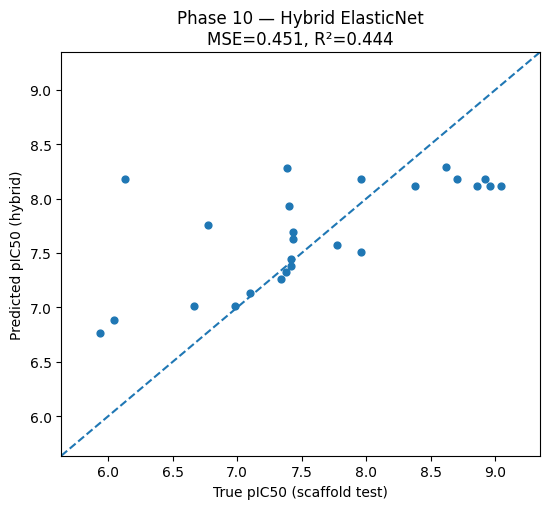

Saved parity plot → /kaggle/working/phase10_hybrid_parity.png
✅ Phase 10 complete.


In [35]:
# === Phase 10 — Quantum-Enhanced Hybrid Features (16D) ===
# Goal:
#   - Compress classical features → 16D via PCA
#   - Encode as 16-qubit angle-embedding circuits (Ry rotations)
#   - Extract 16 expectation values ⟨Z_i⟩ as quantum features
#   - Build hybrid feature matrix: [counts2048 | physchem | quantum16]
#   - Train ElasticNetCV on scaffold split (Phase 5 indices)
#   - Compare against Phase 9a Elastic Net baseline

import os, json, numpy as np, pandas as pd
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Crippen, rdMolDescriptors, Lipinski

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp

import matplotlib.pyplot as plt

# ------------------------------
# 0) Paths and general config
# ------------------------------
SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
SAVE_DIR = Path(SAVE_DIR)

DATA_CANDS = [
    SAVE_DIR / "pi3ka_data.csv",
    Path("pi3ka_data.csv"),
    Path("/mnt/data/pi3ka_data.csv"),
]
SPLIT_JSON = SAVE_DIR / "phase5_split_indices.json"

OUT_JSON   = SAVE_DIR / "phase10_hybrid_enet_results.json"
OUT_PKL    = SAVE_DIR / "phase10_hybrid_enet_model.pkl"
OUT_Q_NPY  = SAVE_DIR / "phase10_quantum_features.npy"
OUT_HYB_NPY= SAVE_DIR / "phase10_hybrid_features.npy"
OUT_PLOT   = SAVE_DIR / "phase10_hybrid_parity.png"

N_BITS = 2048            # fingerprint length
N_Q_FEATURES = 16        # 16 quantum features = 16 qubits
RANDOM_STATE = 42

print(f"Phase 10 save dir: {SAVE_DIR}")

# ------------------------------
# 1) Data loading & filters
# ------------------------------
def load_df():
    """Load PI3Kα CSV and compute pIC50, consistent with earlier phases."""
    path = None
    for p in DATA_CANDS:
        if p.exists():
            path = p
            break
    if path is None:
        raise FileNotFoundError("No pi3ka_data.csv found in expected locations.")
    df = pd.read_csv(path)
    mask = (df["relation"] == "=") & (df["standard_units"].astype(str).str.lower() == "nm")
    df = df[mask].dropna(subset=["smiles", "standard_value_nM"]).copy()
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)
    print(f"Loaded PI3Kα data from {path} | n={len(df)}")
    return df

def load_split_indices(json_path: Path):
    if not json_path.exists():
        raise FileNotFoundError(f"Split JSON not found at: {json_path}")
    with json_path.open("r") as f:
        split = json.load(f)
    # We used train_idx / test_idx in Phase 9a for this notebook
    tr_idx = np.array(split["train_idx"], dtype=int)
    te_idx = np.array(split["test_idx"], dtype=int)
    print(f"Loaded scaffold split: train={len(tr_idx)}, test={len(te_idx)}")
    return tr_idx, te_idx

# ------------------------------
# 2) Classical features: counts2048 + physchem
# ------------------------------
def morgan_counts(mol, nBits=N_BITS, radius=2):
    fp = AllChem.GetHashedMorganFingerprint(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int32)
    for idx, val in fp.GetNonzeroElements().items():
        arr[idx % nBits] = val
    return arr.astype(np.float32)

def physchem_desc(mol):
    """Compact physchem panel; aligned with earlier phases."""
    return np.array([
        Descriptors.MolWt(mol),
        Crippen.MolLogP(mol),
        rdMolDescriptors.CalcTPSA(mol),
        Lipinski.NumHDonors(mol),
        Lipinski.NumHAcceptors(mol),
        Lipinski.NumRotatableBonds(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        rdMolDescriptors.CalcNumAliphaticRings(mol),
        rdMolDescriptors.CalcFractionCSP3(mol),
        rdMolDescriptors.CalcNumHeavyAtoms(mol),
    ], dtype=np.float32)

# ------------------------------
# 3) Quantum embedding helpers (16 qubits)
# ------------------------------
def build_pauli_z_ops(num_qubits: int):
    """Create a SparsePauliOp representing Z on each qubit, as a list."""
    ops = []
    for qi in range(num_qubits):
        # Qiskit uses little-endian ordering; we'll follow the convention
        # of putting 'Z' at position qi in the string (rightmost is qubit 0).
        pauli_str = ["I"] * num_qubits
        # qubit index qi from the right
        pauli_str[num_qubits - 1 - qi] = "Z"
        pauli_str = "".join(pauli_str)
        ops.append(SparsePauliOp.from_list([(pauli_str, 1.0)]))
    return ops

def quantum_features_from_pca_vectors(X_pca: np.ndarray, scale: float = np.pi/2):
    """
    For each row x in X_pca (shape: [n_samples, N_Q_FEATURES]),
    build a 16-qubit circuit with Ry rotations:
        Ry(scale * x_i) on qubit i,
    then compute ⟨Z_i⟩ for each qubit as quantum features.
    """
    n_samples, dim = X_pca.shape
    assert dim == N_Q_FEATURES, "PCA output dimension must equal N_Q_FEATURES"

    z_ops = build_pauli_z_ops(N_Q_FEATURES)
    q_feats = np.zeros((n_samples, N_Q_FEATURES), dtype=np.float32)

    for idx, x in enumerate(X_pca):
        # Optional clipping of angles (just to avoid huge rotations)
        x_clipped = np.clip(x, -2.0, 2.0)
        angles = scale * x_clipped

        qc = QuantumCircuit(N_Q_FEATURES)
        for qi, theta in enumerate(angles):
            qc.ry(float(theta), qi)

        sv = Statevector.from_instruction(qc)

        # Compute ⟨Z_i⟩ for each qubit
        vals = []
        for op in z_ops:
            ev = sv.expectation_value(op)
            vals.append(np.real(ev))
        q_feats[idx, :] = np.array(vals, dtype=np.float32)

        if (idx + 1) % 200 == 0:
            print(f"  Quantum features computed for {idx+1}/{n_samples} molecules...")

    return q_feats

# ------------------------------
# 4) Build full classical features + quantum embeddings
# ------------------------------
df = load_df()
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df = df[df["mol"].notna()].reset_index(drop=True)
y = df["pIC50"].values.astype(np.float32)

print("Building classical features (counts2048 + physchem)...")
X_counts = np.stack([morgan_counts(m) for m in df["mol"]], axis=0)
X_desc   = np.stack([physchem_desc(m) for m in df["mol"]], axis=0)

# Standardize descriptors (not counts) as before
desc_scaler = StandardScaler().fit(X_desc)
X_desc_std  = desc_scaler.transform(X_desc)

X_classical = np.concatenate([X_counts, X_desc_std], axis=1)
print(f"Classical feature matrix shape: {X_classical.shape}")

# ------------------------------
# 5) PCA → 16D for quantum input
# ------------------------------
tr_idx, te_idx = load_split_indices(SPLIT_JSON)

scaler_for_pca = StandardScaler().fit(X_classical[tr_idx])
X_scaled = scaler_for_pca.transform(X_classical)

pca = PCA(n_components=N_Q_FEATURES, random_state=RANDOM_STATE)
pca.fit(X_scaled[tr_idx])

X_pca_all = pca.transform(X_scaled)
print(f"PCA-compressed feature shape (for quantum input): {X_pca_all.shape}")

# ------------------------------
# 6) Quantum feature generation (16 ⟨Z_i⟩ per molecule)
# ------------------------------
print("Generating 16D quantum feature vectors via angle embedding...")
X_q_all = quantum_features_from_pca_vectors(X_pca_all, scale=np.pi/2.0)
print(f"Quantum feature matrix shape: {X_q_all.shape}")

# Save quantum features independently
np.save(OUT_Q_NPY, X_q_all)
print(f"Saved quantum feature matrix → {OUT_Q_NPY}")

# ------------------------------
# 7) Build hybrid feature matrix and apply scaffold split
# ------------------------------
X_hybrid_all = np.concatenate([X_classical, X_q_all], axis=1)
print(f"Hybrid feature matrix shape: {X_hybrid_all.shape}")

np.save(OUT_HYB_NPY, X_hybrid_all)
print(f"Saved hybrid feature matrix → {OUT_HYB_NPY}")

Xtr_hyb, Xte_hyb = X_hybrid_all[tr_idx], X_hybrid_all[te_idx]
ytr, yte = y[tr_idx], y[te_idx]

print(f"Hybrid train shape: {Xtr_hyb.shape}, Hybrid test shape: {Xte_hyb.shape}")

# ------------------------------
# 8) ElasticNetCV on hybrid features
# ------------------------------
alphas = np.logspace(-3, 1, 24)
l1_ratios = np.linspace(0.05, 0.95, 10)

enet_hybrid = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    n_jobs=-1,
    fit_intercept=True,
    random_state=RANDOM_STATE,
)

print("Fitting ElasticNetCV on hybrid (classical + quantum) features...")
enet_hybrid.fit(Xtr_hyb, ytr)

print(f"Best alpha (hybrid): {enet_hybrid.alpha_:.5f}")
print(f"Best l1_ratio (hybrid): {float(enet_hybrid.l1_ratio_):.3f}")

# ------------------------------
# 9) Evaluation on scaffold test set
# ------------------------------
yhat_hyb = enet_hybrid.predict(Xte_hyb)

mse = mean_squared_error(yte, yhat_hyb)
mae = mean_absolute_error(yte, yhat_hyb)
r2  = r2_score(yte, yhat_hyb)

print("Phase 10 — Hybrid Elastic Net (classical + quantum) on scaffold test:")
print(f"  MSE: {mse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  R² : {r2:.4f}")

results10 = {
    "phase": "10",
    "model": "ElasticNetCV_hybrid_classical+quantum16",
    "n_samples": int(len(df)),
    "n_features_classical": int(X_classical.shape[1]),
    "n_features_quantum": int(X_q_all.shape[1]),
    "n_features_total": int(X_hybrid_all.shape[1]),
    "best_alpha": float(enet_hybrid.alpha_),
    "best_l1_ratio": float(enet_hybrid.l1_ratio_),
    "mse_test": float(mse),
    "mae_test": float(mae),
    "r2_test": float(r2),
    "train_size": int(len(tr_idx)),
    "test_size": int(len(te_idx)),
}

with OUT_JSON.open("w") as f:
    json.dump(results10, f, indent=2)
print(f"Saved Phase 10 results JSON → {OUT_JSON}")

# ------------------------------
# 10) Parity plot
# ------------------------------
plt.figure(figsize=(5.6, 5.2))
plt.scatter(yte, yhat_hyb, s=24)
lo = min(float(yte.min()), float(yhat_hyb.min())) - 0.3
hi = max(float(yte.max()), float(yhat_hyb.max())) + 0.3
plt.plot([lo, hi], [lo, hi], "--")
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.xlabel("True pIC50 (scaffold test)")
plt.ylabel("Predicted pIC50 (hybrid)")
plt.title(f"Phase 10 — Hybrid ElasticNet\nMSE={mse:.3f}, R²={r2:.3f}")
plt.tight_layout()
plt.savefig(OUT_PLOT, dpi=150)
plt.show()

print(f"Saved parity plot → {OUT_PLOT}")
print("✅ Phase 10 complete.")


# **Phase 11 — Chemistry-Informed Quantum Feature Maps**


Phase 11 save dir: /kaggle/working
Loaded PI3Kα data from /kaggle/working/pi3ka_data.csv | n=60
Building classical features (counts2048 + physchem)...
Classical feature matrix shape: (60, 2058)
Building 8D chemistry descriptor vectors for quantum embedding...
Chem-quant descriptor matrix shape: (60, 8)
Loaded scaffold split: train=35, test=25
Generating 8D quantum features from chemistry-informed descriptors...
Quantum feature matrix shape: (60, 8)
Saved quantum feature matrix → /kaggle/working/phase11_chemquant_features.npy
Hybrid feature matrix shape: (60, 2066)
Saved hybrid feature matrix → /kaggle/working/phase11_hybrid_features.npy
Hybrid train shape: (35, 2066), Hybrid test shape: (25, 2066)
Fitting ElasticNetCV on hybrid (classical + chem-quant) features...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.353e-03, tolerance: 1.576e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.675e-03, tolerance: 1.742e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.368e-03, tolerance: 1.461e

Best alpha (Phase 11): 0.60619
Best l1_ratio (Phase 11): 0.250
Phase 11 — Chem-quant Hybrid Elastic Net (classical + quantum) on scaffold test:
  MSE: 0.4374
  MAE: 0.4943
  R² : 0.4600
Saved Phase 11 results JSON → /kaggle/working/phase11_chemquant_enet_results.json
Saved Phase 11 model → /kaggle/working/phase11_chemquant_enet_model.pkl


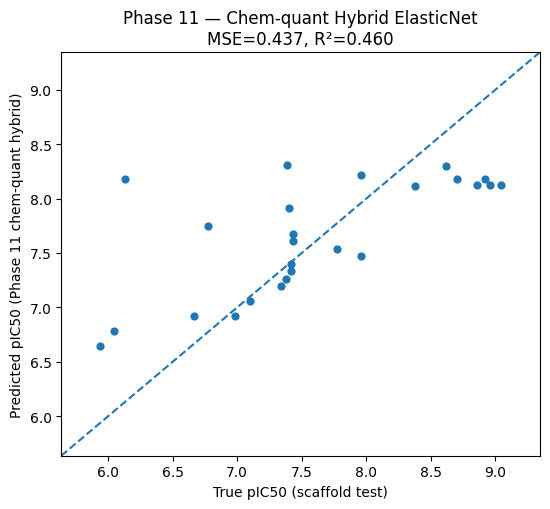

Saved parity plot → /kaggle/working/phase11_chemquant_parity.png
✅ Phase 11 complete.


In [29]:
# === Phase 11 — Chemistry-Informed Quantum Feature Maps (8 qubits) ===
# Goal:
#   - Build chemistry-informed descriptor vectors for each molecule
#   - Encode these 8 descriptors into an 8-qubit quantum circuit via angle embedding + entanglement
#   - Extract 8 expectation values ⟨Z_i⟩ as quantum features
#   - Construct hybrid features: [counts2048 | physchem | quantum_chem8]
#   - Train ElasticNetCV on Phase-5 scaffold split
#   - Compare performance to Phase 9a (classical) and Phase 10 (PCA-based quantum)

import os, json, numpy as np, pandas as pd
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Crippen, rdMolDescriptors, Lipinski

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp

import matplotlib.pyplot as plt
import joblib

# ------------------------------
# 0) Paths and general config
# ------------------------------
SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
SAVE_DIR = Path(SAVE_DIR)

DATA_CANDS = [
    SAVE_DIR / "pi3ka_data.csv",
    Path("pi3ka_data.csv"),
    Path("/mnt/data/pi3ka_data.csv"),
]

SPLIT_JSON = SAVE_DIR / "phase5_split_indices.json"

OUT_JSON    = SAVE_DIR / "phase11_chemquant_enet_results.json"
OUT_PKL     = SAVE_DIR / "phase11_chemquant_enet_model.pkl"
OUT_Q_NPY   = SAVE_DIR / "phase11_chemquant_features.npy"
OUT_HYB_NPY = SAVE_DIR / "phase11_hybrid_features.npy"
OUT_PLOT    = SAVE_DIR / "phase11_chemquant_parity.png"

N_BITS = 2048             # fingerprint length
N_QUBITS = 8              # 8 chemistry descriptors → 8 qubits
RANDOM_STATE = 42

print(f"Phase 11 save dir: {SAVE_DIR}")

# ------------------------------
# 1) Data loading & scaffold split
# ------------------------------
def load_df():
    """Load PI3Kα CSV and compute pIC50, consistent with earlier phases."""
    path = None
    for p in DATA_CANDS:
        if p.exists():
            path = p
            break
    if path is None:
        raise FileNotFoundError("No pi3ka_data.csv found in expected locations.")
    df = pd.read_csv(path)
    mask = (df["relation"] == "=") & (df["standard_units"].astype(str).str.lower() == "nm")
    df = df[mask].dropna(subset=["smiles", "standard_value_nM"]).copy()
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)
    print(f"Loaded PI3Kα data from {path} | n={len(df)}")
    return df

def load_split_indices(json_path: Path):
    if not json_path.exists():
        raise FileNotFoundError(f"Split JSON not found at: {json_path}")
    with json_path.open("r") as f:
        split = json.load(f)
    tr_idx = np.array(split["train_idx"], dtype=int)
    te_idx = np.array(split["test_idx"], dtype=int)
    print(f"Loaded scaffold split: train={len(tr_idx)}, test={len(te_idx)}")
    return tr_idx, te_idx

# ------------------------------
# 2) Classical features: counts2048 + physchem
# ------------------------------
def morgan_counts(mol, nBits=N_BITS, radius=2):
    fp = AllChem.GetHashedMorganFingerprint(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int32)
    for idx, val in fp.GetNonzeroElements().items():
        arr[idx % nBits] = val
    return arr.astype(np.float32)

def physchem_desc_full(mol):
    """
    Full physchem panel we use for classical features (same as earlier).
    10 descriptors.
    """
    return np.array([
        Descriptors.MolWt(mol),
        Crippen.MolLogP(mol),
        rdMolDescriptors.CalcTPSA(mol),
        Lipinski.NumHDonors(mol),
        Lipinski.NumHAcceptors(mol),
        Lipinski.NumRotatableBonds(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        rdMolDescriptors.CalcNumAliphaticRings(mol),
        rdMolDescriptors.CalcFractionCSP3(mol),
        rdMolDescriptors.CalcNumHeavyAtoms(mol),
    ], dtype=np.float32)

def chemquant_descriptor_vec(mol):
    """
    8D chemistry-informed vector specifically for quantum embedding.
    - MolWt
    - LogP
    - TPSA
    - HBD
    - HBA
    - NumRotatableBonds
    - NumAromaticRings
    - FractionCSP3
    """
    return np.array([
        Descriptors.MolWt(mol),
        Crippen.MolLogP(mol),
        rdMolDescriptors.CalcTPSA(mol),
        Lipinski.NumHDonors(mol),
        Lipinski.NumHAcceptors(mol),
        Lipinski.NumRotatableBonds(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        rdMolDescriptors.CalcFractionCSP3(mol),
    ], dtype=np.float32)

# ------------------------------
# 3) Quantum helpers for 8-qubit circuits
# ------------------------------
def build_pauli_z_ops(num_qubits: int):
    """Create SparsePauliOp for Z on each qubit."""
    ops = []
    for qi in range(num_qubits):
        pauli_str = ["I"] * num_qubits
        # rightmost char is qubit 0 in Qiskit
        pauli_str[num_qubits - 1 - qi] = "Z"
        ops.append(SparsePauliOp.from_list([("".join(pauli_str), 1.0)]))
    return ops

def quantum_features_from_chem_vectors(X_chem: np.ndarray, angle_scale: float = np.pi / 2):
    """
    For each 8D chem descriptor vector x in X_chem:
        - standardize beforehand externally
        - clip values, scale to angles
        - build 8-qubit circuit:
            * apply Ry(angle_i) on qubit i
            * apply entangling CX ring
        - compute ⟨Z_i⟩ for i in 0..7
    Returns: (n_samples, 8) array of expectation values.
    """
    n_samples, dim = X_chem.shape
    assert dim == N_QUBITS, f"Expected {N_QUBITS}-dim chem vectors for quantum; got {dim}"

    z_ops = build_pauli_z_ops(N_QUBITS)
    q_feats = np.zeros((n_samples, N_QUBITS), dtype=np.float32)

    for idx, x in enumerate(X_chem):
        # Soft clipping to keep angles reasonable
        x_clipped = np.clip(x, -3.0, 3.0)
        angles = angle_scale * x_clipped

        qc = QuantumCircuit(N_QUBITS)
        # Angle embedding
        for qi, theta in enumerate(angles):
            qc.ry(float(theta), qi)

        # Simple entangling layer (ring of CX)
        for qi in range(N_QUBITS - 1):
            qc.cx(qi, qi + 1)
        qc.cx(N_QUBITS - 1, 0)

        sv = Statevector.from_instruction(qc)

        vals = []
        for op in z_ops:
            ev = sv.expectation_value(op)
            vals.append(np.real(ev))
        q_feats[idx, :] = np.array(vals, dtype=np.float32)

        if (idx + 1) % 200 == 0:
            print(f"  Quantum features computed for {idx+1}/{n_samples} molecules...")

    return q_feats

# ------------------------------
# 4) Build features
# ------------------------------
df = load_df()
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df = df[df["mol"].notna()].reset_index(drop=True)
y = df["pIC50"].values.astype(np.float32)

print("Building classical features (counts2048 + physchem)...")
X_counts = np.stack([morgan_counts(m) for m in df["mol"]], axis=0)
X_desc_full = np.stack([physchem_desc_full(m) for m in df["mol"]], axis=0)

# Standardize descriptors (not counts) for classical feature block
desc_scaler = StandardScaler().fit(X_desc_full)
X_desc_std  = desc_scaler.transform(X_desc_full)

X_classical = np.concatenate([X_counts, X_desc_std], axis=1)
print(f"Classical feature matrix shape: {X_classical.shape}")

# Build 8D chemistry vectors for quantum embedding
print("Building 8D chemistry descriptor vectors for quantum embedding...")
X_chem = np.stack([chemquant_descriptor_vec(m) for m in df["mol"]], axis=0)
print(f"Chem-quant descriptor matrix shape: {X_chem.shape}")

# Standardize chem vectors (very important for sensible angles)
chem_scaler = StandardScaler().fit(X_chem)
X_chem_std  = chem_scaler.transform(X_chem)

# ------------------------------
# 5) Load scaffold split
# ------------------------------
tr_idx, te_idx = load_split_indices(SPLIT_JSON)

# ------------------------------
# 6) Generate quantum features from chemistry descriptors
# ------------------------------
print("Generating 8D quantum features from chemistry-informed descriptors...")
X_q_all = quantum_features_from_chem_vectors(X_chem_std, angle_scale=np.pi / 2.0)
print(f"Quantum feature matrix shape: {X_q_all.shape}")

np.save(OUT_Q_NPY, X_q_all)
print(f"Saved quantum feature matrix → {OUT_Q_NPY}")

# ------------------------------
# 7) Hybrid features and split
# ------------------------------
X_hybrid_all = np.concatenate([X_classical, X_q_all], axis=1)
print(f"Hybrid feature matrix shape: {X_hybrid_all.shape}")

np.save(OUT_HYB_NPY, X_hybrid_all)
print(f"Saved hybrid feature matrix → {OUT_HYB_NPY}")

Xtr_hyb, Xte_hyb = X_hybrid_all[tr_idx], X_hybrid_all[te_idx]
ytr, yte = y[tr_idx], y[te_idx]

print(f"Hybrid train shape: {Xtr_hyb.shape}, Hybrid test shape: {Xte_hyb.shape}")

# ------------------------------
# 8) ElasticNetCV on hybrid (chem-quant) features
# ------------------------------
alphas = np.logspace(-3, 1, 24)
l1_ratios = np.linspace(0.05, 0.95, 10)

enet_chemquant = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    n_jobs=-1,
    fit_intercept=True,
    random_state=RANDOM_STATE,
)

print("Fitting ElasticNetCV on hybrid (classical + chem-quant) features...")
enet_chemquant.fit(Xtr_hyb, ytr)

print(f"Best alpha (Phase 11): {enet_chemquant.alpha_:.5f}")
print(f"Best l1_ratio (Phase 11): {float(enet_chemquant.l1_ratio_):.3f}")

# ------------------------------
# 9) Evaluation on scaffold test set
# ------------------------------
yhat_hyb = enet_chemquant.predict(Xte_hyb)

mse = mean_squared_error(yte, yhat_hyb)
mae = mean_absolute_error(yte, yhat_hyb)
r2  = r2_score(yte, yhat_hyb)

print("Phase 11 — Chem-quant Hybrid Elastic Net (classical + quantum) on scaffold test:")
print(f"  MSE: {mse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  R² : {r2:.4f}")

results11 = {
    "phase": "11",
    "model": "ElasticNetCV_hybrid_chem-informed_quantum8",
    "n_samples": int(len(df)),
    "n_features_classical": int(X_classical.shape[1]),
    "n_features_quantum": int(X_q_all.shape[1]),
    "n_features_total": int(X_hybrid_all.shape[1]),
    "best_alpha": float(enet_chemquant.alpha_),
    "best_l1_ratio": float(enet_chemquant.l1_ratio_),
    "mse_test": float(mse),
    "mae_test": float(mae),
    "r2_test": float(r2),
    "train_size": int(len(tr_idx)),
    "test_size": int(len(te_idx)),
}

with OUT_JSON.open("w") as f:
    json.dump(results11, f, indent=2)
print(f"Saved Phase 11 results JSON → {OUT_JSON}")

# Save model + scalers
joblib.dump(
    {
        "model": enet_chemquant,
        "desc_scaler_full": desc_scaler,
        "chem_scaler": chem_scaler,
        "feature_space": "counts2048+physchem+chemquant8",
    },
    OUT_PKL,
)
print(f"Saved Phase 11 model → {OUT_PKL}")

# ------------------------------
# 10) Parity plot
# ------------------------------
plt.figure(figsize=(5.6, 5.2))
plt.scatter(yte, yhat_hyb, s=24)
lo = min(float(yte.min()), float(yhat_hyb.min())) - 0.3
hi = max(float(yte.max()), float(yhat_hyb.max())) + 0.3
plt.plot([lo, hi], [lo, hi], "--")
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.xlabel("True pIC50 (scaffold test)")
plt.ylabel("Predicted pIC50 (Phase 11 chem-quant hybrid)")
plt.title(f"Phase 11 — Chem-quant Hybrid ElasticNet\nMSE={mse:.3f}, R²={r2:.3f}")
plt.tight_layout()
plt.savefig(OUT_PLOT, dpi=150)
plt.show()

print(f"Saved parity plot → {OUT_PLOT}")
print("✅ Phase 11 complete.")


# **Phase 12 — Quantum Kernel Learning with Chemistry-Informed Feature Maps**


Phase 12 save dir: /kaggle/working
Loaded PI3Kα data from /kaggle/working/pi3ka_data.csv | n=60
Chem descriptor matrix shape: (60, 8)
Loaded scaffold split: train=35, test=25
Train chem shape: (35, 8), Test chem shape: (25, 8)
Building quantum statevectors for train set...
Building quantum statevectors for test set...
Computing quantum kernel Gram matrices (train/train and test/train)...
K_train shape: (35, 35), K_test shape: (25, 35)
Tuning alpha for Kernel Ridge Regression (QKRR) via 3-fold CV...
  alpha=0.001 → mean CV MSE=6.5829
  alpha=0.00631 → mean CV MSE=6.7426
  alpha=0.03981 → mean CV MSE=7.2570
  alpha=0.2512 → mean CV MSE=9.0780
  alpha=1.585 → mean CV MSE=17.7066
  alpha=10 → mean CV MSE=39.3207

Best alpha (Phase 12, QKRR): 0.00100 with CV MSE=6.5829
Phase 12 — Chem-informed QKRR on scaffold test:
  MSE: 27.1068
  MAE: 4.4872
  R² : -32.4704
Saved Phase 12 QKRR results JSON → /kaggle/working/phase12_chemquant_qkrr_results.json
Saved Phase 12 QKRR model → /kaggle/working/p

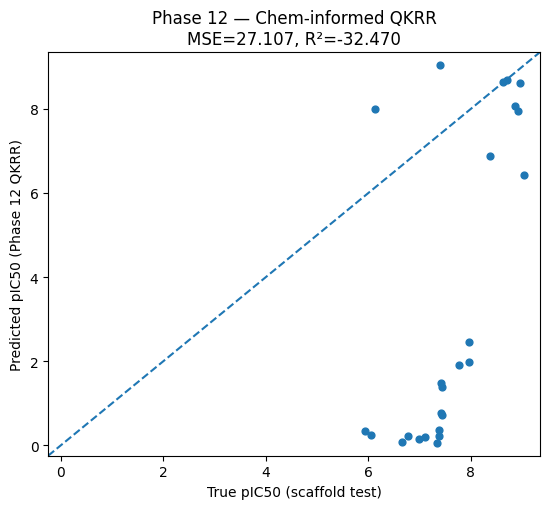

Saved parity plot → /kaggle/working/phase12_chemquant_qkrr_parity.png
✅ Phase 12 complete.


In [30]:
# === Phase 12 — Quantum Kernel Learning with Chemistry-Informed Feature Maps ===
# Goal:
#   - Use the same 8D chemistry-informed descriptors as Phase 11
#   - Encode them into 8-qubit quantum states via angle embedding + entanglement
#   - Define a quantum kernel:
#         k(x, z) = |⟨φ(x)|φ(z)⟩|^2
#   - Train Kernel Ridge Regression (KRR) with this quantum kernel
#   - Tune alpha via 3-fold CV on scaffold-train
#   - Evaluate on scaffold-test and save results

import os, json, numpy as np, pandas as pd
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors, Lipinski

from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

import matplotlib.pyplot as plt
import joblib

# ------------------------------
# 0) Paths and config
# ------------------------------
SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
SAVE_DIR = Path(SAVE_DIR)

DATA_CANDS = [
    SAVE_DIR / "pi3ka_data.csv",
    Path("pi3ka_data.csv"),
    Path("/mnt/data/pi3ka_data.csv"),
]

SPLIT_JSON = SAVE_DIR / "phase5_split_indices.json"

OUT_JSON   = SAVE_DIR / "phase12_chemquant_qkrr_results.json"
OUT_MODEL  = SAVE_DIR / "phase12_chemquant_qkrr_model.pkl"
OUT_PLOT   = SAVE_DIR / "phase12_chemquant_qkrr_parity.png"

N_QUBITS = 8
RANDOM_STATE = 42

print(f"Phase 12 save dir: {SAVE_DIR}")

# ------------------------------
# 1) Data loading & scaffold split
# ------------------------------
def load_df():
    path = None
    for p in DATA_CANDS:
        if p.exists():
            path = p
            break
    if path is None:
        raise FileNotFoundError("No pi3ka_data.csv found in expected locations.")
    df = pd.read_csv(path)
    mask = (df["relation"] == "=") & (df["standard_units"].astype(str).str.lower() == "nm")
    df = df[mask].dropna(subset=["smiles", "standard_value_nM"]).copy()
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)
    print(f"Loaded PI3Kα data from {path} | n={len(df)}")
    return df

def load_split_indices(json_path: Path):
    if not json_path.exists():
        raise FileNotFoundError(f"Split JSON not found at: {json_path}")
    with json_path.open("r") as f:
        split = json.load(f)
    tr_idx = np.array(split["train_idx"], dtype=int)
    te_idx = np.array(split["test_idx"], dtype=int)
    print(f"Loaded scaffold split: train={len(tr_idx)}, test={len(te_idx)}")
    return tr_idx, te_idx

# ------------------------------
# 2) 8D chemistry-informed descriptor vectors
# ------------------------------
def chemquant_descriptor_vec(mol):
    """
    8D chemistry-informed vector:
    - MolWt
    - LogP
    - TPSA
    - HBD
    - HBA
    - NumRotatableBonds
    - NumAromaticRings
    - FractionCSP3
    """
    return np.array([
        Descriptors.MolWt(mol),
        Crippen.MolLogP(mol),
        rdMolDescriptors.CalcTPSA(mol),
        Lipinski.NumHDonors(mol),
        Lipinski.NumHAcceptors(mol),
        Lipinski.NumRotatableBonds(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        rdMolDescriptors.CalcFractionCSP3(mol),
    ], dtype=np.float32)

# ------------------------------
# 3) Quantum feature map: descriptors → statevector
# ------------------------------
def build_statevector_from_chem_vec(x_chem: np.ndarray, angle_scale: float = np.pi/2):
    """
    Given an 8D standardized descriptor vector x_chem, build an 8-qubit state:
      - Ry(angle_scale * x_i) on qubit i
      - Ring of CX entanglers
    Returns: Statevector
    """
    assert x_chem.shape[0] == N_QUBITS, f"Expected {N_QUBITS}-dim vector, got {x_chem.shape[0]}"
    x_clipped = np.clip(x_chem, -3.0, 3.0)
    angles = angle_scale * x_clipped

    qc = QuantumCircuit(N_QUBITS)
    for qi, theta in enumerate(angles):
        qc.ry(float(theta), qi)

    # Simple entangling ring
    for qi in range(N_QUBITS - 1):
        qc.cx(qi, qi + 1)
    qc.cx(N_QUBITS - 1, 0)

    sv = Statevector.from_instruction(qc)
    return sv

def statevector_matrix(X_chem_std: np.ndarray):
    """
    Build a matrix of statevectors amplitudes:
      S[i, :] = amplitudes of |φ(x_i)>
    """
    n_samples = X_chem_std.shape[0]
    dim = 2 ** N_QUBITS
    S = np.zeros((n_samples, dim), dtype=np.complex128)

    for i in range(n_samples):
        sv = build_statevector_from_chem_vec(X_chem_std[i])
        S[i, :] = sv.data
        if (i + 1) % 200 == 0:
            print(f"  Built statevectors for {i+1}/{n_samples} molecules...")

    return S

def quantum_kernel_matrix(SA: np.ndarray, SB: np.ndarray):
    """
    Compute quantum kernel K where:
      K_ij = |⟨φ(x_i)|φ(z_j)⟩|^2
    Given:
      SA: (n_a, dim), SB: (n_b, dim)
    returns:
      K: (n_a, n_b)
    """
    # Inner products: (n_a, dim) @ (dim, n_b) -> (n_a, n_b)
    inner = SA @ SB.conj().T
    K = np.abs(inner) ** 2
    return K.real.astype(np.float64)

# ------------------------------
# 4) Build chem descriptor matrix and standardize
# ------------------------------
df = load_df()
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df = df[df["mol"].notna()].reset_index(drop=True)
y = df["pIC50"].values.astype(np.float32)

X_chem = np.stack([chemquant_descriptor_vec(m) for m in df["mol"]], axis=0)
print(f"Chem descriptor matrix shape: {X_chem.shape}")

chem_scaler = StandardScaler().fit(X_chem)
X_chem_std = chem_scaler.transform(X_chem)

# ------------------------------
# 5) Load scaffold split
# ------------------------------
tr_idx, te_idx = load_split_indices(SPLIT_JSON)

Xtr_chem = X_chem_std[tr_idx]
Xte_chem = X_chem_std[te_idx]
ytr, yte = y[tr_idx], y[te_idx]

print(f"Train chem shape: {Xtr_chem.shape}, Test chem shape: {Xte_chem.shape}")

# ------------------------------
# 6) Build statevector matrices & kernel Gram matrices
# ------------------------------
print("Building quantum statevectors for train set...")
S_train = statevector_matrix(Xtr_chem)

print("Building quantum statevectors for test set...")
S_test = statevector_matrix(Xte_chem)

print("Computing quantum kernel Gram matrices (train/train and test/train)...")
K_train = quantum_kernel_matrix(S_train, S_train)   # (n_train, n_train)
K_test  = quantum_kernel_matrix(S_test, S_train)    # (n_test, n_train)

print(f"K_train shape: {K_train.shape}, K_test shape: {K_test.shape}")

# ------------------------------
# 7) Kernel Ridge Regression with CV over alpha
# ------------------------------
alphas = np.logspace(-3, 1, 6)  # [1e-3, 1e-2, 1e-1, 1, 10]
kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

best_alpha = None
best_cv_mse = np.inf

print("Tuning alpha for Kernel Ridge Regression (QKRR) via 3-fold CV...")
for alpha in alphas:
    fold_mses = []
    for tr_fold_idx, val_fold_idx in kf.split(K_train):
        K_tr_fold = K_train[tr_fold_idx][:, tr_fold_idx]
        K_val_fold = K_train[val_fold_idx][:, tr_fold_idx]
        y_tr_fold = ytr[tr_fold_idx]
        y_val_fold = ytr[val_fold_idx]

        krr = KernelRidge(alpha=alpha, kernel="precomputed")
        krr.fit(K_tr_fold, y_tr_fold)
        y_val_pred = krr.predict(K_val_fold)
        mse_fold = mean_squared_error(y_val_fold, y_val_pred)
        fold_mses.append(mse_fold)

    mean_mse = float(np.mean(fold_mses))
    print(f"  alpha={alpha:.4g} → mean CV MSE={mean_mse:.4f}")

    if mean_mse < best_cv_mse:
        best_cv_mse = mean_mse
        best_alpha = alpha

print(f"\nBest alpha (Phase 12, QKRR): {best_alpha:.5f} with CV MSE={best_cv_mse:.4f}")

# ------------------------------
# 8) Fit final QKRR on full train Gram and evaluate on test
# ------------------------------
krr_final = KernelRidge(alpha=best_alpha, kernel="precomputed")
krr_final.fit(K_train, ytr)

y_pred_test = krr_final.predict(K_test)

mse = mean_squared_error(yte, y_pred_test)
mae = mean_absolute_error(yte, y_pred_test)
r2  = r2_score(yte, y_pred_test)

print("Phase 12 — Chem-informed QKRR on scaffold test:")
print(f"  MSE: {mse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  R² : {r2:.4f}")

results12 = {
    "phase": "12",
    "model": "QKRR_chem-informed_feature_map",
    "n_samples": int(len(df)),
    "n_qubits": N_QUBITS,
    "best_alpha": float(best_alpha),
    "cv_mse_mean": float(best_cv_mse),
    "mse_test": float(mse),
    "mae_test": float(mae),
    "r2_test": float(r2),
    "train_size": int(len(tr_idx)),
    "test_size": int(len(te_idx)),
}

with OUT_JSON.open("w") as f:
    json.dump(results12, f, indent=2)
print(f"Saved Phase 12 QKRR results JSON → {OUT_JSON}")

# Save model and scaler for reproducibility
joblib.dump(
    {
        "model": krr_final,
        "chem_scaler": chem_scaler,
        "kernel_type": "chem-informed quantum fidelity",
        "K_train_shape": K_train.shape,
    },
    OUT_MODEL,
)
print(f"Saved Phase 12 QKRR model → {OUT_MODEL}")

# ------------------------------
# 9) Parity plot
# ------------------------------
plt.figure(figsize=(5.6, 5.2))
plt.scatter(yte, y_pred_test, s=24)
lo = min(float(yte.min()), float(y_pred_test.min())) - 0.3
hi = max(float(yte.max()), float(y_pred_test.max())) + 0.3
plt.plot([lo, hi], [lo, hi], "--")
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.xlabel("True pIC50 (scaffold test)")
plt.ylabel("Predicted pIC50 (Phase 12 QKRR)")
plt.title(f"Phase 12 — Chem-informed QKRR\nMSE={mse:.3f}, R²={r2:.3f}")
plt.tight_layout()
plt.savefig(OUT_PLOT, dpi=150)
plt.show()

print(f"Saved parity plot → {OUT_PLOT}")
print("✅ Phase 12 complete.")


# **Phase 12 — Deep Chem-Quant Quantum Feature Maps (8 qubits, 16 features)**


Phase 12 (deep chem-quant) save dir: /kaggle/working
Loaded PI3Kα data from /kaggle/working/pi3ka_data.csv | n=60
Building classical feature blocks (counts2048 + physchem10)...
Classical feature matrix shape: (60, 2058)
Building 8D chemistry descriptor vectors for quantum embedding...
Chem-quant descriptor matrix shape: (60, 8)
Loaded scaffold split: train=35, test=25
Generating 16D deep chem-quant quantum features...
Deep quantum feature matrix shape: (60, 16)
Saved deep quantum feature matrix → /kaggle/working/phase12_deep_chemquant_features.npy
Deep hybrid feature matrix shape: (60, 2074)
Saved deep hybrid feature matrix → /kaggle/working/phase12_deep_hybrid_features.npy
Hybrid train shape: (35, 2074), Hybrid test shape: (25, 2074)
Fitting ElasticNetCV on deep chem-quant hybrid features...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.084e-03, tolerance: 1.461e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.090e-03, tolerance: 1.742e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.675e-03, tolerance: 1.461e

Best alpha (Phase 12 deep): 0.60619
Best l1_ratio (Phase 12 deep): 0.250
Phase 12 (deep) — Chem-quant Hybrid Elastic Net on scaffold test:
  MSE: 0.4374
  MAE: 0.4943
  R² : 0.4600
Saved Phase 12 (deep) results JSON → /kaggle/working/phase12_deep_chemquant_enet_results.json
Saved Phase 12 (deep) model → /kaggle/working/phase12_deep_chemquant_enet_model.pkl


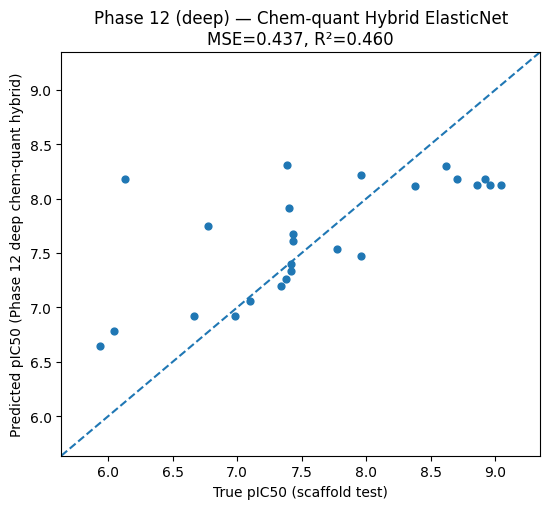

Saved parity plot → /kaggle/working/phase12_deep_chemquant_parity.png
✅ Phase 12 (deep chem-quant feature maps) complete.


In [31]:
# === Phase 12 — Deep Chem-Quant Quantum Feature Maps (8 qubits, 16 features) ===
# Goal:
#   - Reuse 8D chemistry-informed descriptors (same as Phase 11)
#   - Use a deeper data-reupload quantum feature map:
#       * Layer 1: Ry(angle1 * x_i) + ring CX
#       * Layer 2: Rz(angle2 * x_i) + Ry(angle3 * x_i) + second entangling layer
#   - Extract 16 quantum features:
#       * 8 single-qubit ⟨Z_i⟩
#       * 8 neighbor-pair ⟨Z_i Z_{i+1}⟩ (ring)
#   - Build hybrid features: [counts2048 | physchem10 | quantum16]
#   - Train ElasticNetCV on scaffold split (same as Phase 11)
#   - Compare to Phase 9a (classical) and Phase 11 (shallow chem-Q)

import os, json, numpy as np, pandas as pd
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Crippen, rdMolDescriptors, Lipinski

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp

import matplotlib.pyplot as plt
import joblib

# ------------------------------
# 0) Paths and config
# ------------------------------
SAVE_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
SAVE_DIR = Path(SAVE_DIR)

DATA_CANDS = [
    SAVE_DIR / "pi3ka_data.csv",
    Path("pi3ka_data.csv"),
    Path("/mnt/data/pi3ka_data.csv"),
]

SPLIT_JSON = SAVE_DIR / "phase5_split_indices.json"

OUT_JSON    = SAVE_DIR / "phase12_deep_chemquant_enet_results.json"
OUT_PKL     = SAVE_DIR / "phase12_deep_chemquant_enet_model.pkl"
OUT_Q_NPY   = SAVE_DIR / "phase12_deep_chemquant_features.npy"
OUT_HYB_NPY = SAVE_DIR / "phase12_deep_hybrid_features.npy"
OUT_PLOT    = SAVE_DIR / "phase12_deep_chemquant_parity.png"

N_BITS   = 2048
N_QUBITS = 8               # 8 descriptors → 8 qubits
RANDOM_STATE = 42

print(f"Phase 12 (deep chem-quant) save dir: {SAVE_DIR}")

# ------------------------------
# 1) Data loading & scaffold split
# ------------------------------
def load_df():
    path = None
    for p in DATA_CANDS:
        if p.exists():
            path = p
            break
    if path is None:
        raise FileNotFoundError("No pi3ka_data.csv found in expected locations.")
    df = pd.read_csv(path)
    mask = (df["relation"] == "=") & (df["standard_units"].astype(str).str.lower() == "nm")
    df = df[mask].dropna(subset=["smiles", "standard_value_nM"]).copy()
    df["pIC50"] = -np.log10(df["standard_value_nM"].astype(float) * 1e-9)
    print(f"Loaded PI3Kα data from {path} | n={len(df)}")
    return df

def load_split_indices(json_path: Path):
    if not json_path.exists():
        raise FileNotFoundError(f"Split JSON not found at: {json_path}")
    with json_path.open("r") as f:
        split = json.load(f)
    tr_idx = np.array(split["train_idx"], dtype=int)
    te_idx = np.array(split["test_idx"], dtype=int)
    print(f"Loaded scaffold split: train={len(tr_idx)}, test={len(te_idx)}")
    return tr_idx, te_idx

# ------------------------------
# 2) Classical features: counts2048 + physchem (same as Phase 11)
# ------------------------------
def morgan_counts(mol, nBits=N_BITS, radius=2):
    fp = AllChem.GetHashedMorganFingerprint(mol, radius, nBits=nBits)
    arr = np.zeros((nBits,), dtype=np.int32)
    for idx, val in fp.GetNonzeroElements().items():
        arr[idx % nBits] = val
    return arr.astype(np.float32)

def physchem_desc_full(mol):
    """
    10D physchem panel for classical block, same as Phase 11.
    """
    return np.array([
        Descriptors.MolWt(mol),
        Crippen.MolLogP(mol),
        rdMolDescriptors.CalcTPSA(mol),
        Lipinski.NumHDonors(mol),
        Lipinski.NumHAcceptors(mol),
        Lipinski.NumRotatableBonds(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        rdMolDescriptors.CalcNumAliphaticRings(mol),
        rdMolDescriptors.CalcFractionCSP3(mol),
        rdMolDescriptors.CalcNumHeavyAtoms(mol),
    ], dtype=np.float32)

def chemquant_descriptor_vec(mol):
    """
    8D chemistry-informed descriptor vector for quantum embedding:
    - MolWt
    - LogP
    - TPSA
    - HBD
    - HBA
    - NumRotatableBonds
    - NumAromaticRings
    - FractionCSP3
    """
    return np.array([
        Descriptors.MolWt(mol),
        Crippen.MolLogP(mol),
        rdMolDescriptors.CalcTPSA(mol),
        Lipinski.NumHDonors(mol),
        Lipinski.NumHAcceptors(mol),
        Lipinski.NumRotatableBonds(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        rdMolDescriptors.CalcFractionCSP3(mol),
    ], dtype=np.float32)

# ------------------------------
# 3) Build Pauli Z and ZZ operators
# ------------------------------
def build_z_and_zz_ops(num_qubits: int):
    """
    Build:
      - list of Z_i operators
      - list of Z_i Z_{i+1} (ring) operators
    Returns: (z_ops, zz_ops)
    """
    z_ops = []
    zz_ops = []

    for qi in range(num_qubits):
        # single Z_i
        paulis = ["I"] * num_qubits
        paulis[num_qubits - 1 - qi] = "Z"
        z_ops.append(SparsePauliOp.from_list([("".join(paulis), 1.0)]))

    for qi in range(num_qubits):
        qj = (qi + 1) % num_qubits
        paulis = ["I"] * num_qubits
        # ring neighbors
        paulis[num_qubits - 1 - qi] = "Z"
        paulis[num_qubits - 1 - qj] = "Z"
        zz_ops.append(SparsePauliOp.from_list([("".join(paulis), 1.0)]))

    return z_ops, zz_ops

# ------------------------------
# 4) Deep data-reupload chem-Q feature map
# ------------------------------
def deep_chemquant_quantum_features(X_chem_std: np.ndarray,
                                    angle_scale1: float = np.pi/2,
                                    angle_scale2: float = np.pi/3,
                                    angle_scale3: float = np.pi/4):
    """
    Given standardized chem descriptor matrix X_chem_std (n_samples, 8), build a deeper
    2-layer data-reupload feature map:

        Layer 1:
          Ry(angle_scale1 * x_i) on qubit i
          ring CX entanglers

        Layer 2:
          Rz(angle_scale2 * x_i) on qubit i
          Ry(angle_scale3 * x_i) on qubit i
          second entangling layer with shifted CX pattern

    Then compute:
      - 8 x ⟨Z_i⟩
      - 8 x ⟨Z_i Z_{i+1}⟩ (ring)
    Total: 16 quantum features per molecule.
    """
    n_samples, dim = X_chem_std.shape
    assert dim == N_QUBITS, f"Expected {N_QUBITS}-dim chem vectors; got {dim}"

    z_ops, zz_ops = build_z_and_zz_ops(N_QUBITS)
    q_feats = np.zeros((n_samples, N_QUBITS * 2), dtype=np.float32)  # 8 Z + 8 ZZ

    for idx, x in enumerate(X_chem_std):
        x_clipped = np.clip(x, -3.0, 3.0)
        angles1 = angle_scale1 * x_clipped
        angles2 = angle_scale2 * x_clipped
        angles3 = angle_scale3 * x_clipped

        qc = QuantumCircuit(N_QUBITS)

        # --- Layer 1: Ry + entangling ring
        for qi, theta in enumerate(angles1):
            qc.ry(float(theta), qi)
        for qi in range(N_QUBITS - 1):
            qc.cx(qi, qi + 1)
        qc.cx(N_QUBITS - 1, 0)

        # --- Layer 2: Rz + re-upload Ry + shifted entangling ring
        for qi, (phi, theta2) in enumerate(zip(angles2, angles3)):
            qc.rz(float(phi), qi)
            qc.ry(float(theta2), qi)

        # shifted CX ring (to change connectivity pattern)
        for qi in range(N_QUBITS):
            src = qi
            tgt = (qi + 2) % N_QUBITS
            qc.cx(src, tgt)

        sv = Statevector.from_instruction(qc)

        # expectation values
        z_vals = [np.real(sv.expectation_value(op)) for op in z_ops]
        zz_vals = [np.real(sv.expectation_value(op)) for op in zz_ops]

        q_feats[idx, :N_QUBITS] = np.array(z_vals, dtype=np.float32)
        q_feats[idx, N_QUBITS:] = np.array(zz_vals, dtype=np.float32)

        if (idx + 1) % 200 == 0:
            print(f"  Deep quantum features computed for {idx+1}/{n_samples} molecules...")

    return q_feats

# ------------------------------
# 5) Build full feature blocks
# ------------------------------
df = load_df()
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df = df[df["mol"].notna()].reset_index(drop=True)
y = df["pIC50"].values.astype(np.float32)

print("Building classical feature blocks (counts2048 + physchem10)...")
X_counts = np.stack([morgan_counts(m) for m in df["mol"]], axis=0)
X_desc_full = np.stack([physchem_desc_full(m) for m in df["mol"]], axis=0)

desc_scaler = StandardScaler().fit(X_desc_full)
X_desc_std  = desc_scaler.transform(X_desc_full)

X_classical = np.concatenate([X_counts, X_desc_std], axis=1)
print(f"Classical feature matrix shape: {X_classical.shape}")

print("Building 8D chemistry descriptor vectors for quantum embedding...")
X_chem = np.stack([chemquant_descriptor_vec(m) for m in df["mol"]], axis=0)
chem_scaler = StandardScaler().fit(X_chem)
X_chem_std  = chem_scaler.transform(X_chem)

print(f"Chem-quant descriptor matrix shape: {X_chem.shape}")

# ------------------------------
# 6) Load scaffold split
# ------------------------------
tr_idx, te_idx = load_split_indices(SPLIT_JSON)

# ------------------------------
# 7) Generate deep quantum features
# ------------------------------
print("Generating 16D deep chem-quant quantum features...")
X_q_deep = deep_chemquant_quantum_features(X_chem_std,
                                           angle_scale1=np.pi/2,
                                           angle_scale2=np.pi/3,
                                           angle_scale3=np.pi/4)
print(f"Deep quantum feature matrix shape: {X_q_deep.shape}")

np.save(OUT_Q_NPY, X_q_deep)
print(f"Saved deep quantum feature matrix → {OUT_Q_NPY}")

# ------------------------------
# 8) Hybrid features and split
# ------------------------------
X_hybrid_all = np.concatenate([X_classical, X_q_deep], axis=1)
print(f"Deep hybrid feature matrix shape: {X_hybrid_all.shape}")

np.save(OUT_HYB_NPY, X_hybrid_all)
print(f"Saved deep hybrid feature matrix → {OUT_HYB_NPY}")

Xtr_hyb, Xte_hyb = X_hybrid_all[tr_idx], X_hybrid_all[te_idx]
ytr, yte = y[tr_idx], y[te_idx]

print(f"Hybrid train shape: {Xtr_hyb.shape}, Hybrid test shape: {Xte_hyb.shape}")

# ------------------------------
# 9) ElasticNetCV on deep hybrid features
# ------------------------------
alphas = np.logspace(-3, 1, 24)
l1_ratios = np.linspace(0.05, 0.95, 10)

enet_deep = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    n_jobs=-1,
    fit_intercept=True,
    random_state=RANDOM_STATE,
)

print("Fitting ElasticNetCV on deep chem-quant hybrid features...")
enet_deep.fit(Xtr_hyb, ytr)

print(f"Best alpha (Phase 12 deep): {enet_deep.alpha_:.5f}")
print(f"Best l1_ratio (Phase 12 deep): {float(enet_deep.l1_ratio_):.3f}")

# ------------------------------
# 10) Evaluation on scaffold test set
# ------------------------------
yhat_hyb = enet_deep.predict(Xte_hyb)

mse = mean_squared_error(yte, yhat_hyb)
mae = mean_absolute_error(yte, yhat_hyb)
r2  = r2_score(yte, yhat_hyb)

print("Phase 12 (deep) — Chem-quant Hybrid Elastic Net on scaffold test:")
print(f"  MSE: {mse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  R² : {r2:.4f}")

results12_deep = {
    "phase": "12_deep",
    "model": "ElasticNetCV_hybrid_deep_chemquant16",
    "n_samples": int(len(df)),
    "n_features_classical": int(X_classical.shape[1]),
    "n_features_quantum": int(X_q_deep.shape[1]),
    "n_features_total": int(X_hybrid_all.shape[1]),
    "best_alpha": float(enet_deep.alpha_),
    "best_l1_ratio": float(enet_deep.l1_ratio_),
    "mse_test": float(mse),
    "mae_test": float(mae),
    "r2_test": float(r2),
    "train_size": int(len(tr_idx)),
    "test_size": int(len(te_idx)),
}

with OUT_JSON.open("w") as f:
    json.dump(results12_deep, f, indent=2)
print(f"Saved Phase 12 (deep) results JSON → {OUT_JSON}")

# Save model + scalers
joblib.dump(
    {
        "model": enet_deep,
        "desc_scaler_full": desc_scaler,
        "chem_scaler": chem_scaler,
        "feature_space": "counts2048+physchem10+deep_chemquant16",
    },
    OUT_PKL,
)
print(f"Saved Phase 12 (deep) model → {OUT_PKL}")

# ------------------------------
# 11) Parity plot
# ------------------------------
plt.figure(figsize=(5.6, 5.2))
plt.scatter(yte, yhat_hyb, s=24)
lo = min(float(yte.min()), float(yhat_hyb.min())) - 0.3
hi = max(float(yte.max()), float(yhat_hyb.max())) + 0.3
plt.plot([lo, hi], [lo, hi], "--")
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.xlabel("True pIC50 (scaffold test)")
plt.ylabel("Predicted pIC50 (Phase 12 deep chem-quant hybrid)")
plt.title(f"Phase 12 (deep) — Chem-quant Hybrid ElasticNet\nMSE={mse:.3f}, R²={r2:.3f}")
plt.tight_layout()
plt.savefig(OUT_PLOT, dpi=150)
plt.show()

print(f"Saved parity plot → {OUT_PLOT}")
print("✅ Phase 12 (deep chem-quant feature maps) complete.")
